In [1]:
import pandas as pd
import numpy as np

import sympy as sp
from sympy import Rational

from fractions import Fraction

import scipy.stats as stats

import pprint

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


This is the study notes for [Mathematical Foundations for Data Science and Analytics Specialization](https://www.coursera.org/specializations/mathematical-foundations-for-data-science-and-analysis)

### Jan-05-2026

#### Notes at the beginning. 
* There will be many interesting, interactive codes in this course.
* They are attractive, and I sure would love to dig throug the algorithms to see how they work.
* Even learn a bit or so, like the modern preferred way of `rng = np.random.default_rng()` and `rng.permutation()`
* But the whole point of those codes,
* is for one important message:
#### Statistics is not a mind game, but can be tested out by thousands of trials.
* Thus, code a test, create your own population
* pack a Question Statement into a Statistics Concept Box
* run it thousands of times in a loop
* sum up the result, like the `switch door` to confirm it's not 50/50, but 1/3 vs 2/3.
  * Will check this out with Bayes' Theorem
#### Put fancy Arrow Class and Widget aside for now.
* Thus, only usful function will be checked out.
* The rest, will be kept in the lecture notes for later re-visit.
* Only dig what's re-usable

#### Module 1: Linear Algebra
Recognize linear equations, perform vector and matrix arithmetic, and visualize vectors and matrices in Python using NumPy.
* M1 Lecture 1: What Are Linear Equations?
* M1 Lecture 2: Linear Plane
  * ax+by+cz=d
* M1 Lecture 3: What are Vectors?
* M1 Lecture 4: Physics - Vectors
* M1 Lecture 5: Vector - Dot Product
* M1 Lecture 6: Vector Programming
* M1 Lecture 7: Matrices
* M1 Lecture 8: Eigenspace
* M1 Lecture 9: Finding Eigenvectors
* M1 Lecture 10: Programming Matrices
* M1 Lecture 11: Example - Eigenfaces and Data Compression
  * Eigenfaces is a facial recognition technique developed in the late 1980s/early 1990s that uses Principal Component Analysis (PCA) to represent faces in a lower-dimensional space. It's one of the earliest and most influential applications of PCA in computer vision.


#### We started this Linear Algebra Course with Groceries Example
we could write a **cost vector** 
$$\vec{c}=\begin{bmatrix}2 \\3 \\5\end{bmatrix}$$
to represent the unit price of apples, organges, and bread.
* this 3 by 1 vector can also be used to
*  highlights __a specific point__ in 3-dimensional space (i.e., in the apple-orange-bread cost space).

#### Basic operations with vector
* Additon with a scalar $\vec{c}_2 = \vec{c}+1 = \begin{bmatrix}2\\3\\5\end{bmatrix} + 1 = \begin{bmatrix}3\\4\\6\end{bmatrix}$
* Multiply by a scalar $\vec{c}_2 = 2 \cdot \vec{c} = 2 \cdot \begin{bmatrix}2\\3\\5\end{bmatrix} = \begin{bmatrix}4\\6\\10\end{bmatrix}$
* Subtraction by another vector $\vec{a}-\vec{b} =\begin{bmatrix} 2 \\ 3 \end{bmatrix} - \begin{bmatrix} 1 \\ 2 \end{bmatrix}$
$=\begin{bmatrix} 2-1 \\ 3-2 \\ \end{bmatrix} = \begin{bmatrix} 1 \\ 1 \\ \end{bmatrix}$
* Dot product of two vectors $\vec{c}\cdot\vec{g} = \sum_{i=1}^N c_i \cdot g_i$
  * $\vec{a} \cdot \vec{b} =\begin{bmatrix} 2 \\ 3 \end{bmatrix} \cdot \begin{bmatrix} 1 \\ 2 \end{bmatrix} = 2*1 + 3*2 = 8$
* No direct way of calculating division, but $\begin{bmatrix} x \\ y \end{bmatrix} \cdot \begin{bmatrix} 1 \\ 2 \end{bmatrix} = x*1 + y*2 = 8$
  * To introduce `Matrix act on Vector`

#### $||\vec{p}||$ Norm of a vetor, and its meaning in Physics
* $\vec{p}=\begin{bmatrix} p1 \\ p2\\ \end{bmatrix}$.

* $p_1$ is the distance in the $x$ direction (horizontal) and $p_2$ is the distance in the $y$ direction (vertical).
* With these distances, we can calculate the ball's distance from where it was thrown according to 
$$
    ||\vec{p}|| = \sqrt{p_1^2 + p_2^2}
$$
* If $\vec{p}$ has more than two dimensions, then you calculate 
$$
    ||\vec{p}|| = \sqrt{p_1^2+p_2^2 + \cdots +p_N^2}
$$
* In physics, a vector is anything that has a **direction** and a **length**.

* `np.linalg.norm()`


### Jan-06-2026

#### ~~Vector Star Products~~, Elementwise Multiplication
This is ANOTHER type of vector multiplication called "elementwise multiplication" and we write it as
$$
    \vec{c}*\vec{g} = 
    \begin{bmatrix}
        c_1\cdot g_1 \\
        c_2\cdot g_2 \\
        c_3\cdot g_3 \\
    \end{bmatrix}
$$

There is a relationship between $\,\vec{c}\cdot\vec{g}\,$ and $\,\vec{c}*\vec{g}\,$.

The dot product 
$
   \text{    }\vec{c}\cdot\vec{g} = \displaystyle\sum_{i=1}^N c_i \cdot g_i \text{    }
$ 
is the sum of the elementwise products.

Notationally, we will say $\cancel{\vec{c}\cdot\vec{g} = |\vec{c}*\vec{g}|}$, (to avoid confusion), $\vec{c} \cdot \vec{g} = \sum\limits_{i}^{N} (\vec{c} * \vec{g})_{i}$



Another approach uses the angle between the vectors:

$$
    \vec{a}\cdot\vec{b} =\,\mid\mid\vec{a}\mid\mid\cdot\mid\mid\vec{b}\mid\mid\cdot\cos\left(\theta\right)
$$

where $\theta$ is the angle between $\vec{a}$ and $\vec{b}$.

Remember that $\cos\left(\theta\right)$ represents the size of the angle horizontally across from the 90 degree angle in a right triangle.

This interpretation is like saying: "How much of $\vec{a}$ is aligned with $\vec{b}$?"

Note
* $\cos(0^\circ) = 1$
* $\cos(45^\circ) = \frac {\sqrt{2}}{2}$
* $\cos(90^\circ) = 0$


```python
import math

angles_deg = [0, 45, 90]
results = {}

for angle in angles_deg:
    rad = math.radians(angle)
    val = math.cos(rad)
    results[angle] = val

print(results)

```
* Sine () =  opposite / hypotenuse
* Cosine () = adjacent / hypotenuse

### Jan-07-2026

#### Python Programming with Vectors and Matrices
* to prove that Numpy is fast

In [2]:
# let's compare runtimes for adding two large vectors using Python lists or Numpy arrays.
def addListVectors(a,b):
    c = []
    for i in range(len(a)):
        c.append(a[i]+b[i])
    return c

list_a = list(range(10**6))
list_b = list(range(10**6))


def addNumpyVectors(a,b):
    return a + b

numpy_a = np.arange(10**6)
numpy_b = np.arange(10**6)

In [3]:
# iPyton %timeit Magic doesn't work
#%timeit addListVectors(list_a,list_b)

import time
#stock Python
start = time.perf_counter()
addListVectors(list_a, list_b)
end = time.perf_counter()
print(f"Stock Python Time taken: {(end - start) * 1000:.4f} ms")

#Numpy with c
start = time.perf_counter()
addNumpyVectors(numpy_a,numpy_b)
end = time.perf_counter()
print(f"Numpy Time taken: {(end - start) * 1000:.4f} ms")

Stock Python Time taken: 49.2000 ms
,,Numpy Time taken: 0.9000 ms


#### What are Matrices?
* Note the vectors are 1-dimensionl matrices.
* In NumPy, a 1D array with shape (n,) is often simply called a "vector". It is neither a row nor a column until you reshape it into a 2D matrix.
* `arr = np.array(my_list).reshape(-1, n)` or `arr = np.array(my_list).reshape(n, -1)`

A **matrix** is a set of rows of vectors or columns of vectors.

Matrices might represent data or functions depending on their use case. 

When matrices are used to represent functions, then those functions are called **linear maps** or **linear systems of equations**.

$$
    M=\begin{bmatrix}
    a_1 & b_1 & c_1 & d_1\\
    a_2 & b_2 & c_2 & d_2\\
    a_3 & b_3 & c_3 & d_3
    \end{bmatrix}
    = \begin{bmatrix}
        \vdots & \vdots & \vdots & \vdots \\
        \vec{a} & \vec{b} & \vec{c} & \vec{d} \\
        \vdots & \vdots & \vdots & \vdots \\
      \end{bmatrix}
    = \begin{bmatrix}\vec a&\vec b&\vec c&\vec d\end{bmatrix}
$$

The example matrix $M$ is comprised of 4 column vectors each containing 3 components. 
So we will say the $M$ has dimensions $3\times4$.

$M$ is a 2-dimensional matrix, but matrices can be higher dimensional in general.
* Higher dimensional matrices can be thought of as matrices containing lower dimensional matrices.
* These are sometimes called **tensors** in machine learning.


Note, the dots aren’t necessary. They’re only a *visual cue* that each column vector continues above/below the “label row”, but they don’t add mathematical content and can even look a bit odd.

The clean/common way is to write the matrix as a block of column vectors:
$$
M=\begin{bmatrix}
\vec a & \vec b & \vec c & \vec d
\end{bmatrix},
\qquad
\vec a=\begin{bmatrix}a_1\\a_2\\a_3\end{bmatrix},\;
\vec b=\begin{bmatrix}b_1\\b_2\\b_3\end{bmatrix},\;
\vec c=\begin{bmatrix}c_1\\c_2\\c_3\end{bmatrix},\;
\vec d=\begin{bmatrix}d_1\\d_2\\d_3\end{bmatrix}.
$$

Or, if you just want the “columns are vectors” idea without defining each one:
$$
M=\big[\vec a\ \vec b\ \vec c\ \vec d\big].
$$

If you *do* want dots, the conventional notation is more like:
$$
M=\begin{bmatrix}\vec a&\vec b&\vec c&\vec d\end{bmatrix}
\ \text{or}\ 
M=\begin{bmatrix}\vec a&\vec b&\cdots&\vec d\end{bmatrix}
$$
(using `\cdots` horizontally rather than putting `\vdots` above and below the vectors).
$a \cdots b$

#### Matrices as Data
A matrix can be used to represent data.


In [13]:
import pprint
# generate np.array of two components, each is a 3 by 4 matrix
arr = np.random.rand(2, 3, 4)
pprint.pprint(arr) 

arr.shape

# If you pass this 3D array to sp.Matrix, SymPy will raise a TypeError because it cannot interpret more than two dimensions as a standard matrix.
#arr_sp =  sp.Matrix(arr)
#arr_sp

array([[[0.8546647 , 0.75177999, 0.00413872, 0.85450255],
,,        [0.90938384, 0.1210876 , 0.03326029, 0.75826831],
,,        [0.02357543, 0.90833107, 0.42557197, 0.78138013]],
,,
,,       [[0.41922975, 0.33000146, 0.98664807, 0.33251514],
,,        [0.51088512, 0.80385517, 0.00240594, 0.56794   ],
,,        [0.30832144, 0.05368724, 0.81235182, 0.69226413]]])


(2, 3, 4)

In [21]:
arr[:, 0, :]

array([[0.8546647 , 0.75177999, 0.00413872, 0.85450255],
       [0.41922975, 0.33000146, 0.98664807, 0.33251514]])

#### PNG is a matrix containing a grid of colors that make the image.

In [24]:
from sklearn import datasets
flower = np.array(datasets.load_sample_image('flower.jpg').data)

# not shown the image
#plt.imshow(flower);

flower.shape


(427, 640, 3)

In [25]:
type(flower)

numpy.ndarray

In [16]:
flower.ndim

3

In [22]:
# It's 3-dimensional. 
# The first two dimensions represent the X-Y coordinates of image pixels.
# The 3rd dimension represents the pixel color.
# The 3rd dimension has length-3 because colors are represented as RGB values.

flower[1, :, :]

array([[ 1, 18, 12],
       [ 3, 18, 13],
       [ 7, 20, 13],
       ...,
       [ 0, 76, 64],
       [ 1, 74, 65],
       [ 1, 74, 65]], shape=(640, 3), dtype=uint8)

In [23]:
print("\nHere are some slices of the flower matrix:")
print("First layer (red values out of 255):")
print(flower[:4,:4,0])
print("Second layer (green values out of 255):")
print(flower[:4,:4,1])
print("Thire layer (blue values out of 255):")
print(flower[:4,:4,2])


,,Here are some slices of the flower matrix:
,,First layer (red values out of 255):
,,[[2 3 7 8]
,, [1 3 7 8]
,, [2 6 7 7]
,, [3 7 7 5]]
,,Second layer (green values out of 255):
,,[[19 18 20 21]
,, [18 18 20 21]
,, [17 19 20 20]
,, [18 20 20 20]]
,,Thire layer (blue values out of 255):
,,[[13 13 13 14]
,, [12 13 13 14]
,, [12 12 13 13]
,, [13 13 13 13]]


#### Matrix Multiplication

As with vectors, matrix operations include componentwise addition ($+$), subtraction ($-$), and multiplication ($*$).

But, we will say that a matrix $M$ "acts" on matrix $N$ when we take their **matrix multiplication** or **matrix dot product**.

Let consider as vectors the rows of

$$
M=\begin{bmatrix}
m_{11} & m_{12} & m_{13} \\
m_{21} & m_{22} & m_{23} \\
m_{31} & m_{32} & m_{33} \\
\end{bmatrix}=
\begin{bmatrix}
\vec{m}_1\\
\vec{m}_2\\
\vec{m}_3\\
\end{bmatrix}
$$

and the columns of

$$
N=\begin{bmatrix}
n_{11} & n_{12} & n_{13} \\
n_{21} & n_{22} & n_{23} \\
n_{31} & n_{32} & n_{33} \\
\end{bmatrix}=
\begin{bmatrix}
\vec{n}_1 & \vec{n}_2 & \vec{n}_3
\end{bmatrix}
$$

The dot product of (M) and (N) is the vector dot product of each row of (M) with each column of (N):

$$
M \cdot N =
\begin{bmatrix}
\vec{m}_1 \cdot \vec{n}_1 &
\vec{m}_1 \cdot \vec{n}_2 &
\vec{m}_1 \cdot \vec{n}_3 \\
\vec{m}_2 \cdot \vec{n}_1 &
\vec{m}_2 \cdot \vec{n}_2 &
\vec{m}_2 \cdot \vec{n}_3 \\
\vec{m}_3 \cdot \vec{n}_1 &
\vec{m}_3 \cdot \vec{n}_2 &
\vec{m}_3 \cdot \vec{n}_3
\end{bmatrix}
$$


#### Vector Dot Product v.s. Matrix Dot Product

The main difference lies in their output and how their "matching" requirements are defined based on their mathematical structure. 

Key Differences Input and Output: 
* The vector dot product takes two vectors of the same length and returns a single scalar (a number).
*  Matrix multiplication (often called matrix dot product) takes two matrices and returns a new matrix.
*  Composition: Matrix multiplication is actually a collection of many vector dot products.
*  Each element in the resulting matrix is the dot product of
  *  a specific row vector from the first matrix
  *  and a specific column vector from the second.


####   Why Vector Dot Products Don't Need "m×n" Matching 
The requirement for matrix multiplication to have matching inner dimensions
* an $m \times n$  matrix multiplied by an $n \times p$ matrix arises
* vectors are often treated as $n \times 1$ column matrices.
  * To multiply two such vectors as matrices
  * the first must be transposed into a $1 \times n$ row matrix.
  * This definition only requires that both vectors have the same total length.

In computational tools like NumPy, the function np.dot is flexible: if given two 1D arrays (vectors), it performs a vector dot product; if given two 2D arrays (matrices), it automatically follows the $m \times n$ and $n \times p$ matrix multiplication rule.

In [2]:
test1 = np.array([[1, 2], [3, 4], [5,6]])
test1

array([[1, 2],
       [3, 4],
       [5, 6]])

In [14]:
# use .reshape(-1, n) for easier matrix creation
test2 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
print(test2.shape)
print(test2)

print('\nwe can reshape the 1d np array\n')


test2 = test2.reshape(2, -1)
print(test2.shape)
test2

(10,)
,,[ 1  2  3  4  5  6  7  8  9 10]
,,
,,we can reshape the 1d np array
,,
,,(2, 5)


array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [15]:
print(test1.shape, test2.shape)
np.dot(test1, test2)

(3, 2) (2, 5)


array([[13, 16, 19, 22, 25],
       [27, 34, 41, 48, 55],
       [41, 52, 63, 74, 85]])

#### Matrices as Functions
A matrix can represent linear transformations of other matrices.

In this case, the matrix represents a function.

#### the rotation matrix, 

$R\left(\theta\right) = \begin{bmatrix}
        \cos\left(\theta\right) & -\sin\left(\theta\right) \\
        \sin\left(\theta\right) & \cos\left(\theta\right) \\
        \end{bmatrix}
$, is a 2x2 matrix that can act on another 2x$n$ matrix.

```pthhon
P = np.loadtxt("../../../data/Datasaurus_data.csv",delimiter=",").T

#theta_rad = np.radians(90)
#theta_rad = 90 * np.pi / 180

R = lambda theta: np.array([[np.cos(theta),-np.sin(theta)],
                           [np.sin(theta),np.cos(theta)]])

def rotate(theta,M):
    return np.dot(R(theta),M)
```


This second matrix might represent a the x-y coordinates of points in a scatter plot:
$$
    P = \begin{bmatrix}
        x_1 & x_2 & \cdots & x_n \\
        y_1 & y_2 & \cdots & y_n \\
    \end{bmatrix}
$$

Then, given an angle $\theta$, we can rotate $P$ using $R(\theta)\cdot P$.

In [16]:
np.radians(90) == (90 * np.pi / 180)

np.True_

#### Matrices can also represent functions that **stretch** or **shrink** points.

For example, $M=\begin{bmatrix} a & 0 \\ 0 & a \\ \end{bmatrix}$ will act on another matrix by rescaling points' distance from the origin by a factor of $a$.
```python
    M = np.array([[a,0],
                 [0,a]])
    p = np.dot(M,P)
```

#### matrices can shrink one dimension by a factor of $a$ and stretch another dimension by a factor of $b$

This is called a **shear**. The following matrix shears horizontally by a factor of $a$ and vertically by a factor of $b$.

For example, the matrix 
$
M=\begin{bmatrix} 1 & a \\ 0 & 1 \\ \end{bmatrix} \cdot 
    \begin{bmatrix} 1 & 0 \\ b & 1 \\ \end{bmatrix}
 = \begin{bmatrix} 1+a\cdot b & a \\ b& 1 \\ \end{bmatrix}
$

```python
    M = np.array([[1+a*b,a],
                 [b,1]])
    V = 100*np.array([[1,0],[0,1]])
    p = np.dot(M,P)
    v = np.dot(M,V)
```

#### Eigenvectors & Eigenvalues

Vector $\vec{v}$ is an **eigenvector** of $M$ if $\vec{v}$ does not rotate (change direction) when $M$ acts on it; the eigenvector only shrinks or grows along its original direction by the scaler of the eigenvalue of $\lambda$

Put another way: $\hspace{1cm}M\cdot\vec{v} = \lambda\cdot\vec{v}\hspace{1cm}$ where $\lambda$ is some number.

$\lambda$ represents the amount of shrinking or growing that happens to $\vec{v}$ when $M$ acts on $\vec{v}$.

We call $\lambda$ the corresponding **eigenvalue** to the eigenvector $\vec{v}$.

#### symmetric matrix
if the top right triangle of the matrix is a mirror image of the lower left triangle.
* remember that `correlation_matrix = df.corr()`
* Here is a symmetric 4-by-4 matrix

$
    M = \begin{bmatrix}
        a & \color{red}{b} & \color{blue}{c} & \color{green}{d} \\
        \color{red}{b} & a & \color{orange}{e} & \color{darkmagenta}{f} \\
        \color{blue}{c} & \color{orange}{e} & a & \color{cyan}{g} \\
        \color{green}{d} & \color{darkmagenta}{f} & \color{cyan}{g} & a \\  
    \end{bmatrix}
$

A symmetric $n$-by-$n$ matrix $M$ will have $n$ unique eigenvectors and they will all be mutually perpendicular to each other.

That means if $\vec{v}_1$ and $\vec{v}_2$ are two different eigenvectors of $M$, then they are oriented 90 degrees from each other.

Verical to each other in higher dimension is difficult to imagine, so to put another way, $\hspace{1cm}\vec{v}_1\cdot\vec{v}_2 = 0$

The whole set of $M$'s eigenvectors $\hspace{1cm}\vec{v}_1,\, \vec{v}_2,\,\dots,\,\vec{v}_n\hspace{1cm}$ effectively define a new coordinate system like the typical x-y plane but rotated.

This new coordinate system is called $M$'s **eigenspace**.

<i>But this may not be true if $M$ is not symmetric!</i>

#### PCA, Covariance Matrix, Eigenvector and SVD (single value decompsition)

Let's get all the basics ready first.

#### Covariance, and Correlation Coefficient (Pearson)

Covariance, $\text{COV}(X,Y)$, 
- The covariance matrix $\Sigma$ can be produced with pandas' `df.cov()`
- Measures how two variables change together
- $\text{COV}(X,Y) = E[(X - \mu_X)(Y - \mu_Y)] = \frac{\sum{(x_i - \bar{x})(y_i - \bar{y})}}{n-1}$
- $\Sigma = \begin{bmatrix} \text{Var}(x_1) & \text{Cov}(x_1, x_2) \\ \text{Cov}(x_2, x_1) & \text{Var}(x_2) \end{bmatrix}$

Correlation Coefficient (Pearson), $\rho(X,Y)$, `df.corr()`
- Measures the strength and direction of linear relationship
- $\rho(X,Y) = \frac{\text{COV}(X,Y)}{\sqrt{\text{Var}(X)\text{Var}(Y)}} = \frac{\text{COV}(X,Y)}{\sigma_X \sigma_Y}$

```python
df = pd.DataFrame({
    'X': [1, 2, 3, 4, 5],
    'Y': [2, 4, 6, 8, 10]
})

cov_matrix = df.cov()  # COV(X,Y) = 5.0
corr_matrix = df.corr()  # ρ(X,Y) = 1.0

# Manual verification:
cov_xy = cov_matrix.loc['X', 'Y']  # = 5.0
std_x = df['X'].std()  # = 1.581
std_y = df['Y'].std()  # = 3.162
manual_corr = cov_xy / (std_x * std_y)  # = 1.0
```

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Create a 5x3 matrix
X = np.random.rand(5, 3)
#X_centered = X - np.mean(X, axis=0)
scaler = StandardScaler(with_std=False)
X_centered = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_centered)

eigenvalues = pca.explained_variance_ 
eigenvectors = pca.components_

#the covariance matrix
Sigma = pd.DataFrame(X_centered).cov()

eigval, eigvec = np.linalg.eig(Sigma)

In [44]:
eigenvectors

array([[ 0.01789555,  0.39307414,  0.91933262],
       [ 0.81073143,  0.53241019, -0.24342132],
       [-0.58514468,  0.74968801, -0.30914978]])

In [45]:
eigvec.T

array([[-0.58514468,  0.74968801, -0.30914978],
       [ 0.81073143,  0.53241019, -0.24342132],
       [ 0.01789555,  0.39307414,  0.91933262]])

In [39]:
X_pca

array([[ 0.18514581,  0.42381379, -0.0913777 ],
       [-0.23821785,  0.13011515,  0.14086831],
       [-0.04551866, -0.44790295, -0.06012114],
       [-0.44850272,  0.00989701, -0.04210845],
       [ 0.54709342, -0.11592299,  0.05273899]])

In [47]:
X_centered@eigenvectors.T

array([[ 0.18514581,  0.42381379, -0.0913777 ],
       [-0.23821785,  0.13011515,  0.14086831],
       [-0.04551866, -0.44790295, -0.06012114],
       [-0.44850272,  0.00989701, -0.04210845],
       [ 0.54709342, -0.11592299,  0.05273899]])

From Lecture
**Principal Component Analysis (PCA)** uses matrix eigenvectors 
* to capture the prevailing patterns in the matrix
* and then compress the matrix into a smaller matrix.

PCA identifies the axes (i.e., the dimensions) along which the variation in the data is maximum. These axes are the eigenvectors, and they’re orthogonal to each other.

Each eigenvector has a corresponding eigenvalue, which indicates the amount of variance in the data along the corresponding eigenvector/axis. 

The eigenvector with the highest eigenvalue is the first principal component since it captures the maximum variance in the data. This is followed by the second principal component (the eigenvector with the second-highest eigenvalue) and so on.


#### Finding Eigenvalues and Eigenvectors by Hand
* Our strategy is to find eigenvalues
* and then use the eigenvalues to find the corresponding eigenvectors.


#### Preamble 1: definition
Remember, $\vec{v}$ is an eigenvector of matrix $M$ if 

$M\cdot\vec{v}=\lambda\cdot\vec{v}$ 

in which case $\lambda$ is the scalar eigenvalue corresponding to $\vec{v}$.

A square, $n$-by-$n$ matrix $M$ will have $n$ eigenvectors 

$\vec{v}_1,\, \vec{v}_2,\,\dots,\,\vec{v}_n$ 

and $n$ corresponding eigenvalues 

$\lambda_1,\,\lambda_2,\,\dots,\,\lambda_n$.


#### Preamble 2: $I$ identity matrix
But first, we will use a special kind of matrix called the **identity matrix** denoted $I$.

$I$ is a $n$-by-$n$ matrix with 1's along the main diagnol from the top-left to the bottom-right, and 0's elsewhere.

$
    I = \begin{bmatrix}
        1 & 0 & 0 \\
        0 & 1 & 0 \\
        0 & 0 & 1\\
    \end{bmatrix}
$

Note that $\hspace{1cm}M\cdot I = M\hspace{1cm}$ which is why $I$ is called an "identity."
* Identity matrix in linear algebra is the 1 for regular arithmetic
* I can be used to turn the scalar $\lambda$ in to a matrix, $\lambda I$

#### Preamble 3: Understanding det(M), determinant of a matrix
So if $M=\begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \\ \end{bmatrix}$ is a 2-by-2 matrix, 

then we say it's **determinant** is the area of the parallelogram of that transformed unit square

$$
    \det(M) = m_{11}m_{22}-m_{12}m_{21}
$$


If $M$ is a larger square matrix, then the same approach applies, 

but we are considering the volume (or higher order version of area) of the resulting high-dimensional parallelogram.

For example, for $M=\begin{bmatrix} a & b & c \\ d & e &f \\ g & h & i \\ \end{bmatrix}$ we have

$
    \det(M) = aei+bfg+cdh-ceg-bdi-afh
$

#### Actual Steps
Step 1, start with this $M\cdot\vec{v}=\lambda\cdot\vec{v}$ 

Step 2, subtracting $M\cdot\vec{v}$ from both sides yields $\vec{0} = \lambda\vec{v}- M\vec{v} = \vec{v}\left(\lambda I - M\right)$
* note, $\vec{0}$ is a vector of zeros.

Step 3, to solve $\left(\lambda I - M\right) = 0$
* $\vec{v}\neq\vec{0}$, We say $\vec{v_1}=\vec{0}$ is a **trivial** solution.
* eigenvector is not zero.

#### Why does the determinant have to be zero?
* $\det(M - \lambda I) = 0$
* A homogeneous system $(A)v = 0$ has a **non-trivial solution** $v \neq 0$
* if and only if (iff) $\det(A) = 0$
* So for eigenvectors to exist: \$det(M - \lambda I) = 0$

Step 4, in the case of 2 by 2 $M=\begin{bmatrix} \color{red}{m_{11}} & \color{orange}{m_{12}} \\ \color{green}{m_{21}} & \color{blue}{m_{22}} \\ \end{bmatrix}$

* Solve $\lambda I - M = 0$ to get the value of $\lambda$

$$\begin{align}
        0 &= \det\left(\lambda I - M\right) & \\
            &=
\det\left(\begin{bmatrix} \color{red}{\lambda-m_{11}} & \color{orange}{-m_{12}} \\ \color{green}{-m_{21}} & \color{blue}{\lambda-m_{22}} \\ \end{bmatrix}\right) \\
            & \\
            &= (\color{red}{\lambda-m_{11}})(\color{blue}{\lambda-m_{22}})-(\color{orange}{-m_{12}})(\color{green}{-m_{21}}) \\
            & \\
            &= \lambda^2-\lambda(\color{red}{m_{11}}+\color{blue}{m_{22}})+\color{red}{m_{11}}\color{blue}{m_{22}}-\color{orange}{m_{12}}\color{green}{m_{21}}
\end{align}$$

* For $\hspace{1cm}0=\color{red}{a}\cdot x^2+\color{blue}{b}\cdot x + \color{green}{c}\hspace{1cm}$, we can solve $\hspace{1cm}x=\frac{-\color{blue}{b}\pm\sqrt{\color{blue}{b}^2-4\color{red}{a}\color{green}{c}}}{2a}$. 

Step 5, put $\lambda$ back into $M\cdot\vec{v}=\lambda\cdot\vec{v}$ 

* Assume $\vec x = \begin{bmatrix} a \\ b\end{bmatrix}$

* $M\cdot\vec{v}=\lambda\cdot\vec{v}$

$\Rightarrow$

* $\begin{bmatrix} \color{red}{m_{11}} & \color{orange}{m_{12}} \\ \color{green}{m_{21}} & \color{blue}{m_{22}} \\ \end{bmatrix} \cdot \begin{bmatrix} a \\ b\end{bmatrix} = \begin{bmatrix} \lambda \cdot a \\ \lambda \cdot b\end{bmatrix}$

$\Rightarrow$

* $\begin{cases}
m_{11}a + m_{12}b = \lambda a \\
m_{21}a + m_{22}b = \lambda b
\end{cases}
$

#### numpy to solve Eigenvalues and Eigenvectors

In [34]:
# Get the eigenvalues and eigenvectors of a matrix

M = np.array([[4,10],[13,2]])
eigvals,eigvecs = np.linalg.eig(M)

print(eigvals)
print()

# each column is an eigenvector each with norm ||v||=1
print(eigvecs)
print("Column vector norms:")
print(np.linalg.norm(eigvecs,axis=0))

[14.44552314 -8.44552314]
,,
,,[[ 0.69153424 -0.62635812]
,, [ 0.72234369  0.77953544]]
,,Column vector norms:
,,[1. 1.]


#### sympy to solve Eigenvalues and Eigenvectors

In [35]:
M = sp.Matrix([[2, 1],
               [1, 2]])
M

Matrix([
[2, 1],
[1, 2]])

In [36]:
#import sympy as sp
#M = sp.Matrix([[4, 10], [13, 2]])

eigvects = M.eigenvects()
for eigenvalue, multiplicity, vectors in eigvects:
    v = vectors[0]                 # eigenvector
    v_unit = v / sp.sqrt(v.dot(v)) # normalize
    
    print("Eigenvalue:", eigenvalue)
    print("Unit eigenvector:")
    #sp.pprint(v_unit)
    print(v_unit)
    print()


Eigenvalue: 1
,,Unit eigenvector:
,,Matrix([[-sqrt(2)/2], [sqrt(2)/2]])
,,
,,Eigenvalue: 3
,,Unit eigenvector:
,,Matrix([[sqrt(2)/2], [sqrt(2)/2]])
,,


To solve this with SymPy

$\begin{cases}3x + 5y = 59 \\ 7x + 2y = 99\end{cases}$


In [37]:
#import sympy as sp
x, y = sp.symbols('x y')
eq1 = sp.Eq(3*x + 5*y, 59)
eq2 = sp.Eq(7*x + 2*y, 99)
solution = sp.solve((eq1, eq2), (x, y))
solution


{x: 13, y: 4}

In [39]:
#The matrix method
A = sp.Matrix([[9, 9, -7], 
               [3, -2, -9], 
               [6, 0, 1]])

b = sp.Matrix([6, 3, -10])

solution = A.LUsolve(b)
solution


Matrix([
[-911/615],
[ 263/205],
[-228/205]])

#### Python Programming with Matrices

In [43]:
# As with vectors, you could use Python lists of lists to represent matrices.
# But Numpy arrays will prove more useful.
import numpy as np

M0 = np.array([[1,2],[3,4]])
print(M0)
print()

M = np.array([[1,2,3],[4,5,6],[7,8,9]])
print(M)
print(type(M))
print()

M2 = np.array(np.arange(1, 10)).reshape(3, 3)
print(M2)

[[1 2]
,, [3 4]]
,,
,,[[1 2 3]
,, [4 5 6]
,, [7 8 9]]
,,<class 'numpy.ndarray'>
,,
,,[[1 2 3]
,, [4 5 6]
,, [7 8 9]]


In [49]:
# Numpy has some convenient functions for creating matrices

# a 3 by 4 matrix with just 1
M0 = np.ones((3,4))
print(M0)
print()

# a 3 by 3 matrix with just 0
M1 = np.zeros((3,3))
print(M1)
print()

# use scaler 4, to make a 2 by 2 matrix with all 4
M2 = 4*np.ones((2,2))
print(M2)
print()

m3 =  np.ones(len(M2))
print(m3)
print()

x = np.array([1, 2, 3])
# Wrap the arrays in a tuple ( )
M4 = np.vstack((x**3, x**2, x, np.ones(len(x))))

print(M4)
print(M4.T)

[[1. 1. 1. 1.]
,, [1. 1. 1. 1.]
,, [1. 1. 1. 1.]]
,,
,,[[0. 0. 0.]
,, [0. 0. 0.]
,, [0. 0. 0.]]
,,
,,[[4. 4.]
,, [4. 4.]]
,,
,,[1. 1.]
,,
,,[[ 1.  8. 27.]
,, [ 1.  4.  9.]
,, [ 1.  2.  3.]
,, [ 1.  1.  1.]]
,,[[ 1.  1.  1.  1.]
,, [ 8.  4.  2.  1.]
,, [27.  9.  3.  1.]]


In [50]:
# you can use the matplotlib.pyplot package to visualize matrices.
import matplotlib.pyplot as plt

# Create a matrix containing random numbers.
M = np.random.random((20,30))

# plot the matrix
#plt.imshow(M)
#plt.colorbar()
# plt.show()

In [51]:
# Generate a 20 by 30 matrix containing random numbers
M = np.random.random((20,30))

# get the shape of a matrix
print(M.shape)

(20, 30)


#### Example Eigenfaces and Data Compression

Why bother with eigenvectors and eigenvalues?

Eigenvectors offer a convenient way to cluster data based on redundant information and compress the amount of storage needed for a data set by removing redundant information.

In the example, we will use the image of former US president George W. Bush represented as a matrix and then use eigenvectors to compress the image.

fetch doesn't work, need to get a copy of `bush` png, and check out the PCA code

```python
from sklearn import datasets
# Load faces data
faces = datasets.fetch_lfw_people(min_faces_per_person=60)
bush = faces.images[3]
plt.imshow(bush,cmap='bone');
```

### Jan-11-2026

#### Module 2: Linear Systems
This module extends ideas from linear algebra to solve problems involving systems of linear equations.
Represent and manipulate data using Data Frames and columns in Python's Pandas package, applying vector and matrix tools to explore and visualize datasets.
* M2 Lecture 1: Systems of Linear Equations
* M2 Lecture 2: Backsolving and Inverting Matrices
* M2 Lecture 3: Perils in Backsolving
* M2 Lecture 4: Python Programming and Inverting Matrices
* M2 Lecture 5: Backsolving Example - Gravitational Lensing


#### Systems of Linear Equations

Use a matrix to represent the number of apples, oranges, and bread (i.e., the columns) purchased by Bob, Alice, and Tim (i.e., the rows).

$
    M = \begin{bmatrix}
        3 & 6 & 2 \\
        10 & 3 & 8 \\
        1 & 7 & 5 \\
    \end{bmatrix}
$


Use a vector to represent the vector of grocery item prices 
- $\color{red}{p_1}$ is the price of apples
- $\color{orange}{p_2}$ is the price of oranges
- $\color{blue}{p_3}$ is the price of bread


$\vec{p}=\begin{bmatrix} \color{red}{p_1} \\ \color{orange}{p_2} \\ \color{blue}{p_3} \end{bmatrix}$ 


Use a vector to represent the total cost of each person's purchase (in row order):
- Bob paid \$34
- Alice paid \$69
- Tim paid \$48

the cost vector $\hspace{1cm}\vec{c} = \begin{bmatrix} 34 \\ 69 \\ 48 \\ \end{bmatrix}$.

These equations

$
\begin{align}
    3\color{red}{p_1}  + 6\color{orange}{p_2} + 2\color{blue}{p_3}  &= 34 \\
    10\color{red}{p_1} + 3\color{orange}{p_2} + 8\color{blue}{p_3}  &= 69 \\
    1\color{red}{p_1}  + 7\color{orange}{p_2} + 5\color{blue}{p_3}  &= 48 \\
\end{align}
$

becomes

$
    \begin{bmatrix}
        3 & 6 & 2 \\\
        10 & 3 & 8 \\
        1 & 7 & 5 \\
    \end{bmatrix}
    \cdot
    \begin{bmatrix} \color{red}{p_1} \\ \color{orange}{p_2} \\ \color{blue}{p_3} \end{bmatrix}
    =\begin{bmatrix} 34 \\ 69 \\ 48 \\  \end{bmatrix}
$

aka

 $\hspace{1cm}M\cdot\vec{p} = \vec{c}\hspace{1cm}$


In [52]:
#shopping list matrix
M = np.array([[3,6,2],
              [10,3,8],
              [1,7,5]])

#prices per item
#prices = np.array([2,3,5])
#totalCosts = np.dot(M,prices)

#total cost vector
totalCosts = np.array([34, 69, 48])

#calculate the price vector
prices = np.linalg.solve(M,totalCosts)
prices

array([2., 3., 5.])

In [55]:
#from sympy import Matrix

# Define matrix M and vector y
M = sp.Matrix([[1, 2, 3],
            [5, 5, 2],
            [7, -3, 11]])

y = sp.Matrix([88, 208, 135])

# Solve Mx = y
x = M.LUsolve(y)

x


Matrix([
[15],
[23],
[ 9]])

#### Backsolving and Inverting Matrices
The algorithm we used to find formulas for variables and then substituting those formulas into later equations is called 
* Gaussian elimination
* or row reduction
* or __backsolving__

$
    \hspace{1cm}
    M\cdot\vec{p}=\vec{c}
    \hspace{1cm}
    \Rightarrow
    \hspace{1cm}
    \begin{bmatrix}
        3 & 6 & 2 \\\
        10 & 3 & 8 \\
        1 & 7 & 5 \\
    \end{bmatrix}
    \cdot
    \begin{bmatrix} \color{red}{p_1} \\ \color{orange}{p_2} \\ \color{blue}{p_3} \end{bmatrix}
    =\begin{bmatrix} 34 \\ 69 \\ 48 \\  \end{bmatrix}
    \hspace{1cm}
$
finding $\hspace{1cm}\vec{p} = \begin{bmatrix} \color{red}{2} \\ \color{orange}{3} \\ \color{blue}{5} \end{bmatrix}$


#### $M$'s **inverse** denoted as $M^{-1}$
$M^{-1}M= I$ is the matrix version of $5 \times 5^{-1} =  1$

$M^{-1}$ act on $\vec{c}$ and give us $\vec{p}$

$$M^{-1}M\vec{p}=M^{-1}\vec{c}\hspace{1cm}\Rightarrow\hspace{1cm}\vec{p}=M^{-1}\vec{c}$$


#### Note, M is a square matrix n by n
* For the case of overdetermined matrix, n by p, where n > p
* use $M^T$, a p by n matrix, to get a square matrix n by n. $M \cdot M^{T}$
* thus
$$(M^{T} \cdot M)^{-1}M^{T}M\vec{p}=(M^{T} \cdot M)^{-1}M^{T}\vec{c}$$
$\Rightarrow$
$$\vec{p}=(M^{T} \cdot M)^{-1}M^{T}\vec{c}$$

#### Use Augmented Matrix, to find the inverse of Matrix M
* Determinant check: If $det(M)=0$, matrix is singular (no inverse)

$
    \begin{bmatrix}
        3 & 6 & 2 \\
        10 & 3 & 8 \\
        1 & 7 & 5 \\
    \end{bmatrix}
    \hspace{1cm}
    \Rightarrow
    \hspace{1cm}
    \begin{bmatrix}
        \begin{array}{ccc|ccc}
            3  & 6 & 2  & 1 & 0 & 0\\
            10 & 3 & 8  & 0 & 1 & 0\\
            1  & 7 & 5  & 0 & 0 & 1\\
        \end{array}
    \end{bmatrix}
$

Then calculate with $R_1 - 3*R_3$ 


This gives us $\hspace{1cm}M^{-1}=\begin{bmatrix}
    \begin{array}{ccc|ccc}
        1 & 0 & 0 & \frac{41}{241} & \frac{16}{241} & - \frac{42}{241}\\
        0 & 1 & 0 & \frac{42}{241} & - \frac{13}{241} & \frac{4}{241} \\
        0 & 0 & 1 & - \frac{67}{241} & \frac{15}{241} & \frac{51}{241} \\
    \end{array}
\end{bmatrix}
$

We can test it out by solving 

$
M^{-1}\vec{c} 
\hspace{1cm}= \hspace{1cm}
\begin{bmatrix}
    \frac{41}{241} & \frac{16}{241} & - \frac{42}{241}\\
    \frac{42}{241} & - \frac{13}{241} & \frac{4}{241} \\
    - \frac{67}{241} & \frac{15}{241} & \frac{51}{241} \\
\end{bmatrix}\cdot\begin{bmatrix} 34 \\ 69 \\ 48 \\  \end{bmatrix} 
\hspace{1cm}= \hspace{1cm}
\begin{bmatrix} \color{red}{2}\\ \color{orange}{3}\\ \color{blue}{5}\\ \end{bmatrix}=\vec{p}
$

#### General Formula Pattern to Invert a matrix M

For a 3×3 matrix:
$
A = \begin{bmatrix}
a & b & c \\
d & e & f \\
g & h & i
\end{bmatrix}
$

$\det(A) = a(ei - fh) - b(di - fg) + c(dh - eg)$

$
A^{-1} = \frac{1}{\det(A)} \begin{bmatrix}
ei - fh & ch - bi & bf - ce \\
fg - di & ai - cg & cd - af \\
dh - eg & bg - ah & ae - bd
\end{bmatrix}
$

```python
M = np.array([[1, 2, 3],
              [0, 1, 4],
              [5, 6, 0]])

# Manual inverse
M_inv_manual = np.array([[-24, 18, 5],
                         [20, -15, -4],
                         [-5, 4, 1]])

# NumPy's inverse
M_inv_numpy = np.linalg.inv(M)

# Check they're equal
print(f"\nAre they equal? {np.allclose(M_inv_manual, M_inv_numpy)}")
```

#### Problems in Backsolving
* Backsolving gives us exact solutions to unknown variables.
* But backsolving only works for specific types of matrices.
* even with three equations, we can still run into problems if one equation is a "linear combination" of the other rows.

For example, in the following system of linear equations, the coefficients in the third equation are double the coefficients in the second equation (including the RHS):

$
M\cdot\vec{p}=\vec{c}
    \hspace{1cm}
    \Rightarrow
    \hspace{1cm}
    \begin{bmatrix}
        3 & 6 & 2 \\\
        10 & 3 & 8 \\
        20 & 6 & 16 \\
    \end{bmatrix}
    \cdot
    \begin{bmatrix} \color{red}{p_1} \\ \color{orange}{p_2} \\ \color{blue}{p_3} \end{bmatrix}
    =\begin{bmatrix} 34 \\ 69 \\ 138 \\  \end{bmatrix}
$


Here again, we have three equations and three unknown variables.

#### $M$ is **not invertible**; that is, $M^{-1}$ does not exist.
Let's try to invert the matrix $M$ (remember, this is an equivalent process to solving the system of lienar equations).

Following the same process from before (since the first two rows of $M$ are unchanged), we get to

$
\begin{bmatrix}
    \begin{array}{ccc|ccc}
        1 & 2 & \frac{2}{3} & \frac{1}{3} & 0 & 0\\0 & 1 & - \frac{4}{51} & \frac{10}{51} & - \frac{1}{17} & 0\\0 & 0 & 0 & 0 & -2 & 1
    \end{array}
\end{bmatrix}
$

note the third row of 0s; and now you are again stuck! 

You're ability to solve for $\color{blue}{p_3}$ in the third row has disappeared!

#### Understanding $\det(M)=0$ means  $M$ is **not invertible**; meaning $M^{-1}$ does not exist.
* Physical example:
* A unit cube $I = \begin{bmatrix} 1 & 0 & 0 \\0 & 1 & 0 \\0 & 0 & 1\end{bmatrix}$
* Let $M_1 = \begin{bmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1\end{bmatrix}$
* $M_1$ acts on $I$ to turn the cube into a parallelepiped $M_1 \cdot I = \begin{bmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1\end{bmatrix}$, its volume is $\det (M_1 \cdot I) = 2$
* For the case $M_2= \begin{bmatrix} 1 & 1 & 2 \\ 2 & 2 & 4 \\0 & 0 & 0\end{bmatrix}$
* $M_2 \cdot I = \begin{bmatrix} 1 & 1 & 2 \\ 2 & 2 & 4 \\0 & 0 & 0\end{bmatrix}$, its volume is $\det (M_2 \cdot I) = 0$, where parallelepiped collapses, Columns lie in a plane.





In [63]:
# check if det(M) is zero
M = np.array([11, 3, 9, 5, 4, 2, 37, 18, 24]).reshape(3, 3)
print(np.linalg.det(M))
print()

# check with SymPy
M = sp.Matrix(M)
M.det()

3.863576125695527e-14
,,


0

In [64]:
m = np.array([[1, 1, 2], [2, 2, 4], [1, 2, 3]])
I = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

# Use np.linalg.det for NumPy arrays
result = np.linalg.det(np.dot(m, I))

print(result)
print(np.dot(m, I))

#when m is not invertible, the result is nan
Minv = np.linalg.inv(m)
print(Minv)

0.0
,,[[1 1 2]
,, [2 2 4]
,, [1 2 3]]
,,[[nan nan nan]
,, [nan nan nan]
,, [nan nan nan]]


In [66]:
M = sp.Matrix([[3,6,2,1,0,0],
            [10,3,8,0,1,0],
            [20,6,16,0,0,1]
           ])
M = M[:,:3]
M.det()

0

#### To dig this Function later

In [75]:
import pprint
def symbolicGaussianElimination(M):
    n = M.shape[0]
    aM = M.row_join(sp.eye(n))
    # From top to bottom
    print("Going down the rows!\n")
    for i in range(n):
        # normalize the ith row to create 1 in the (i,i) position
        aM[i,:] /= aM[i,i]
        for j in range(i+1,n):
            # remove multiple of row i from all subsequent rows
            aM[j,:] -= aM[j,i]*aM[i,:]
        #print current step
        pprint.pp(aM)
    print("\nGoing back up the rows!\n")
    for i in range(n,0,-1):
        i -= 1
        for j in range(0,i):
            # for row above the ith row, subtract multiple of row i
            aM[j,:] -= aM[j,i]*aM[i,:]
        #print current step
        pprint.pp(aM)
    #return aM
    return None   
        
#M = sp.Matrix([[3,6,2], [10,3,8], [1,7,5]])
M = sp.Matrix(np.array([11, 3, 9, 5, 4, 2, 37, 18, 24]).reshape(3, 3))

symbolicGaussianElimination(M)
# note zoo means infinity in SymPy

Going down the rows!
,,
,,Matrix([
,,[1,  3/11,   9/11,   1/11, 0, 0],
,,[0, 29/11, -23/11,  -5/11, 1, 0],
,,[0, 87/11, -69/11, -37/11, 0, 1]])
,,Matrix([
,,[1, 3/11,   9/11,  1/11,     0, 0],
,,[0,    1, -23/29, -5/29, 11/29, 0],
,,[0,    0,      0,    -2,    -3, 1]])
,,Matrix([
,,[1, 3/11,   9/11,  1/11,     0,   0],
,,[0,    1, -23/29, -5/29, 11/29,   0],
,,[0,    0,      0,   zoo,   zoo, zoo]])
,,
,,Going back up the rows!
,,
,,Matrix([
,,[1, 3/11,   9/11, zoo, zoo, zoo],
,,[0,    1, -23/29, zoo, zoo, zoo],
,,[0,    0,      0, zoo, zoo, zoo]])
,,Matrix([
,,[1, 0,  30/29, nan, nan, nan],
,,[0, 1, -23/29, zoo, zoo, zoo],
,,[0, 0,      0, zoo, zoo, zoo]])
,,Matrix([
,,[1, 0,  30/29, nan, nan, nan],
,,[0, 1, -23/29, zoo, zoo, zoo],
,,[0, 0,      0, zoo, zoo, zoo]])


In [77]:
# Use Sympy to represent a symbolic matrix
m11,m12,m21,m22 = sp.symbols("m11 m12 m21 m22")

M = sp.Matrix([[m11,m12],
                  [m21,m22]])
#a quick lambda function to re-express this code
#f = sp.lambdify([m11,m12,m21,m22],M)

print(M)
print(sp.latex(M))

Matrix([[m11, m12], [m21, m22]])
,,\left[\begin{matrix}m_{11} & m_{12}\\m_{21} & m_{22}\end{matrix}\right]


### Jan-12-2026

#### Module 3: Introduction to Ordinary Least Squares Regression
This module extends backsolving techniques for use in problems involving linear regression.
Visualize data in Python using NumPy, Pandas, and Matplotlib, including creating histograms, scatter plots, line plots, and the line-of-best-fit.
* M3 Lecture 1: Failure to Backsolve
* M3 Lecture 2: Solving Overdetermined Linear Systems with Matrix Transpose
* M3 Lecture 3: Solving Linear Systems Probabilistically with OLS
* M3 Lecture 4: Fitting Linear Equations to Data
* M3 Lecture 5: Regression Example - Home Sales and Amenities


In the previous module, we discussed using backsolving  

$M\cdot\vec{p}=\vec{c}$

where the matrix $M$ and vector $\vec{c}$ are known but $\vec{p}$ is unknown.

This process effectively finds the inverse matrix, $M^{-1}$, which acts on $\vec{c}$ to find $\vec{p}$:

$\vec{p} = M^{-1}\vec{c} \hspace{1cm}$ and $\hspace{1cm} M^{-1} M = I$

#### Failure to Backsolve
* note the case when $M$ is not a square matrix
* some rows of $M$ are linear related.



#### Solving Overdetermined Linear Systems with Matrix Transpose
* an **overdetermined** system has more equations than unknown variables

Here's an example of n by p matrix $M$, such that $\hspace{1cm}M\cdot\vec{x}\approx\vec{y}\hspace{1cm}$ and $n>p$.
* note that $\approx$ sign.
* when n > p, for a vector with p elements
* this is like, 5 equations for 3 unknown variables
* and there's no EXACT solution, thus the $\approx$
* In the idea of OLS, this is like 3 points but not on a straight line.
* We will find a probabilistic solution for $\vec{x}$.


$M = \begin{bmatrix}
    m_{11} & m_{12} & \cdots & m_{1p} \\
    m_{21} & m_{22} & \cdots & m_{2p} \\
    \vdots & \vdots & \ddots & \vdots \\
    m_{n1} & m_{n2} & \cdots & m_{np} \\
\end{bmatrix},
\hspace{1cm}
\vec{x} = \begin{bmatrix}
    x_1 \\ x_2 \\ \vdots \\ x_p
\end{bmatrix},
\hspace{1cm}
\vec{y} = \begin{bmatrix}
    y_1 \\ y_2 \\ \vdots \\ y_n
\end{bmatrix}$

As before, we can think about $\vec{x}$ as prices for $p$ different grocery items, $M$ as the purchases of $n$ individuals, and $\vec{y}$ as the total costs for each individual.

$M$ is effectively a **data set** of purchasing behaviors across individuals.

However, because $M$ is an $n\times p$ rectangular matrix, $M^{-1}$ does not exist. So, we cannot backsolve this system.

Since $M^{-1}$ does not exist because $M$ is not a square matrix, we cannot solve the system as 

$
\left(M^{-1}M\right)\vec{x} = M^{-1}\vec{y} 
\hspace{1cm}\Rightarrow\hspace{1cm}
\vec{x} = M^{-1}\vec{y}
$

<font color='red'>Instead we will use the **transpose** of $M$ denoted $M^T$. </font>
* If $M$ is an $n\times p\,$ matrix, then $M^T$ will be a $p\times n$.
* If the inverse $\left(M^TM\right)^{-1}$ exists, then we can solve for $\vec{x}$ by backsolving the following system:$
\left(M^TM\right)\vec{x} = M^T\vec{y}
\hspace{1cm}\Rightarrow\hspace{1cm}
\vec{x} = \left(M^TM\right)^{-1}M^T\vec{y}
$

* In particular, if each of the columns of $\left(M^TM\right)$ are linearly independent, then $\left(M^TM\right)^{-1}$ exists.

note, this gif is stored on Wiki's server, it will not load without internet connection.

<table>
    <tr>
        <td>
            <img src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e4/Matrix_transpose.gif/200px-Matrix_transpose.gif" decoding="async" width="200" height="257" srcset="//upload.wikimedia.org/wikipedia/commons/e/e4/Matrix_transpose.gif 1.5x" data-file-width="210" data-file-height="270">
        </td>
    </tr>
</table>

Code example for this 

$
\left(M^TM\right)\vec{x} = M^T\vec{y}
\hspace{1cm}\Rightarrow\hspace{1cm}
\vec{x} = \left(M^TM\right)^{-1}M^T\vec{y}
$

$M^T \cdot M$ : `M.T@M`

$M^T \cdot \vec{y}$ : `y2 = M.T@y`

Solve it with `xhat = np.linalg.solve(M.T@M,y2)`

In [14]:
#### Example of SymPy Rationals

#x = sp.Matrix([0, sp.Rational(1, 10), sp.Rational(2, 10), sp.Rational(3, 10), sp.Rational(4, 10), 
#                  sp.Rational(5, 10), sp.Rational(6, 10), sp.Rational(7, 10), sp.Rational(8, 10), sp.Rational(9, 10)])

x = sp.Matrix([0, sp.S(1)/10,  sp.S(2)/10,  sp.S(3)/10,  sp.S(4)/10,  sp.S(5)/10,  sp.S(6)/10,  sp.S(7)/10,  sp.S(8)/10,  sp.S(9)/10])
# pprint.pprint(x)

col_ones = sp.ones(10, 1)                      # Column of 1s
col_x2   = x.applyfunc(lambda element: element**2) # Element-wise square

# 3. Join them horizontally 1 + x + x^2
X = sp.Matrix.hstack(col_ones, x, col_x2)
X

Matrix([
[1,    0,      0],
[1, 1/10,  1/100],
[1,  1/5,   1/25],
[1, 3/10,  9/100],
[1,  2/5,   4/25],
[1,  1/2,    1/4],
[1,  3/5,   9/25],
[1, 7/10, 49/100],
[1,  4/5,  16/25],
[1, 9/10, 81/100]])

In [15]:
# Python Numpy for solving system with matrix tranpose

# generate example prices \vec{x}
x = np.random.randint(0,20,size=5)
p = len(x)
# should be n > p
n = p+20
# generate example purchasing behavior for n individuals
M = np.random.randint(0,50,size=(n,p))
# calculate true total costs \vec{y}
y = M@x
# attempt to backsolve, but expect error because M is not square
#x = np.linalg.solve(M,y)

# instead, using M.T
y2 = M.T@y


# estimate prices 
xhat = np.linalg.solve(M.T@M,y2)
# simulate total costs with estimated prices
yhat = M@xhat

yhat

array([1150., 1262., 1155., 1088., 2277., 2011., 1414., 1613.,  755.,
        840.,  746., 1152., 1187., 1537., 1462., 1151., 1677., 1023.,
       1437., 1228., 1496., 1041., 1436., 1353., 1101.])

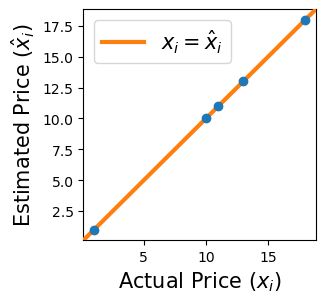

In [16]:
# plot x, xhat from above code
# plot comparison of actual and estimated prices
plt.figure(figsize=(3,3))
plt.plot(x,xhat,'o',zorder=4,label="_data")
xx,yy = plt.xlim(),plt.ylim()
plt.plot(xx,xx,zorder=3,label="$x_i=\\hat{x}_i$",linewidth=3)
plt.legend(fontsize=15)
plt.xlim(xx)
plt.ylim(yy)
plt.xlabel("Actual Price ($x_i$)",fontsize=15)
plt.ylabel("Estimated Price ($\\hat{x}_i$)",fontsize=15);

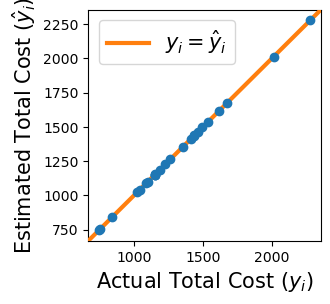

In [17]:
# plot comparison of actual and estimated total costs
plt.figure(figsize=(3,3))
plt.plot(y,yhat,'o',zorder=4,label="_data")
xx,yy = plt.xlim(),plt.ylim()
plt.plot(xx,xx,zorder=3,label="$y_i=\\hat{y}_i$",linewidth=3)
plt.legend(fontsize=15)
plt.xlim(xx)
plt.ylim(yy)
plt.xlabel("Actual Total Cost ($y_i$)",fontsize=15)
plt.ylabel("Estimated Total Cost ($\\hat{y}_i$)",fontsize=15);

#### Now, introducint OLS, ordinary least square

In [18]:
# generate example prices \vec{x}
x = np.random.randint(0,20,size=5)
p = len(x)
# should be n > p
n = p+20
# generate example purchasing behavior for n individuals
M = np.random.randint(0,50,size=(n,p))
# calculate true total costs \vec{y}
y = M@x
# attempt to backsolve, but expect error because M is not square
#x = np.linalg.solve(M,y)


from sklearn.linear_model import LinearRegression

# Create a Linear Regression object
ols = LinearRegression(fit_intercept=False)
# fit the linear regression to our data
ols.fit(M,y)

# get estimated costs
xhat = np.round(ols.coef_,decimals=10)
# get estimated total costs
yhat = ols.predict(M)

#### Solving Linear Systems Probabilistically with OLS

As before, consider an **overdetermined** system with more equations than unknown variables

$
M = \begin{bmatrix}
    m_{11} & m_{12} & \cdots & m_{1p} \\
    m_{21} & m_{22} & \cdots & m_{2p} \\
    \vdots & \vdots & \ddots & \vdots \\
    m_{n1} & m_{n2} & \cdots & m_{np} \\
\end{bmatrix},
\hspace{1cm}
\vec{x} = \begin{bmatrix}
    x_1 \\ x_2 \\ \vdots \\ x_p
\end{bmatrix},
\hspace{1cm}
\color{blue}{
\vec{y} = \begin{bmatrix}
    y_1 \\ y_2 \\ \vdots \\ y_n
\end{bmatrix}},
$

such that $\hspace{1cm}M\cdot\vec{x}\approx\color{blue}{\vec{y}}\hspace{1cm}$ and $n>p$.

As before, we can think about $\vec{x}$ as prices for $p$ different grocery items, $M$ as the purchases of $n$ individuals, and $\color{blue}{\vec{y}}$ as the total costs for each individual.

Unlike before, $M$ is a **data set** of purchasing behaviors across individuals <font color="red">which includes real-world randomness and variation.</font>

We will find a probabilistic solution for $\vec{x}$.

Unlike before, we expect that $x_1,\,x_2,\,\cdots,\,x_p$ will represent some average prices.

Specifically, we want to estimate prices $\hat{x}$ such that our estimated total costs $M\cdot\hat{x}=\color{red}{\hat{y}}$ are as close to the true $\color{blue}{\vec{y}}$ as possible.

That is, we want to minimize the **norm of the difference vector**: $\hspace{1cm}||\color{blue}{\vec{y}}-\color{red}{\hat{y}}||=\sqrt{\sum_{i=1}^n \left(\color{blue}{y_i}-\color{red}{\hat{y}_i}\right)^2}$


#### The overarching strategy is called **ordinary least squares (OLS) regression**.

Instead of $\hspace{1cm}M\vec{x}\approx\color{blue}{\vec{y}}$

we multiply both sides of the equation by $M^T$ and solve the following for $\color{red}{\hat{x}}$

$
\left(M^TM\right)\vec{x} \approx M^T\color{blue}{\vec{y}}
\hspace{1cm}\Rightarrow\hspace{1cm}
\color{red}{\hat{x}} \approx \left(M^TM\right)^{-1}\cdot M^T\vec{y}
$

The solution we get will be an **estimate** $\color{red}{\hat{x}}$ for the true vector $\vec{x}$. The components $\color{red}{\hat{x}_i}$ of $\color{red}{\hat{x}}$ are called **coefficients**.

#### Performance Metrics
Another common option is to calculate the **coefficient of determination** 
$$\hspace{1cm} R^2 = \frac{\sum_{i=1}^n \left(\hat{y}_i-\bar{y}\right)^2}{\sum_{i=1}^n \left(y_i-\bar{y}\right)^2}\hspace{1cm}$$

where $\bar{y}$ is the average value of $\vec{y}$.

You can treate $R^2$ as the variance in $\vec{y}$ that is "explained" by $\hat{y}$.

$R^2$ ranges from 0 to 1 where $R^2=1$ indicates that all of the variation in $\vec{y}$ is recovered in $\hat{y}$.

We will discuss this measure more later, but $R^2=1$ means that there exists $m,\,b$ such that $\hspace{1cm}\vec{y}=m\cdot\hat{y}+b$

What do these calculation say about the ability of our approach to explain the purchases of each of the $n$ individuals?

Each term in
$
\hspace{1cm}
\sum_{i=1}^n \left(y_i-\hat{y}_i\right)^2
\hspace{1cm}
$
corresponds to one of the $n$ individuals (i.e., each row of $M$).

The difference between the estimated total cost $\,\hat{y}_i\,$ and the actual total cost $\,y_i\,$ is called the **$i$th residual**.

If we plot the total cost data $\left(1,y_1\right),\,\left(2,y_2\right),\,\dots,\,\left(n,y_n\right)\,$ compared to the estimated total costs $\left(1,\hat{y}_1\right),\,\left(2,\hat{y}_2\right),\,\dots,\,\left(n,\hat{y}_n\right)\,$ then the $i$th residual is the vertical distance between points.

In [19]:
from scipy.stats import pearsonr
# generate true data
x = np.array([1,4,20,5,3,6,3,7,2])
# number of grocery item prices (one price per item)
p = len(x)
# number of individuals with purchasing data (here just want n > p)
n = 50*p
x = np.tile(x,(n,1))
M = np.random.randint(0,15,(n,p))
# precalculate stuff for widget
MT = M.T
G = MT@M
y = np.sum(M*x,axis=1)
# # generate noise to be added to the prices (x)
# # Here, the noise represents variation in prices for the same grocery item across different stores.
# # Prices are normally distributed about some average price.
noise = np.random.normal(size=x.shape)

def plotResiduals(priceVariation=0):
    noisyx = x+priceVariation*noise
    ynoisy = np.sum(M*noisyx,axis=1)
    y2 = MT@ynoisy
    xhat = np.linalg.solve(G,y2)
    yhat = M@xhat

    # plot outcomes
#     plt.figure(figsize=(12,6));
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2,figsize=(14,8));
    n2 = np.min([10,n])
    for i in range(n2):
        ax1.plot([i+1,i+1],[y[i],yhat[i]],'k-',label="_residual")

    a = np.arange(n2)+1
    ax1.plot(a,y[:n2],'o',label="Actual Cost ($y_i$)",markersize=8)
    ax1.plot(a,yhat[:n2],'^',label="Estimated Cost ($\\hat{y}_i$)",markersize=8)
    ax1.set_ylim((-500,1000))
    xx,yy = ax1.get_xlim(),ax1.get_ylim()
    ax1.plot([0,0],[1,2],"k-",label="Residual",linewidth=3)
    ax1.set_xlim(xx)
    ax1.set_ylim(yy)
    ax1.legend(fontsize=15,ncol=2,loc="lower left")
    ax1.set_xticks(list(map(int,a)))
    ax1.set_xlabel("Individual ($i$)",fontsize=15)
    ax1.set_yticklabels(ax1.get_yticks(),fontsize=15)
    ax1.set_ylabel("Total Cost ($)",fontsize=15)


    ax2.plot(y,yhat,'o',zorder=4,label="_data")
    r,p = pearsonr(y,yhat)
    xx,yy = ax2.get_xlim(),ax2.get_ylim()
    ax2.plot(xx,xx,'-',zorder=3,label="$\\hat{y}_i = y_i$",linewidth=3)
    ax2.set_title("$R^2=%0.2f$" % (r**2),fontsize=15)
    ax2.set_xlim(xx)
    ax2.set_ylim(yy)
    ax2.set_xlabel("Actual Total Cost ($y_i$)",fontsize=15)
    ax2.set_ylabel("Estimated Total Cost ($\\hat{y}_i$)",fontsize=15)
    ax2.legend(fontsize=12)

    C = ['r','b','g']
    for i in range(3):
        counts,bins = np.histogram(noisyx[:,i],bins=20)
        ax3.plot(bins[:-1],counts,'-o',label="grocery %d" % (i+1),color=C[i])
    yy = ax3.get_ylim()[1]
    for i in range(3):
        ax3.plot([xhat[i],xhat[i]],[0,yy],'--',color=C[i],label="_xhat",linewidth=3)
    ax3.plot([0,0],[-1,-2],'k--',label="Estmated Cost ($\\hat{x}_i$)")
    ax3.set_ylim((0,yy))
    ax3.legend(fontsize=12)
    ax3.set_xlabel("Observed Grocery Item Price ($)",fontsize=15)
    ax3.set_ylabel("Number of Observations",fontsize=15)
    ax3.set_yticklabels(ax2.get_yticks(),fontsize=15)

    ax4.plot(x[0,:],xhat,'o',zorder=4,label="_data")
    xx,yy = ax4.get_xlim(),ax4.get_ylim()
    ax4.plot(xx,xx,'-',zorder=3,label="$\\hat{x}_i = x_i$",linewidth=3)
    ax4.set_xlim(xx)
    ax4.set_ylim(yy)
    ax4.set_xlabel("Actual Grocery Price ($x_i$)",fontsize=15)
    ax4.set_ylabel("Estimated Grocery Price ($\\hat{x}_i$)",fontsize=15)
    ax4.legend(fontsize=12)


    plt.tight_layout();
    return None

#### Fitting Linear Equations to Data

Our approach to solving overdetermined linear systems can be used to describe data.

Imagine the following data

$\begin{array}{c|c} \hline x & y \\  \hline 1 & 7\\2 & 11\\3 & 15\\4 & 19\\5 & 23\end{array}$

If we assume that $x$ and $y$ are **linearly related**, then there exists coefficients $\beta_0$ and $\beta_1$ such that
$
\quad
y = \beta_0 + \beta_1\cdot x
$

Can we determine $\beta_0,\, \beta_1$?

In [20]:
x = np.arange(5)+1
y = 3+4*x

# np.vstack is faster than pd.DataFrame({"a": a, "b": b}).to_numpy()
d = sp.Matrix(np.vstack((x,y)).T)
print(sp.latex(d))

\left[\begin{matrix}1 & 7\\2 & 11\\3 & 15\\4 & 19\\5 & 23\end{matrix}\right]


Starting with
$
\quad
y = \beta_0 + \beta_1\cdot x
\quad
$
instead consider
$
\quad
y = \beta_0\cdot \color{red}{1} + \beta_1\cdot x
$

This is a small change and, of course, the two equations are equivalent.

But, written this way we see that our problem can also be written as

$
M\vec{\beta} =
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_n & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
\beta_1 \\
\beta_0 \\
\end{bmatrix}
= \vec{y}
$

This is an overdetermined system of linear equations. We know how to solve this!

In [84]:
# our data
x = np.arange(5)+1
y = np.array([7,11,15,19,23])

# create the matrix containing the data
M = np.vstack((x,np.ones(len(x)))).T
M

array([[1., 1.],
       [2., 1.],
       [3., 1.],
       [4., 1.],
       [5., 1.]])

In [85]:
G = M.T@M
yy = M.T@y
b = np.linalg.solve(G,yy)
b

array([4., 3.])

In [86]:
# Let's test our solution
yhat = M@b
print(yhat)
print(y)

[ 7. 11. 15. 19. 23.]
,,[ 7 11 15 19 23]


#### The **line of best fit** is the "best" line in that it minimizes the sum of the residuals between the data points and the line.

In this first case, $y$ and $x$ were **perfectly** linearly related. The linear equation yielded an exact solution. The scatter plot relating $x$ and $y$ hinted at this visually.

But what if $x$ and $y$ are **imperfectly** linearly related?

Consider the following scatter plot for a new data set of $x$ and $y$.

There is no straight line that intersects all of the points, but, still, perhaps there is a straight line that captures the general relationship between $x$ and $y$.

This line is called the **line of best fit**.

Given a data set containing $x$ and $y$, a similar approach can find **best fit** approximations assuming other functional forms that minimize the residuals between the data and the approximation.

Instead of fitting a straight line to $x$ and $y$, we can assume that the variables are related by any polynomial:

$
\quad
y = \displaystyle\sum_{i=1}^n \beta_i\cdot x^i
$

For example, let's consider some new data and assume the following relationship
$
\quad
y = \beta_2\cdot x^2 + \beta_1\cdot x + \beta_0
\quad
$

In [40]:
x3 = np.arange(15)
y3 = 2*x3**2 + 3*x3 + 1

#### Gram matrix approach to find the least squares solution to a system.
$(M^T \cdot M)^{-1} \cdot (M^T \cdot M) \cdot \vec x = (M^T \cdot M)^{-1} \cdot M^T \cdot \vec y$

$(M^T \cdot M)^{-1} \cdot (M^T \cdot M) =  I$

$\Rightarrow$ $I \cdot \vec x = \vec x = (M^T \cdot M)^{-1} \cdot M^T \cdot \vec y$

Take a 2 by 2 matrix $G = (M^T \cdot M) =  \begin{bmatrix} a & b \\ c & d \end{bmatrix}$ as an example to solve its inverse, $G ^ {-1}$

$$G^{-1} = \frac{1}{det(G)} \cdot \begin{bmatrix} d & -b \\ -c & a \end{bmatrix} =  \frac{1}{ad -bc} \cdot \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

#### Gram matrix approach in details
We change our previous approach by adding a column to $M$ for each order of the polynomial and we add a corresponding coefficient to $\vec{\beta}$.

$M\vec{\beta} =
\begin{bmatrix}
x_1^2 & x_1 & 1 \\
x_2^2 & x_2 & 1 \\
\vdots & \vdots & \vdots \\
x_n^2 & x_n & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
\beta_2 \\
\beta_1 \\
\beta_0 \\
\end{bmatrix}
= \vec{y}$

and, just as before, we use $M^T$ to solve the overdetermined system using $\left(M^TM\right)^{-1}$:

$\begin{bmatrix} \beta_2 \\ \beta_1 \\ \beta_0 \\ \end{bmatrix}=
\left(
\begin{bmatrix}
x_1^2 & x_2^2 & \cdots & x_n^2 \\
x_1 & x_2 & \cdots & x_n \\
1 & 1 & \cdots & 1 \\
\end{bmatrix}
\begin{bmatrix}
x_1^2 & x_1 & 1 \\
x_2^2 & x_2 & 1 \\
\vdots & \vdots & \vdots \\
x_n^2 & x_n & 1 \\
\end{bmatrix}
\right)^{-1}
\begin{bmatrix}
x_1^2 & x_2^2 & \cdots & x_n^2 \\
x_1 & x_2 & \cdots & x_n \\
1 & 1 & \cdots & 1 \\
\end{bmatrix}
\vec{y}
$

In this case, we get $\vec{\beta} = \begin{bmatrix} 2 \\ 3 \\ 1 \\ \end{bmatrix}$.

### Jan-15-2026

#### Module 4: Expected Values and the Normal Distribution
This module introduces the probabilistic concept of expected value and their relationship to the Normal Distribution from probability theory.
Calculate and interpret basic summary statistics for datasets, including mean, median, and mode.
* M4 Lecture 1: Expected Values
* M4 Lecture 2: Samples of Dice Rolls
* M4 Lecture 3: Populations vs. Samples of Heights Data
* M4 Lecture 4: Populations vs. Samples of Wage Data
* M4 Lecture 5: Central Limit Theorem and Normal Distribution


#### Example to introduce the Expected Value 
* $E[X] = \displaystyle\sum_{x\in X}x\cdot p(x)$
* We can also think of $E[X]$ as the vector product $\hspace{1cm}E[X] = \vec{x}\cdot\vec{p}\hspace{1cm}$
* where $\vec{x}$ is the vector of possible outcomes
* and $\vec{p}$ is the vector of probabilities associated with each outcome.

for the case of rolling a 6-facet fair dice
* So the possible outcomes are $$D=\{\$1,\,\$2,\,\$3,\,\$4,\,\$5,\,\$6\}$$
* and the expected value is $$E[D] = \displaystyle\sum_{x\in D} x\cdot p(x) = \$1\frac{1}{6}+\$2\frac{1}{6}+\$3\frac{1}{6}+\$4\frac{1}{6}+\$5\frac{1}{6}+\$6\frac{1}{6} = \frac{\$1 +\$2 + \$3 + \$4 + \$5 + \$6}{6} = \color{blue}{\$3.5}$$

for the case of flipping a fair coin
* the possible outcomes are $$C=\{\$0,\,\$6\}$$
* and the expected value is $$E[C] = \displaystyle\sum_{x\in C} x\cdot p(x) = \$0\frac{1}{2}+\$6\frac{1}{2}=\frac{\$0 + \$6}{2} = \color{red}{\$3}$$

#### Note, Code Digging.
Digging codes like this takes a lot time. And it only shows the process of introducing CLT. 

In [40]:
# use _ as visual separator for numeric literals
# roll the dice fo 100K times, and check its distribution
n = 100_000
diceRolls = np.random.choice([1,2,3,4,5,6, 6], # we can add another 6 to make it unfair
                             size=n,
                             replace=True)

df_diceRolls = pd.Series (diceRolls)

# This shows an even distribution, as each with the same probability
print(df_diceRolls.value_counts())
# and their average is the expected value E[D]
print(df_diceRolls.mean())


# Now use Central Limit Theorem
sampleSize = 5
sampleCount = 30
Sample_diceRolls = np.random.choice([1,2,3,4,5,6, 6], # we can add another 6 to make it unfair
                                    size=(sampleCount,sampleSize),
                                    replace=True)

df_Sample_diceRolls = pd.DataFrame(Sample_diceRolls)
# take the average of 'each sampleSize = 5', and their mean of 'sampleCount = 30'
# This will show as a Gaussian Distribution, with center at  the expected value E[D]
df_Sample_diceRolls.mean(axis = 1).mean()


# Either fair dice or not, the CLT will get the expected value E[D]

6    28655
,,2    14449
,,4    14327
,,5    14308
,,1    14174
,,3    14087
,,Name: count, dtype: int64
,,3.86111


np.float64(3.7)

#### Populations vs. Samples
* Example 1: Estimating American adult heights
* Example 2: Estimating Annual Wages for US Workers
* Both used to introduce Central Limit Theorem
  * If we have several samples $X_1,\,X_2,\dots,\,X_c$,
  * then the distribution of these Samples' $E[ X_1],\,E[ X_2],\dots,\,E[ X_c]$ converges to
  * the Normal Distribution centered around the Population's $E[D]$.

In [23]:
#Again, used to prove Sample data with CLT can estimate Population data

# simulate "ground truth" data based on statistics
# use the true  'Mean height' as center, to generate 'popSize' of population data
popSize = 1000
boys_mean_height = 176
boyHeights = np.random.normal(loc = boys_mean_height,
                              scale = 8,
                              size = popSize,) #prof. Frank loves 'trailing comma'

girls_mean_height = 164
girlHeights = np.random.normal(loc = girls_mean_height,
                               scale = 6,
                               size = popSize,)


allHeights = np.hstack((boyHeights,girlHeights))

allHeights.shape

(2000,)

In [4]:
#Create my own population
mu = 500
sigma = 100
size = 2000
population = np.random.normal(loc = mu,
                 scale = sigma,
                 size = size)
df_population = pd.DataFrame({'population': population})
df_population.describe()

,population
count,2000.000000
mean,500.361027
std,101.273882
min,139.748639
25%,435.153034
50%,500.438275
75%,568.711595
max,857.984002


In [28]:
# Label the population into random groups (sample) of 50
sample_label = np.random.randint(low=1, high=51, size=2000)
df_population['sample_label'] =  sample_label
df_sample = df_population.groupby('sample_label').agg(['mean', 'count']).reset_index()
df_sample.columns = ['sample_label', 'sample_mean', 'sample_size']
df_sample.head()

,sample_label,sample_mean,sample_size
0,1,476.722431,35
1,2,484.907702,27
2,3,491.330172,47
3,4,491.184759,40
4,5,512.547801,35


In [27]:
#check SEM = sigma / sqrt(n)
df_population['population'].std() / (len(df_sample)**0.5), df_sample['sample_mean'].std()

(np.float64(14.322289805084406), np.float64(14.898976607132964))

#### The Central Limit Theorem and the Normal (“Bell Curve”) Distribution
The **Central Limit Theorem** explains this observation:
> If you take many independent samples  (e.g., survey a portion of a population) from **any** population distribution with __finite variance__, the distribution of the sample means converges to a Normal distribution as the sample size increases.

Lecture Examples used:
  * Fair Dice Roll Average, vs sampleSize by sampleCount CLT
  * Weighted Dice Roll Average, vs sampleSize by sampleCount CLT
  * Boy/Girl Heights generated from 'Ground Truth Mean Height' and 'Standard deviation', vs sampleSize by sampleCount CLT
  * Anual Wages,  vs sampleSize by sampleCount CLT
* Dice rolls (fair and weighted), population heights, and population wage data produce very different population distributions.
* But, despite that diversity, distributions of sample averages produce a nearly identical bell shaped distribution.
* The bells may be shifted around the true population's expected value and exhibit different widths, but still a bell-shaped curve. 

#### Sample's Expected Values $E[X]$, form a Normal Distribution with Population's Expected Value $E[D]$ as Center.
* Note, this Population's Expected Value $E[D]$ can only be estimated with a probability and Confidence Interval.
* Let $X=\{d_1,d_2,\dots,d_n\}$ represent a random sample of outcomes from polulation $D$
* each selected with probability $p(D=d)$
* and $E[X] = \frac{1}{n}\displaystyle\sum_{d\in X}d\hspace{1cm}$ denote the sample's expected value.
* If we have several samples $X_1,\,X_2,\dots,\,X_c$,
* then the distribution of $E[ X_1],\,E[ X_2],\dots,\,E[ X_c]$ converges to the Normal Distribution centered around $E[D]$.

### Jan-17-2026

#### How to pack a Question into a Statistics Box
* Step 1, which Distribution does populaiton follow?
* Step 2, if not certain, use CLT to pack their `Sample Mean` into a Gaussian.
* Step 3, now we have a Gaussian, but for this Gaussian
  * Still, the population mean $\mu$ is a fixed but unknown parameter.
  * And, we don't know its true standard deviation $\sigma$
  * we only know, for these limited numbers of data of `sample mean`, they follow this Gaussian
  * and, we can esitimate with 95% CI, $\mu = df.mean() \pm 1.96*df.sem()$
  * and, this `df.sem()` = `df.std()` / `df.count()`, with all missing values removed.
* Step 4, be aware that the common names $\mu$ goes by, `pick a random sample, and its expected value`.
* Step 5, on the other side of the `Confidence Interval` bridge, if we set a range $[lower, upper]$ for $\mu$, we should be able to find the probability through $z$
  *  `P = scipy.stat.norm.cdf(upper) - scipy.stat.norm.cdf(lower)`

We'll take Homework Question 3, as an example:
* If I take a random sample of Census Tracts, what is the probability that the sample's expected value falls between $\$100,000$ and $\$110,000$?
* Here, the __Expected Value__ of this __a random sample of Census Tracts__ is __population_mean__
* pact this into the box: $E[random sample] = \mu = E[s] \pm z * \frac {\sigma}{\sqrt{n}}$
* in this statistics box
  * $E[s]$ is `df_data['Averge_Income'].mean()`
  * $\frac {\sigma}{\sqrt{n}}$ is `df_data['Averge_Income'].sem(ddof=1)`
  * most importantly, with this question $\mu = (100000, 110000)$
  * this question is looking for the probability with ($z_{upper} - z_{lower}$)

In [8]:
#demo dataset
Census_Tracts = ['Census Tract 1005; Allegheny County; Pennsylvania', 
                 'Census Tract 1011; Allegheny County; Pennsylvania', 
                 'Census Tract 1014; Allegheny County; Pennsylvania', 
                 'Census Tract 1018; Allegheny County; Pennsylvania', 
                 'Census Tract 1019; Allegheny County; Pennsylvania', 
                 'Census Tract 103.02; Allegheny County; Pennsylvania']
Average_Income = [71831.0, 
                  95835.0, 
                  94318.0,
                  98386.0,
                  73783.0,
                  68838.0]
Sample_size = [894,
               1138,
               1515,
               1308,
               1131,
               322]

df_data = pd.DataFrame({'Census_Tracts': Census_Tracts, 
                        'Average_Income': Average_Income, 
                        'Sample_size': Sample_size})

df_data

,Census_Tracts,Average_Income,Sample_size
0,Census Tract 1005; Allegheny County; Pennsylvania,71831.0,894
1,Census Tract 1011; Allegheny County; Pennsylvania,95835.0,1138
2,Census Tract 1014; Allegheny County; Pennsylvania,94318.0,1515
3,Census Tract 1018; Allegheny County; Pennsylvania,98386.0,1308
4,Census Tract 1019; Allegheny County; Pennsylvania,73783.0,1131
5,Census Tract 103.02; Allegheny County; Pennsyl...,68838.0,322


#### Know the difference of 
> Estimating population mean $\mu$
> 
> and the "Empirical Rule" (or 68-95-99.7 rule, or $3\sigma$ rule).
>
> both are expressed with something like this: $\mu = E[s] \pm 1.96 * SEM$

#### Population mean, $\mu$, Sample mean, $\bar X$, and the Confidence Interval
* The population mean $\mu$ is a fixed but unknown parameter. 
* $\mu$ cannot be known exactly from sample data, because the full population is not observed.
* Also, we can not assume that the population follows Gaussian
* Instead, we can CLT to pack some `sample mean` dataset into a Gaussian
* and, estimate $\mu$ using our new found Gaussian,
* Be aware, we need this CLT Gaussian to use this Confidence Interval Bridge:  $\mu =  E[s] \pm z*SEM$
> if you repeated the sampling process many times and calculated an interval for each sample, approximately 95% of those calculated intervals would capture the true population mean.

#### But if you already have a Gaussian, on the other side of the Confidence Interval Bridge, lie the "Empirical Rule" (or 68-95-99.7 rule, or $3\sigma$ rule)
* $P\left(\mu - 3\frac{\sigma}{\sqrt{n}} \le \bar{X} \le \mu + 3\frac{\sigma}{\sqrt{n}}\right) \approx 99.7 \%$
> with a given Gaussian Distribution with mean =$\mu$, 68% of samples can be found within 1-sigma diviation.
> about 95% in 2-sigma deviation
> and about 99.7% of sample means lie within ±3 standard errors of the population mean.

#### In practice, we use $2\sigma$
* 95% CI → ±2 SE ($z$ actually 1.96)

#### Variance
Formally, we measure how "wide" a probability distribution using it's **variance**.

If $D$ is some probability distribution, it's variance is

$Var(D) = E\left[\left(D-E[D]\right)^2\right] = \displaystyle\sum_{d\in D} \left(d-E[D]\right)^2\cdot p(D=d)$
* Compared to $\sigma^2 = E[(X-\mu)^2] = \frac{\sum (x_{i}-\mu )^{2}}{N}$
* $\frac{1}{N}$ or $p(D=d)$, either evenly distributed or with weighted probability.

#### Gaussian/Normal Distribution centered at $E[D]$ for some distribution $D$ as 
$\mathcal{N}(x,D)$ means: the normal (Gaussian) density at $x$ with parameters from $D$.
$$\mathcal{N}(x,D) = \frac{1}{\sigma_D\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-E[D]}{\sigma_D}\right)^2}$$

CLT does not say the expectation is continuous; it says the distribution of the sample mean becomes approximately normal, even when the underlying data are discrete.

For a continuous random variable (X), we have the probability density function (PDF).
$$f(x) = \frac{1}{\sigma \cdot \sqrt{2\pi}} \cdot \exp \left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$


#### But how well can I estimate the true $E[D]$ using the expected value of the synthetic data $E[D_s]$?
>Unless the entire population is observed or artificially defined, the population mean is unknown and is estimated by the sample mean, with uncertainty quantified using a confidence interval.

For example, with 95% probability, $E[D]$ will be between $\hspace{1cm}E[s] \pm 1.96\cdot (\sigma_s/\sqrt{n})\hspace{1cm}$
* we take the following dataset as example
* we know the population mu =500
* For each row: 95% probability, mu = `sample_mean` +_ (1.96*`SEM`)
* And, notice another Standard Deviation of the `Sample_mean`, `df_population['sample_mean'].std(ddof=1)`

In [36]:
#Create my own population
mu = 500
sigma = 100
size = 2000
population = np.random.normal(loc = mu,
                 scale = sigma,
                 size = size).reshape(40, -1)
df_population = pd.DataFrame(population)

#Got a 40 by 50 dataframe, 
df_population['SEM'] = df_population.sem(axis = 1)
df_population['std'] = df_population.std(axis = 1)

df_population['sample_mean'] = df_population.mean(axis = 1)
df_population.iloc[:3, -5:]

,48,49,SEM,std,sample_mean
0,617.274263,526.017029,15.328653,128.094261,497.911596
1,584.389867,535.564589,13.585092,117.407768,488.411851
2,592.197045,594.113827,13.803586,118.834581,490.834690


#### the Confidence Interval
1, Let's represent our __sample__ $s$ of synthetic dice rolls 
* using $s=\{d_1,\,d_2,\,\dots,\,d_n\}$
* and the sum of values in our dice roll results ${T_s=\displaystyle\sum_{i=1}^n d_i}\hspace{1cm}$
* then, the expected value of the __sample__ is $E[s] = {T_s}/n$

2, ${T_s}$ is itself a random variable; calculating ${T}$ for two different samples $s_1$ and $s_2$ might yield two different values (i.e., it may be that $T_{s_1}\neq T_{s_2}$).

The $\color{blue}{T}$ values across multiple samples will form a distribution which has variance $\hspace{1cm}Var(\color{blue}{T})=n\sigma_s^2\hspace{1cm}$ because each observation $d_i$ is part of a sample with variance $\sigma_s^2$.

Similarly, across $m$ different samples, $E[s]$ will also form a distribution with variance

$
\begin{aligned}
\operatorname{Var}(E[s])
&= \operatorname{Var}\left(\frac{T}{n}\right) \\
&= E\left[\left(\frac{T}{n} - E\left[\frac{T}{n}\right]\right)^2\right] \\
&= E\left[\left(\frac{T}{n} - \frac{1}{m}\sum_{i=1}^{m}\frac{T}{n}\right)^2\right] \\
&= E\left[\left(\frac{T}{n} - \frac{1}{n}\left(\frac{1}{m}\sum_{i=1}^{m} T\right)\right)^2\right] \\
&= \frac{1}{n^2} E\left[\left(T - E[T]\right)^2\right] \\
&= \frac{1}{n^2} \operatorname{Var}(T) \\
&= \frac{1}{n^2} \cdot n\sigma_s^2 \\
&= \frac{\sigma_s^2}{n}
\end{aligned}
$


#### Understanding $E[s]$
* the expected value of sample $s$, is the mean (average)
* the standard error on (of) the mean (SEM): $\sigma_{E[s]} = \sqrt{\sigma_s^2/n} = \sigma_s/\sqrt{n}$
* this is saying $E[s] \in (E[D], \sigma_s/\sqrt{n})$



$Var(E[s]) = \sigma_s^2/n\hspace{1cm}$

and, therefore, the standard deviation of our distribution of 
$E[s]$ estimates, called the **standard error**, is $\hspace{1cm}\sigma_{E[s]} = \sqrt{\sigma_s^2/n} = \sigma_s/\sqrt{n}$

In other words, the distribution of expected values across multiple samples is again a normal distribution with expected value $\hspace{1cm}E\left[E[s]\right]=E[D]\hspace{1cm}$ and standard deviation $\hspace{1cm}\sigma_{E[s]}=\sigma_s/\sqrt{n}$

We will derive this later, but the standard error of our sample allows us to bound our estimate of the true population averge. 




| Term                                 | What it measures                      | Applies to                          | Formula                                                                          | Units             |
| ------------------------------------ | ------------------------------------- | ----------------------------------- | -------------------------------------------------------------------------------- | ----------------- |
| **Deviation**                        | Distance from the mean                | Single observation                  | $x_i - \mu$ (population) <br> $x_i - \bar x$ (sample)                              | Same as data      |
| **Variance**                         | Average squared deviation             | Distribution  | $\sigma^2 = \mathbb E[(X-\mu)^2] = \frac{\sum (x_{i}-\mu )^{2}}{N}$ (population)  <br> $s^2 = \frac{1}{n-1}\sum (x_i-\bar x)^2$ (sample) | Squared units     |
| **Standard deviation**               | Typical spread of values              | Individual observations             | $\sigma = \sqrt{\sigma^2}$  <br> $s = \sqrt{s^2}$                                | Same as data      |
| **Standard error (SE)**              | Spread of an estimator                | Any estimator                       | $\text{SE}(\hat\theta)=\sqrt{\operatorname{Var}(\hat\theta)}$                   | Same as estimator |
| **Standard error of the mean (SEM)** | Spread of sample means                | Sample mean only                    | $\displaystyle \text{SEM}=\frac{\sigma}{\sqrt n}\approx\frac{s}{\sqrt n}$        | Same as data      |
| **Error**                            | Difference between estimate and truth | Single estimate                     | $\hat\theta - \theta$                                                            | Same as quantity  |


### Jan-20-2026

#### Module 5: Calculus I - Derivatives
This module introduces the derivative concept from calculus.
Calculate derivatives, integrals, and partial derivatives/integrals, preparing them to handle continuous random variables in subsequent modules.
* M5 Lecture 1: Calculus–Core Concepts
* M5 Lecture 2: Approximating Derivatives
* M5 Lecture 3: Calculating Exact Instantaneous Derivatives
* M5 Lecture 4: Derivatives for Simple Polynomials
* M5 Lecture 5: Derivatives–Additivity, Mult. by Constants, and the Power Rule
* M5 Lecture 6: Derivative Chain Rule
* M5 Lecture 7: Derivative Products and Quotients
* M5 Lecture 8: Symbolically Solving Higher Order Derivatives & Partial Derivatives
* M5 Lecture 9: Example–Population Growth (Logistic Curve)
* M5 Lecture 10: Derivatives and Stationary Points


#### Use Calculus to find the probability.
* the Gaussian distribution is a probability density function (PDF) (more precisely, it has a probability density function).
  * $f(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$
* The probabilities in this plot are actually the area under the curve
  * $P(a \le X \le b) = \int_a^b f(x)dx$
  * For example, 34.1% of the area under the curve falls between 0 and  1σ .
  * 13.6% of the total area under the curve falls between  1σ  and  2σ .


#### Core concepts of calculus
Calculus covers two core concepts:
>First, <font color="red">***derivatives***</font> are the mathematical concept for <font color="red"><u>rate of change</u></font> 
(e.g., a car's speed, cost per item, birth/death rates)
>
> Second, <font color="blue">***integrals***</font> are the mathematical concept for <font color="blue"><u>accumulation</u></font>
(e.g., distance traveled, total cost, population dynamics, and <font color="green">probabilities!</font>)

#### Derivatives
For a Continuous and Smooth Function $f(t)$, derivatives are interested in the ***limiting value*** of 

$\displaystyle \frac{df(t)}{dt}\approx\frac{f(t+h)-f(t)}{h}$ as $h\rightarrow0$.

So, here comes the difinition:
$\displaystyle\frac{df(t)}{dt}=\displaystyle{\lim_{h\rightarrow0}\frac{f(t+h)-f(t)}{h}}$

Once a function $f(t)$ is defined, we can use this equation to calculate the derivative of $f$ at any time $t$ so long as the neighborhood of $t$ is smooth and continuous.

| Concept                  | Symbol     | Example                              |
| ------------------------ | ---------- | ------------------------------------ |
| Ordinary derivative      | $d$        | $\frac{d}{dx} f(x)$                  |
| Partial derivative       | $\partial$ | $\frac{\partial}{\partial x} f(x,y)$ |



#### Finding Derivatives
* the long-form limit definition
$$\frac{df(t)}{dt} = \lim_{h \to 0} \frac{f(t+h) - f(t)}{h}$$

* let ${f(t)=t^2}$

* $$\begin{aligned}
\frac{df(t)}{dt}
&= \lim_{h \to 0} \frac{(t+h)^2 - t^2}{h} \\[6pt]
&= \lim_{h \to 0} \frac{(t+h)(t+h) - t^2}{h} \\[6pt]
&= \lim_{h \to 0} \frac{t^2 + 2th + h^2 - t^2}{h} \\[6pt]
&= \lim_{h \to 0} \frac{h(2t + h)}{h} \\[6pt]
&= \lim_{h \to 0} (2t + h) \\[6pt]
&= 2t
\end{aligned}$$

note: `\\[6pt]` Latex, line break plus extra vertical space of 6 points

Mathematical Induction vs Heuristic
| Comparison | Mathematical Induction | Heuristic |
|---|---|---|
| Goal | To prove a statement is 100% true. | To discover a pattern or guess a solution. |
| Reliability | Guaranteed and rigorous (when done correctly). | Plausible but potentially inaccurate; needs verification. |
| Example | Proving $\sum_{i=1}^{n} i = \frac{n(n+1)}{2}$ for all $n$. | Using the “Power Rule” ($nx^{n-1}$) instead of the limit definition. |
| Logic Type | Deductive. | Often “inductive” in the philosophical sense (pattern-based). |

#### Heuristic Rules to find Derivative
> In calculus, "heuristic" rules refer to the reliable "shortcuts" that allow you to find a derivative without having to use the long-form limit definition. Once you know the derivative of enough common functions, then you can skip the need to solve the long form limit each time and instead apply the heuristic.

The following are the fundamental heuristic rules of derivatives: 
1. The Power Rule, for any real number $n$,
$$\hspace{.5cm} \frac{d}{dt} t^n=n\cdot t^{n-1}\hspace{.5cm}$$


2. The Constant (the derivative of 5 is 0) & Constant Multiple Rules (the derivative of $5x^3 = 5 *3x^2$)
$$\begin{align}
\frac{d\left(a\cdot f(t)\right)}{dt} 
&= \lim_{h\rightarrow0}\frac{a\cdot f(t+h)-a\cdot f(t)}{h}\\
&= \lim_{h\rightarrow0}\frac{a\left( f(t+h)-f(t)\right)}{h}\\
&= a\left(\lim_{h\rightarrow0}\frac{f(t+h)-f(t)}{h}\right)\\
&=a\cdot\frac{df(t)}{dt}
\end{align}$$

3. The Sum and Difference Rules (derivative additivity), the derivative of $x^{2}+4x$ is $2x+4$, with $\hspace{.5cm}H(t)= f(t)+g(t)$
$$\begin{align}
\frac{dH(t)}{dt} 
&= \lim_{h\rightarrow0}\frac{H(t+h)-H(t)}{h}\\
&= \lim_{h\rightarrow0}\frac{f(t+h)+g(t+h)-f(t)-g(t)}{h}\\
&= \color{blue}{\lim_{h\rightarrow0}\frac{f(t+h)-f(t)}{h}}+\color{red}{\lim_{h\rightarrow0}\frac{g(t+h)-g(t)}{h}}\\
&= \color{blue}{\frac{df(t)}{dt}}+\color{red}{\frac{dg(t)}{dt}}\\
&=f'(t)+ g'(t)
\end{align}$$

4. The Chain Rule $\frac{d}{dx}f((g(x)) = f'(g(x))\cdot{g'(x)}$


$$\begin{align}
\frac{d}{dx}f((g(x))
&= \lim_{h\rightarrow0}\frac{f\left(\color{darkmagenta}{g(x+h)}\right)-f\left(g(x)\right)}{h}\\
&=\lim_{h\rightarrow0}\lim_{H\rightarrow0}\frac{f\left(\color{darkmagenta}{g(x)+H}\right)-f\left(g(x)\right)}{h}\\
&=\lim_{h\rightarrow0}\lim_{H\rightarrow0}\frac{f\left(g(x)+H\right)-f\left(g(x)\right)}{\color{green}{H}}\cdot\color{green}{\frac{H}{h}}\\
&=\lim_{h\rightarrow0}\lim_{H\rightarrow0}\frac{f\left(g(x)+H\right)-f\left(g(x)\right)}{H}\cdot\frac{\color{darkmagenta}{g(x+h) - g(x)}}{h}\\
&=\color{blue}{\lim_{H\rightarrow0}\frac{f\left(g(x)+H\right)-f\left(g(x)\right)}{H}}\cdot\color{red}{\lim_{h\rightarrow0}\frac{g(x+h) - g(x)}{h}}\\
&=\color{blue}{f'(g(x))}\cdot\color{red}{g'(x)}
\end{align}$$

5. Extended Chain Rule,recursive layers $F'(x) = \frac{d}{dx}[a(b(c(x)))] = a'(b(c(x))) \cdot b'(c(x)) \cdot c'(x)$


$$\begin{align}\frac{d\,F(x)}{dx} 
&= a'(b(c(x)))\cdot \color{red}{\frac{d\,b(c(x))}{dx}} 
\hspace{1cm}\text{using the Chain Rule on $a(b(\dots))$}\\
&= a'(b(c(x)))\cdot \color{red}{b'(c(x))\cdot c'(x)}
\hspace{1cm}\text{layer them out on $b(c(x))$}
\end{align}$$

6. The Product Rules, $\frac{d}{dx} [f(x)\cdot g(x)] = f'(x)\cdot g(x)+f(x)\cdot g'(x)$


$$\begin{align}
F'(x)
&=\frac{d}{dx}f(x)\cdot g(x)\\
&= \lim_{h\rightarrow0}\frac{F(x+h)-F(x)}{h}\\
&= \lim_{h\rightarrow0}\frac{f(x+h)\cdot g(x+h)-f(x)\cdot g(x)}{h}\\
&= \lim_{h\rightarrow0}\frac{f(x+h)\cdot g(x+h)\color{red}{+\left[f(x)\cdot g(x+h)\right]-\left[f(x)\cdot g(x+h)\right]}-f(x)\cdot g(x)}{h}
\hspace{.5cm}\color{red}{\text{adding 0 to the numerator}}\\
&= \lim_{h\rightarrow0}\frac{\left(f(x+h)-f(x)\right)\cdot g(x+h)\color{blue}{+}f(x)\cdot\left(g(x+h)-g(x)\right)}{h}
\hspace{.5cm}\text{regrouping terms}\\
&= \left(\lim_{h\rightarrow0}\frac{f(x+h)-f(x)}{h}\cdot g(x+h)\right)\color{blue}{+}\left(\lim_{h\rightarrow0}f(x)\cdot\frac{g(x+h)-g(x)}{h}\right)\\
&= f'(x)\cdot g(x)+f(x)\cdot g'(x)
\end{align}$$

7. and Quotient Rules, $\frac{d}{dx} [f(x)/g(x)] = \frac{f'(x)\cdot g(x)-f(x)\cdot g'(x)}{g(x)^2}$


$$\begin{align}
\frac{d}{dx} [f(x)/g(x)]
&= f'(x)\cdot \frac{1}{g(x)}+ f(x)\cdot\frac{d\,\color{red}{\left(1/g(x)\right)}}{dx}
\hspace{.5cm}\text{using the Product Rule}\\
&= f'(x)\cdot \frac{1}{g(x)}+ f(x)\cdot\frac{d\,\color{red}{A(g(x))}}{dx}\\
&= f'(x)\cdot \frac{1}{g(x)}+ f(x)\cdot\left(\color{red}{A'(g(x))\cdot g'(x)}\right)
\hspace{.5cm}\text{using the Chain Rule}\\
&= f'(x)\cdot \frac{1}{g(x)}+ f(x)\cdot\left(\color{red}{-g(x)^{-2}\cdot g'(x)}\right)\\
&= \frac{f'(x)}{g(x)}-\frac{f(x)\cdot g'(x)}{g(x)^2}\\
&=\color{orange}{\frac{f'(x)\cdot g(x)-f(x)\cdot g'(x)}{g(x)^2}}
\end{align}$$

#### Derivatives of some common Functions

1, $\hspace{.5cm}\displaystyle\frac{d\,\ln(x)}{dx} = \frac{1}{x}$, for $x \gt 0$?

$\ln(x)$ is the "natural logarithm" and is the inverse of $e^x$. That is, $\hspace{.5cm}\ln(e^x)=x$

$
\begin{align}
\frac{d\,\ln(x)}{dx}  
&= \lim_{h \to 0} \frac{\ln(x+h)-\ln(x)}{h} 
= \lim_{h \to 0} \frac{\ln\left(\frac{x+h}{x}\right)}{h} 
\hspace{1cm}\text{using logarithm rules}
\\\\
&= \lim_{h \to 0} \frac{\ln\left(1 + \frac{h}{x}\right)}{h}
\end{align}
$
 
Let $\color{blue}{u = \frac{h}{x}} $. Note $u\rightarrow0$ as $h\rightarrow0$ and $\color{red}{h = ux}$. Now we substitute $u$ in:

$
\begin{align}
\lim_{h \to 0} \frac{\ln\left(1 + \color{blue}{\frac{h}{x}}\right)}{\color{red}{h}}
&=\lim_{u \to 0} \frac{\ln\left(1 + \color{blue}{u}\right)}{\color{red}{ux}} 
=\frac{1}{x}\cdot\lim_{u \to 0} \frac{\ln\left(1 + u\right)}{u} 
\end{align}
$

and so $\hspace{.5cm}\displaystyle\frac{d\,\ln(x)}{dx}=\frac{1}{x}\cdot\left(\lim_{u \to 0} \frac{\ln\left(1 + u\right)}{u}\right) = \frac{1}{x}\cdot(1)$

2, $\hspace{.5cm}\frac{d}{dx} e^x = e^x$. 
> <font color="red"> know from the definition of $e = \displaystyle \lim_{n \to \infty} \left( 1 + \frac{1}{n} \right)^n$,
> thus,    
> $\displaystyle \lim_{h\rightarrow0}\frac{e^h-1}{h}=1$ </font>

$\begin{align}
f'(x) 
&= \lim_{h\rightarrow0}\frac{f(x+h)-f(x)}{h}\\
&= \lim_{h\rightarrow0}\frac{\color{blue}{e^{x+h}}-e^x}{h}\\
&= \lim_{h\rightarrow0}\frac{\color{blue}{e^xe^h}-e^x}{h}
\hspace{.5cm}\text{using exponent rules $\color{blue}{a^{b+c}=a^ba^c}$}\\
&= e^x \left(\lim_{h\rightarrow0}\frac{e^h-1}{h}\right)\\
&= e^x\cdot(1)\\
&= \color{red}{e^x}
\end{align}$


3, $\hspace{.5cm}{\frac{d}{dx} a^x = a^x \ln(a)}$

> let $a = e^{\ln(a)}$ $\Rightarrow a^x = (e^{\ln(a)})^x = e^{x \ln(a)}$

$\begin{align}
\frac{d}{dx} e^{x \ln(a)} 
&= e^{x \ln(a)} \cdot \frac{d}{dx}(x \ln(a))
\hspace{.5cm}\text{Using the chain rule}\\
&= e^{x \ln(a)} \cdot \ln(a)
\hspace{.5cm}\text{Substitute $a^x$ back}\\
&=a^x \ln(a)
\end{align}$


4, Gaussian PDF $\hspace{.5cm}\displaystyle N(x)={\frac {1}{\sqrt {2\pi \sigma ^{2}}}}e^{-{\frac {(x-\mu )^{2}}{2\sigma ^{2}}}}=A\cdot e^{B\cdot(x-\mu)^2}\hspace{.5cm}$ 

where $A$ and $B$ are constants that do not change with $x$.

To find $N'(x)$, we need the derivative of $e^{g(x)}$ where $g(x)=B\cdot(x-\mu)^2=Bx^2-(2B\mu)x+(B\mu^2)$ is a polynomial when $\mu$ and $\sigma$ are treated as constants.

Using the Power Rule, we know
$
\hspace{.5cm}
g'(x)=2Bx-2B\mu
$

Apply the derivative ***Chain Rule***:
$
\hspace{.5cm}
\displaystyle
\frac{d\,f(g(x))}{dx} = f'(g(x))\cdot g'(x)
$


Let $f(x)=e^x$ and $g(x)=Bx^2-2B\mu\cdot x+B\mu^2$

We can use the Chain Rule and the Power Rule to solve
$
\begin{align}
\displaystyle
\frac{d\,e^{Bx^2-2B\mu\cdot x+B\mu^2}}{dx}
&= \frac{d\,f(g(x))}{dx}
= f'(g(x))\cdot g'(x)
\hspace{.5cm}\text{using the Chain Rule}
\\\\
&= e^{g(x)}\cdot g'(x)
\hspace{.5cm}\text{because $\displaystyle f'(x)=\frac{d\,e^x}{dx}=e^x$}
\\\\
&= e^{Bx^2-2B\mu\cdot x+B\mu^2}\cdot \left(2Bx-2B\mu\right)
\end{align}
$

by inserting $g(x)$ and using the Power Rule to find $g'(x)$

#### Partical Derivatives
>many real functions depend on more than one variable: $f(x, y)$, partial derivative measures how the function changes with respect to one variable at a time, keeping the others constant. $\frac{\partial}{\partial x} f(x, y)$ (Read as "the partial of $f$ with respect to $x$")

Example: $f(x, y) = 3x^2 + 5xy + y^3$
* Treat $y$ as a constant.
* Result: $\frac{\partial f}{\partial x} = 6x + 5y$


#### Codes: Symbolically Solving Higher Order Derivatives & Partial Derivatives
* You can learn more about doing calculus with SymPy on their <a href="https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html">documentation webpage</a>
* Let's try a polynomial that can be solved using the Power Rule and Derivative Additivity. $\hspace{.5cm} F(t) = t^3 + 2\cdot t^2 + 5\cdot t + 2$
*  Another example requiring the Chain Rule: $\hspace{.5cm}G(t)= e^{F(t)}$
*  Imagine we have a car starting from a stop and then travelling over time following the function $\hspace{.5cm}f(t)=\frac{x^3}{3}+x^2$

In [22]:
# solving the partial derivative using SymPy
K,L = sp.symbols("K L")
P = 100 * L**0.5 * K**0.5
P

100*K**0.5*L**0.5

In [23]:
# partial derivative wrt K
P_L = sp.diff(P,L)
P_L

50.0*K**0.5/L**0.5

In [24]:
x = sp.symbols("x")
f = -x**3 + 11*x**2 - 34*x + 33
f

-x**3 + 11*x**2 - 34*x + 33

In [25]:
# can check using Power Rule and Derivative Additivity
f1 = sp.diff(f,x)
f1

-3*x**2 + 22*x - 34

In [26]:
# could also solve by hand using the Quadratic formula
stationaryPoints = sp.solve(f1,x) # solves when a SymPy function is equal to zero
stationaryPoints

[11/3 - sqrt(19)/3, sqrt(19)/3 + 11/3]

In [27]:
# f1.subs(x,value) substitutes the value in for the symbol x in the function f1
f1.subs(x,stationaryPoints[1]).simplify()

0

In [3]:
#import sympy
# define symbolic variables
t = sp.symbols("t")
# define a function whose derivative we want to know
F = t**3 + 2*t**2 + 5*t + 2
# take the derivative of F(t) with respect to t
print("Derivative:")
sp.diff(F,t)

Derivative:


3*t**2 + 4*t + 5

In [5]:
F = t**3 + 2*t**2 + 5*t + 2
G = sp.exp(F)
print(G)
print("Derivative:")
G1 = sp.diff(G,t)
G1

exp(t**3 + 2*t**2 + 5*t + 2)
,,Derivative:


(3*t**2 + 4*t + 5)*exp(t**3 + 2*t**2 + 5*t + 2)

In [6]:
# evaluate derivative function at specific value t=2
G1.subs(t,2)

25*exp(28)

In [9]:
#derivativeWidget(exploreCarDerivativeSmooth,lambda x: x**2+2*x,lambda x: (1/3)*x**3+x**2,np.linspace(0,6,100))

In [10]:
from fractions import Fraction
# original function: distance travelled over time
f = Fraction(1,3)*t**3+t**2
f

t**3/3 + t**2

In [12]:
# first derivative: the speed of the car over time
f1 = sp.diff(f,t)
f1

t**2 + 2*t

In [13]:
f2 = sp.diff(f1,t)
f2

2*t + 2

In [15]:
sp.diff(f,t,t).simplify()

2*t + 2

In [16]:
# alternatively
sp.diff(f,t,2).simplify()

2*t + 2

In [7]:
x = sp.symbols('x')
y = sp.symbols('y')

F = x**2*y+y**3

#sp.diff(F,x)
sp.diff(F,y).simplify()

x**2 + 3*y**2

Use SymPy to find the exact derivative for $\hspace{.5cm}f(x) = \cos(x)\hspace{.5cm}$ for $x=\frac{\pi}{3}$

In [5]:
x = sp.symbols('x')

F = sp.cos(x)

derivative_F = sp.diff(F, x)

derivative_F.subs(x,sp.pi/3)

-sqrt(3)/2

#### to figure this out
```python
numpy_f = sp.lambdify(t,f,"numpy")
numpy_f1 = sp.lambdify(t,f1,"numpy")
numpy_f2 = sp.lambdify(t,f2,"numpy")
t = np.linspace(0,6,100)
distance,speed,acceleration = numpy_f(t),numpy_f1(t),numpy_f2(t) 
```

and this
```python
isnumeric = lambda x: isinstance(x, (int, float, complex)) and not isinstance(x, bool)
```

### Jan-22-2026

#### Module 6: Calculus II - Integrals
This module introduces the concept of integrals from calculus.

Calculate derivatives, integrals, and partial derivatives/integrals, preparing them to handle continuous random variables in subsequent modules.
* M6 Lecture 1: Intro to Integrals
* M6 Lecture 2: Riemann Summations–Approximating the Area Under the Curve (with the limit of Riemann Sums)
* M6 Lecture 3: Calculus Theorem–Relating Integrals to Derivatives
* M6 Lecture 4: Techniques for Solving Complex Integrals
* M6 Lecture 5: Multiple & Partial Integrals and Programming Integrals
* M6 Lecture 6: Numerical Integration, Chaos, and the Butterfly Effect


#### Step-by-step evolution of developing the concept of the definite Integral
* Approximating the Area Under a Curve via __Limits__ of Riemann Sums
  * Note, Riemann sums are the objects; ‘Riemann summation’ is an informal way to refer to the process of taking limits of Riemann sums.
* Transform the Riemann sum using the Mean Value Theorem (MVT)
* Relating integrals to derivatives (Fundamental Theorem of Calculus)

__Approximating the Area Under a Curve via Limits of Riemann Sums__

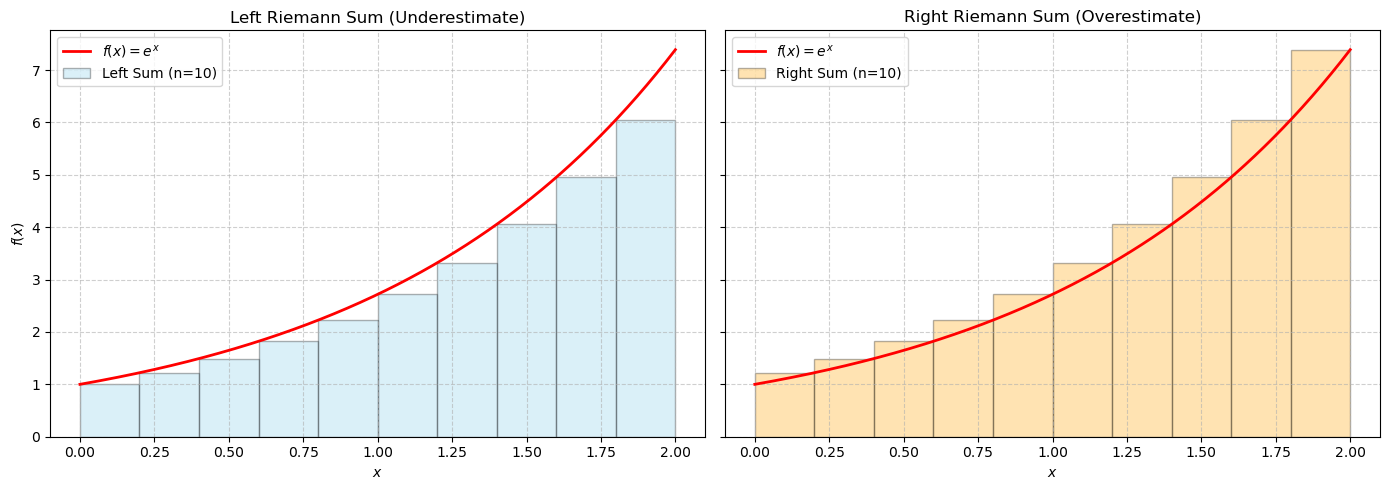

In [2]:
# 1. Define the function
def f(x):
    return np.exp(x)

# 2. Set interval and number of partitions
a, b = 0, 2
n = 10
dx = (b - a) / n

# 3. Generate data for the smooth curve
x_curve = np.linspace(a, b, 500)
y_curve = f(x_curve)

# 4. Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Subplot 1: Left Riemann Sum ---
x_left = np.linspace(a, b - dx, n)
y_left = f(x_left)

ax1.plot(x_curve, y_curve, 'r', lw=2, label=r'$f(x) = e^x$')
ax1.bar(x_left, y_left, width=dx, align='edge', alpha=0.3, 
        color='skyblue', edgecolor='black', label=f'Left Sum (n={n})')
ax1.set_title('Left Riemann Sum (Underestimate)')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$f(x)$')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Subplot 2: Right Riemann Sum ---
x_right_edges = np.linspace(a, b - dx, n) # Where the bar starts drawing
x_right_points = np.linspace(a + dx, b, n) # Where height is sampled
y_right = f(x_right_points)

ax2.plot(x_curve, y_curve, 'r', lw=2, label=r'$f(x) = e^x$')
ax2.bar(x_right_edges, y_right, width=dx, align='edge', alpha=0.3, 
        color='orange', edgecolor='black', label=f'Right Sum (n={n})')
ax2.set_title('Right Riemann Sum (Overestimate)')
ax2.set_xlabel('$x$')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Note, it doesn't matter if we evaluate on the left or the right of each sub-interval (rectangle). 

Assuming $x\ge a$, and $x+\Delta x \le b$,
* Left plot shows that we are using $f(x)$ from the left side of the rectangle to calculate the area, $f(x) \cdot \Delta x$.
  * This creates gap under the curve.
* Right polt shows another way, to evaluate from the right side of the rectangle. $f(x+\Delta x) \cdot \Delta x$
  * note $(x+\Delta x)$ in function domain.
  * This would result in a gap over the curve.
* If functions are continuous, then the two approaches will converge on the same value as $\Delta x \rightarrow 0$.
  * The area of the gap would $\rightarrow 0$ too.


Next, if we push the number of these rectangles to infinite $\lim_{n \rightarrow \infty}$. We'll have the $\sum$ form of Riemann Summation
1. Left Riemann Sum: You use the height at the start, $i \in (0, n-1)$ to be in function domain, of each rectangle (interval).
$$\int_{a}^{b} f(x) dx = \lim_{n \to \infty} \sum_{i=0}^{n-1} f(x_i) \Delta x$$
2. Right Riemann Sum: You use the height at the end $i \in (1, n)$ to be in function domain, of each rectangle (interval).
$$\int_{a}^{b} f(x) dx = \lim_{n \to \infty} \sum_{i=1}^{n} f(x_i) \Delta x$$
3. General Riemann Sum: You use a "sample point" $x_i^*$ anywhere in the interval $[x_{i-1}, x_i]$.
$$\int_{a}^{b} f(x) dx = \lim_{n \to \infty} \sum_{i=1}^{n} f(x_i^*) \Delta x$$

__Transform the Riemann sum using the Mean Value Theorem (MVT)__

The ***mean value theorem*** states that if a function $F(x)$ is smooth and continuous on the domain $[x_i,x_i+\Delta x]$, then there exists a point $c\in[x_i,x_i+\Delta x]$ such that 

$$\displaystyle F'(c)=\frac{F(x_i+\Delta x)-F(x_i)}{x_i+\Delta x-x_i}=\frac{F(x_i+\Delta x)-F(x_i)}{\Delta x}$$

Note, geometrically, the value of a derivative at a specific point ($F'(c)$ here) is indeed the slope of the function at that excat location. The tangent line represented by $F'(c)$ equals the slope of $\frac{F(x_i+\Delta x)-F(x_i)}{\Delta x}$. 

To transform the Riemann sum using the Mean Value Theorem (MVT), we'll apply the MVT to each of these rectangles (sub-interval of the partition).

1, The Core TransformationIf we let $F(x)$ be an antiderivative of $f(x)$ (meaning $F'(x) = f(x)$), we can apply the Mean Value Theorem for derivatives to each sub-interval $[x_i, x_i+\Delta x]$, within the function domain.
* The MVT states that there exists a point $x_i^*$ in each sub-interval $[x_i, x_i+\Delta x]$ such that:
$$F'(x_i^*)=\frac{F(x_i+\Delta x)-F(x_i)}{x_i+\Delta x-x_i}$$
with $F'(x_i^*) = f(x_i^*)$, each sub-interval can be expressed as
$$f(x_i^*) \Delta x = F(x_i+\Delta x)-F(x_i)$$

2, Adding all sub-intervals to get the $\sum$ form.
$$\sum_{i=1}^{n} f(x_i^*) \Delta x = \sum_{i=1}^{n} [F(x_i) - F(x_{i-1})]$$
Expand the right-hand side to get a telescoping sum:
$$(F(x_1) - F(x_0)) + (F(x_2) - F(x_1)) + \dots + (F(x_n) - F(x_{n-1}))$$
Eevery middle term cancels out, and we got the final value minus the starting value:
$$\sum_{i=1}^{n} f(x_i^*) \Delta x = F(x_n) - F(x_0) = F(b) - F(a)$$


__Relating integrals to derivatives (Fundamental Theorem of Calculus)__

As the partitions get infinitely refined (infinite sub-intervals), we can use Riemann sums to relate $f(x)$ to its __antiderivative $F(x)+c$__.

Now, we push $n$ to the limit $\lim_{n\to\infty}$, note $c$ cancel out.
$$\int_{a}^{b} f(x)dx = \lim_{n\to\infty} \sum_{i=1}^{n} f(x_i^*)\Delta x=F(b)-F(a)$$




<font color="purple">**Question 1:** What is $\displaystyle\int f(x)\,dx$?</font>

Remembering the Power Rule for deriviatives, we see that $F(x)=\frac{3}{5}x^5$ is an antiderivative of $f(x)$ because $F'(x)=f(x)$. 

Because limits of integration are not specified, we know that any solution to $\displaystyle\int f(x)\,dx$ must differ from $F(x)$ by a constant. 

So, we conclude $\displaystyle\int f(x)\,dx=F(x)+c=\frac{3}{5}x^5+c$

<font color="purple">**Question 2:** What is $\displaystyle\int_a^b f(x)\,dx$?</font>

Using the fundamental theorem of calculus, we conclude that $\displaystyle\int_a^b f(x)\,dx=F(b)+c-\left(F(a)+c\right)=F(b)-F(a)=\frac{3}{5}b^5-\frac{3}{5}a^5$

<font color="purple">__Question 3:__ Write code to calculate the Riemann sum to approximate $\hspace{.5cm}\displaystyle\int_2^4 5x^7+3x^2+2\,dx$<font>
* use a partition with equally-sized bins of width $\hspace{.25cm}dx=.1$ $\Rightarrow \Delta x=0.1$
* use the partition $\hspace{.25cm}P=\{(2,2.1),\,(2.1,2.2),\dots,(3.9,4)\}$ $\Rightarrow n = (4 - 2) / \Delta x=20$
* Use left-side evaluation.$\int_{2}^{4} f(x) dx = \sum_{i=0}^{20} f(2 + i * \Delta x) \Delta x$
```python
r_sum = 0
for i in range(n): 
    x = 2 + i*0.1
    sub_area = (5*x**7 + 3x**2+2) * 0.1
    r_sum = r_sum + sub_area
```

### Jan-23-2026

#### Techniques for Solving Integrals
* Try to relate $f(x)$ to its __antiderivative $F(x)+c$__.
* Integration by Substitution.
* Integrationo by Parts.

__tech 1,__ Try to relate $f(x)$ to its antiderivative $F(x)+c$.
* We solve integrals by remembering functions derivatives and trying to do reverse mapping.
* Antidifferentiation: Fundamental Theorem of Calculus

For example,
- if $\hspace{.5cm}f(x)=1/x,\hspace{.5cm}$ then $\hspace{.5cm}F(x)=\ln(x)\hspace{.5cm}$ because $\hspace{.5cm}\frac{d}{dx}\ln(x)=1/x$
- if $\hspace{.5cm}f(x)=e^x,\hspace{.5cm}$ then $\hspace{.5cm}F(x)=e^x\hspace{.5cm}$ because $\hspace{.5cm}\frac{d}{dx}e^x=e^x$
- If $\hspace{.5cm}f(x) = x^n$, then $F(x) = \frac{x^{n+1}}{n+1}$
- If $\hspace{.5cm}f(x) = \cos(x)$, then $F(x) = \sin(x)$ because $\frac{d}{dx}\sin(x) = \cos(x)$.
- If $\hspace{.5cm}f(x) = \sin(x)$, then $F(x) = -\cos(x)$ because $\frac{d}{dx}\cos(x) = -\sin(x)$. 

__tech 2,__ Integration by Substitution
* Integration by Substitution is the inverse of the Chain Rule:
* For derivative's Chain Rule with $F(x)=H(G(x))\hspace{.5cm}$, we got $F'(x) = \frac{d}{dx}\bigl(H(g(x))\bigr)=H'(g(x))\cdot g'(x)$
* For Integration,
$$\begin{align}
\int_a^b f(x)dx
&= \int_a^b \color{orange}{h(g(x))\cdot g'(x)}dx\\
&= \int_a^b \color{darkmagenta}{H'(g(x))\cdot g'(x)}dx\\
&= \int_a^b \color{darkmagenta}{\frac{d}{dx}\bigl(H(g(x))\bigr)}dx\\
&= H(g(b)) - H(g(a))
\end{align}$$

For example, $f(x) = \frac{2x}{x^2}$,
*  we let $g(x) = x^2 \Rightarrow f(x) =  \frac{1}{g(x)} \cdot g'(x)$, 
* as the anti-derivative of $\frac{1}{g(x)}$ is $ ln(g(x)) \overset{g(x)=x^2}{=} ln(x^2)$
* Thus, $\int_a^b \frac {2x}{x^2} dx=  ln(a^2) - ln(b^2)$


__tech 3,__ Integration by Parts: $\int uv'dx = uv - \int vu'dx$
* Let's start with the Product Rule of the derivative: $\frac{d}{dx}[u(x)v(x)] = u'(x)v(x) + \color{red}u(x)v'(x)$
* Re-arrange it: $\color{red}u(x)v'(x) \color{black}= \frac{d}{dx}[u(x)v(x)] - u'(x)v(x)$
  * Note this, $\frac {dv(x)}{dx} = v'(x) \Rightarrow dv(x) = v'(x)dx$, it's oftern shorten as $dv=v'(x)dx$
  * The integration of $\color{red}u(x)v'(x)$ is $\int u(x)v'(x) \cdot dx \Rightarrow \int udv$
* Integration on both sides, $\int udv = uv - \int vdu$
  * Key points: swap
  * $u$ gets differentiated (often simpler)
  * $v$ gets integrated
  * check if the new integral is easier.
* with domain a and b, ${\int_a^b u(x)\cdot v'(x)\,dx} = {u(b)\cdot v(b)-u(a)\cdot v(a)} - {\int_a^b u'(x)\cdot v(x)\,dx}$.

For example, $\int_a^b \frac{ln(x)}{x^2}dx$
* $u(x) = ln(x) \Rightarrow u'(x) = 1/x$, and $v'(x) = x^{-2} \Rightarrow v(x) = -x^{-1}$
* put $a, b$ aside, $\int \frac{ln(x)}{x^2}dx = uv - \int vd(u) = ln(x)(-x^{-1}) - \int (-x^{-1})d(ln(x)) = \frac {-ln(x)}{x} - \int (-x^{-2})dx$
* $\int (-x^{-2})dx = \frac {1}{x} \Rightarrow$ answer $\frac {-ln(x)}{x} - \frac {1}{x}$
  * Indefinite integrals: add a single $+c$ at end
  * Definite integrals: don’t include $+c$, they cancel out
  * No $+c$ inside the formula v, it’s redundant

For another example, $\int x^2e^x \, dx$, needs swap twice.
 * First swap, let $u = x^2$, and $v'=ex \Rightarrow v=e^x$, so $\int x^2e^x \, dx = x^2 \cdot e^x - \color{red}\int e^x \, d(x^2)$
 * Second swap, $\color{red}\int e^x \, d(x^2) = \int 2x e^x \, d(x) = \int 2x \,d(e^x)  \color{black} = 2x \cdot e^x - \int e^x \, d(2x) = 2x \cdot e^x - \int 2e^x \, dx = 2x \cdot e^x -2e^x$
 * Thus, $\int x^2e^x \, dx = x^2 \cdot e^x - \int e^x \, d(x^2)  = x^2 \cdot e^x - (2x \cdot e^x - 2e^x) = (x^2 -2x + 2)e^x + c$

Note, `\,dx` means a thin space in Latex.

Also, note, in SymPy, the natural logarithm $\ln(x)$ is represented by the function log(x). By default, the log function in SymPy uses base $e$.

In [6]:
#sympy code to test tech 3 examples
x = sp.symbols('x')

example1 = sp.ln(x) / x**2

example2 = x**2*sp.exp(x)

sp.integrate(example1, x)
#sp.integrate(example1, x)

-log(x)/x - 1/x

#### Multiple Integral, Partial Integrals, & Programming Integrals

As with derivatives, we can take ***multiple integrals*** (e.g., to find a distance function from an acceleration function) and we can find ***partial integrals*** related to a single variable even if a function depends on multiple variables.

First, let's cover symbolic programming techniques for calculating integrals using SymPy.

SymPy uses various approaches to definite integration. One method is to
find an antiderivative for the integrand, and then use the fundamental
theorem of calculus.

Let $f_2(t)$ represent a car's acceleration over time.

Recall that the acceleration function is the derivative of the car's speed-over-time function, which is itself the derivative of the car's distance-over-time function.

Thus, the speed-over-time function is $\hspace{.5cm}\displaystyle f_1(t) = \int f_2(t)\,dt$

And, the distance-over-time function is $\hspace{.5cm}\displaystyle F(t)=\int f_1(t)\,dt= \int\left(\int f_2(t)\,dt\right)\,dt$

In [39]:
import sympy
t,a = sympy.symbols('t a')
# define an acceration function where a car accelerates at a constant rate a over time
f2 = a*t
f2

a*t

In [41]:
# calculate the integral of ff to find the speed-over-time function 
f1 = sympy.integrate(f2,t)
f1

a*t**2/2

In [42]:
# calculate the integral of f to identify the distance-over-time function
F = sympy.integrate(f1,t)
F 

a*t**3/6

In [43]:
# Let's verify that taking derivatives returns us to our starting position
sympy.diff(F,t)

a*t**2/2

In [44]:
# take the second derivative of F(t) with respect to t
sympy.diff(F,t,2)

a*t

#### Partial Integrals

Let's consider a function on multiple variables.

$
\displaystyle
f(x,y) = x^2-y^2
\hspace{.5cm}
$
which is called a "saddle function" because the plot looks like a horse's saddle (as we will see).

Similar to partial derivatives, we calculate partial integrals with respect to one variable at a time while treating other variables like constants. For example, the integral of $f(x,y)$ with respect to $x$ is identified by the used of $dx$ in the integral.

$
\displaystyle
\int f(x,y)\,dx = \int \color{red}{x^2} - \color{blue}{y^2}\,dx = \color{red}{\int x^2\,dx}-\color{blue}{\int y^2\,dx} = \color{red}{\frac{1}{3}x^3}-\color{blue}{xy^2}+c
$

Let's see this using SymPy.

In [45]:
x,y = sympy.symbols('x y')
f_saddle = x**2-y**2
f_saddle

x**2 - y**2

In [47]:
# integrate with respect to x
sympy.integrate(f_saddle,x)

x**3/3 - x*y**2

In [48]:
# integrate with respect to y
sympy.integrate(f_saddle,y)

x**2*y - y**3/3

#### Coding Integrals with Limits

Let's say you want to solve the integral 
$
\hspace{.5cm}
\displaystyle
\int_a^b \sin(x)\,dx
$

In [50]:
# add example of integration with limits
# sympy.integrate(f,(x,-1,1))
a,b,x = sympy.symbols('a b x')
f = sympy.sin(x)
sympy.integrate(f,(x,5,10))

cos(5) - cos(10)

### Jan-26-2026

#### Module 7: Conditional Probabilities, Bayes' Theorem, and Probability Theory
This module will introduce basic concepts from probability theory.

Review basic concepts from probability theory, including conditional probability, Bayes’ Theorem, discrete probability distributions, and continuous probability distributions.
* M7 Lecture 1: Intro to Probability Theory
  * Frequentist approach: fair coin, $p(H) = p(T) = 0.5$
  * Bayesian approach: ~ biased coin, $p(H) =  1 - p(T)$, $p(H|D) = \frac {p(D|H)p(H)}{p(D)} = \frac {p(D|H)p(H)}{p(H)p(D|H) + p(T)p(D|T)}$ 
  * iid, Independent and Identically Distributed; 
* M7 Lecture 2: Probability is Area
* M7 Lecture 3: Conditional Probability
* M7 Lecture 4: Bayes' Theorem
* M7 Lecture 5: Programming Bayesian Inference to Learn from Data
* M7 Lecture 6: Bernoulli Distribution
* M7 Lecture 7: Binomial Distribution
* M7 Lecture 8: Geometric Distribution
* M7 Lecture 9: Poisson Distribution
* M7 Lecture 10: Discrete Uniform Distribution
* M7 Lecture 11: Normal Distribution
* M7 Lecture 12: Student's t Distribution
* M7 Lecture 13: Hypothesis Testing


#### We Have Yet Again Crossed the River of Statistics
So, in order to make things easier. Let's clear up the names and notations; and, hopefully, we can create several easy-to-use `Statistics Box` to contain real-life questions.
* 1, Statistics, you describe something after you have all the data
  * If you have done a `Census` of a `Population`, you would have aleary have all the data you care.
  * Thus, you now have parameters like, `population mean` $\mu$, `population standard deviation` $\sigma$, `population variance` $Var(X)$
  * And the plot will be a `histograms`, or `barchart`, either way, it's not a `probability distribution`.
* 2, Probability Distributions, that's inference, you predict based on the small piece of data you got from sampling.
  * Sample, it has a `sample size` $n \ge 1$, each data point in the sample is called a `single observation`. 
  * You might find the word `t-statistic`, that's the sample statistics, like `sample mean` $\bar x$,  `sample standard deviation` $s$, or `SEM` standard error of the sample mean.
  * Here's quick explaination: $SEM = \dfrac{s}{\sqrt n}$, or $\displaystyle\dfrac{Var(x)}{n} = Var(\bar x) = Var(\frac{1}{n}\sum^nx)\overset{\text{square out of Var}}{=} \frac{1}{n^2}\sum^nVar(x)$.



#### (Better Phrased)We Have Yet Again Crossed the River of Statistics
>To make things precise, let’s clear up names and notation so we can build reusable **Statistics Boxes** for real-world questions.

1, Descriptive Statistics (Observed Data)
* Descriptive statistics summarize **observed data**, whether from a sample ($n \ge 1$) or a census.
* If a **census** of a **population** is performed:
  * All data you care is ready to be stated, no need for prediction
  * All units are observed
  * Population parameters are known constants:
    * Population mean ( $\mu$ )
    * Population variance ( $\sigma^2 = \operatorname{Var}(X)$ )
    * Population standard deviation ( $\sigma$ )
* Visualizations such as **histograms** or **bar charts** display empirical frequencies; they are **not probability distributions**, though they may approximate one.

2, Probability Models and Statistical Inference
* **Probability distributions** model randomness at the population level.
* **Statistical inference** uses these models to reason from a **sample** to a population.
* A **sample** has size ( $n \ge 1$ ).
* Each data point is a **single observation** (a realization of a random variable).
* Common sample statistics:
  * Sample mean ( $\bar x$ )
  * Sample standard deviation ( $s$ )
  * Standard error of the mean (SEM):$\frac{s}{\sqrt n}$
* At the random-variable level:$\operatorname{Var}(\bar X)   = \operatorname{Var}\left(\frac{1}{n}\sum_{i=1}^n X_i\right)  = \dfrac{\sigma^2}{n} \quad \text{(iid assumption)}$


#### Probability $P \in [0, 1]$
* Probability deals with predicting the Likelihood of future events;
  * In Bayes' Theorem, this likelihood $p(H|E)$ will update our 'belief/knowledge' of $p(H)$
  * Then do this over and over, to test our $p(H)$, sometimes, it converges to 0.
* while Statistics analyzes the frequency of past event.
* Well, when we say `Pack the question into a Statistics Box`. They mean the same.

In Lecture definition: probability is
* a type of mathematics for describing the __odds__ of different outcomes.
* rolling a 6-sided die, then the possible outcomes are $D=\{1,2,3,4,5,6\}$ and, $\hspace{.5cm}\displaystyle1=\sum_{d\in D} p(D=d)$
* frequentist approach : independent means that previous trials in no way effect future trials.


Note the idea of a `weighted unfair coin` with this example
* basketball players make their free-throws more often than 50%, similiar to a weighted unfair coin.

#### Let's start with some basics for $p(A)$ and $p(B)$
* $A$ and $B$ are independent of each other
  * Intersection: $p(A\cap B)=p(A)p(B)$
  * Union: $p(A \cup B) = p(A)+p(B)-p(A)p(B)$
* $A$ and $B$ are mutually exclusive of each other
  * Intersection: $p(A\cap B)=0$
  * Union: $p(A \cup B) = p(A)+p(B) + 0$

#### Conditional Probability $\hspace{.25cm}p(A|B)$
* Conditional probability asks: Given that event $B$ has occurred, how likely is event $A$?
* When events $A$ and $B$ are **not independent**,and $p(B) \neq 0$
  * their joint probability does **not** factor: $p(A \cap B) \neq p(A) \, p(B)$
  * The conditional probability of $A$ given $B$ is defined as: $\hspace{.25cm} p(A \mid B) = \frac{p(A \cap B)}{p(B)}$
* If $A$ and $B$ are **independent**, then: $p(A \cap B) = p(A)\,p(B)$
  * Substituting into the definition: $p(A \mid B) = \frac{p(A) \, p(B)}{p(B)} = p(A)$
  * note this wording: when $A$ and $B$ are independent, knowing that $B$ occurred **does not change** the probability of $A$.
  * also can say, provides no additional information about $A$.


In [12]:
# demo to understand if A and B are independent: P(A∩B)≠P(A)*P(B)

#1. Initialize the Generator (the modern way)
rng = np.random.default_rng(seed=42)

#2. Use integers() instead of randint()
# Note: endpoint=False is the default, so 2 means [0, 1]
data = {'Coin_A': rng.integers(0, 2, size=100),
        'Coin_B': rng.integers(0, 2, size=100)}
df = pd.DataFrame(data)

# Note, we need to make sure this is done when both A and B have outcomes
# This will have A and B with the same row size
df = df.dropna()

#3. The probability of Coin_A as head, Coin_B as head, 
p_a = df['Coin_A'].mean()
p_b = df['Coin_B'].mean()

#4. the main point we try to clear out: P(A=head | B=head) ≠ (P(A)*P(B)/P(B))
# Detailed steps for Conditional Probability
# P(A∩B): Count where both are 1, divided by total complete pairs
both_heads_count = df[(df['Coin_A']==1) & (df['Coin_B']==1)].shape[0]
p_a_cap_b = both_heads_count / df.shape[0]

# P(A=head | B=head) using the formula
p_a_given_b = p_a_cap_b / p_b

#5. the final
print('the probability of A=head is P(A=head)', p_a)
print('the probability of B=head is P(B=head)', p_b)
print('the probability of A and B are both head, is P(A=head ∩ B=head)', p_a_cap_b)
print('the conditional probability of A=head given B=head is P(A=head | B=head)', round(p_a_given_b, 4))
print('because P(A=head | B=head) ≠ P(A), we know A and B are not independent.')

the probability of A=head is P(A=head) 0.52
,the probability of B=head is P(B=head) 0.49
,the probability of A and B are both head, is P(A=head ∩ B=head) 0.29
,the conditional probability of A=head given B=head is P(A=head | B=head) 0.5918
,because P(A=head | B=head) ≠ P(A), we know A and B are not independent.


#### Understanding: If $A$ and $B$ are independent, then: $p(A \cap B) = p(A) \cdot p(B)$
* Checing if $P(A|B) = P(A)$ is actually the default way to tell if $A$ and $B$ are (independent: $p(A \cap B) = p(A) \cdot p(B)$)
* In statistics, independence is a property we test for, not a rule we take for granted.

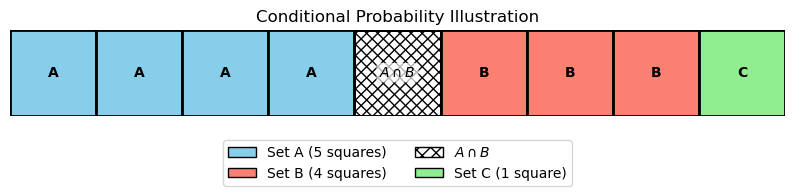

In [20]:
#import matplotlib.pyplot as plt
#import matplotlib.patches as patches

def draw_cross_hatched_squares():
    fig, ax = plt.subplots(figsize=(10, 3))
    
    # Define colors
    color_a = 'skyblue'
    color_b = 'salmon'
    color_c = 'lightgreen'
    
    # 9 squares horizontally (indices 0 to 8)
    for i in range(9):
        edgecolor = 'black'
        label_text = ''
        rect_pos = (i, 0)
        
        if i < 4:
            # Set A
            rect = patches.Rectangle(rect_pos, 1, 1, linewidth=2, edgecolor=edgecolor, facecolor=color_a)
            ax.add_patch(rect)
            label_text = 'A'
        elif i == 4:
            # Overlap A & B: Crossing lines from color A and color B
            # 1. Base rectangle for the border and background
            rect_base = patches.Rectangle(rect_pos, 1, 1, linewidth=2, edgecolor=edgecolor, facecolor='white')
            ax.add_patch(rect_base)
            
            # 2. Lines from color A (diagonal hatch)
            # Hatch color in matplotlib is controlled by the edgecolor
            hatch_a = patches.Rectangle(rect_pos, 1, 1, fill=False, edgecolor=edgecolor, hatch='\\\\\\', linewidth=2)
            ax.add_patch(hatch_a)
            
            # 3. Lines from color B (reverse diagonal hatch)
            hatch_b = patches.Rectangle(rect_pos, 1, 1, fill=False, edgecolor=edgecolor, hatch='///', linewidth=2)
            ax.add_patch(hatch_b)
            
            label_text = r'$A \cap B$'
        elif 4 < i < 8:
            # Set B
            rect = patches.Rectangle(rect_pos, 1, 1, linewidth=2, edgecolor=edgecolor, facecolor=color_b)
            ax.add_patch(rect)
            label_text = 'B'
        elif i == 8:
            # Set C
            rect = patches.Rectangle(rect_pos, 1, 1, linewidth=2, edgecolor=edgecolor, facecolor=color_c)
            ax.add_patch(rect)
            label_text = 'C'
            
        # Add text label in the middle of the square
        if label_text:
            # Add a small white background behind text in the overlap for better readability
            bbox_props = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7) if i == 4 else None
            ax.text(i + 0.5, 0.5, label_text, ha='center', va='center', fontweight='bold', bbox=bbox_props)

    # Setting plot limits and removing axes
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Custom Legend
    legend_elements = [
        patches.Patch(facecolor=color_a, edgecolor='black', label='Set A (5 squares)'),
        patches.Patch(facecolor=color_b, edgecolor='black', label='Set B (4 squares)'),
        patches.Patch(facecolor='white', edgecolor='black', hatch=r'///\\', label=r'$A \cap B$'),
        patches.Patch(facecolor=color_c, edgecolor='black', label='Set C (1 square)')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

    plt.title("Conditional Probability Illustration")
    #plt.savefig('cross_hatched_squares.png', bbox_inches='tight')
    plt.show()

draw_cross_hatched_squares()


#### Understanding Conditional Probability, with above illustration
* probability of $A: \hspace{1cm} P(A) = 5 / 10$
* probability of $B: \hspace{1cm} P(B) = 4 / 10$
* probability of $C: \hspace{1cm} P(C) = 1 / 10$
* probability of $A \cap B: \hspace{1cm} P(A \cap B) = 1 / 10$
* probability of $A|B: \hspace{1cm} P(A|B) = \frac {P(A \cap B)}{P(B)} = \frac{1 / 10}{4 / 10} = 1/4$
  * as illustrated as 1 $A \cap B$ square, given total 4 $B$ squares.
  * note, as P(A|B) doesn't equal to P(A). we konw A and B are not independent.
* probability of $B|A: \hspace{1cm} P(B|A) = \frac {P(A \cap B)}{P(A)} = \frac{1 / 10}{5 / 10} = 1/5$
  * as illustrated as 1 $A \cap B$ square, given total 5 $A$ squares.
* checking with Bayes' Theorem
  * $P(A|B) = \frac {P(B|A) \cdot P(A)}{P(B)} = \frac {\frac{1}{5} \times \frac{5}{10}}{\frac{4}{10}} = \frac{1}{4}$

#### Illustrated with coinflip-dice roll game
* a two-step random process where we first flip coin with probabilities $p(H)$ for heads and $p(T)$ for tails.
  * If we get heads, then we roll a fair 6-sided dice.
  * If we get tails, then we roll a fair 20-sided dice.

What is the probability that the outcome of my dice roll is 5?
* Case 1: my coin flip came up heads (given probability $p(H)$) and I rolled a 6-sided dice.
  * Thus, the probability of $D=5$ <u>"conditional on"</u>, or <u>"given,"</u> a heads is $p(D=5 | H) = 1/6$.
  * The probability of this outcome is $\color{red}{p(\text{Case}_1)=p(H)\cdot p(D=5 | H) = p(H)\cdot 1/6}$

* Case 2: Similarly, my coin flip came up tails (given probability $p(T)$ ) and I rolled a 20-sided dice.
  *  Thus, the probability of $D=5$ "given" a tails is $p(D=5 | T) = 1/20$
  *  The probability of this outcome is $\color{blue}{p(\text{Case}_2) = p(T)\cdot p(D=5 | T) = p(T)\cdot 1/20}$
* Thus, A dice outcome of 5 can occur under Case 1 or Case 2, so we add the probabilities together:

  * $p(D=5) = \color{red}{p(\text{Case}_1)}+\color{blue}{p(\text{Case}_2)} = \color{red}{p(H)\cdot 1/6}+\color{blue}{p(T)\cdot 1/20}$

#### Deriving Bayes' Theorem
* with generalized Condistional Probability $\hspace{.25cm}p(A|B)=\frac{\color{darkgreen}{p(A\cap B)}}{\color{orange}{p(B)}}$
* and, similarly, $\hspace{.25cm} p(B|A)=\frac{\color{darkgreen}{p(A\cap B)}}{\color{darkmagenta}{p(A)}}$
* linking these two equations together, we have $\hspace{.25cm} \color{darkgreen}{p(A\cap B)} = p(A|B)\cdot \color{orange}{p(B)} = p(B|A)\cdot \color{darkmagenta}{p(A)}$
* This derivation gives us ***Bayes' Theorem*** $p(A|B) = \frac{p(B|A)\cdot p(A)}{p(B)}$
  * $p(A|B)$, posterior, the probability of A being true, given B is true.
  * $p(B|A)$, likelihood
  * $p(A)$, prior, the probability of A being true; this is the knowledge.
  * $p(B)$, marginalization


#### Describing the Bayes' Box
$p(\theta \mid \text{data}) = \frac {p(\text{data} \mid \theta) \, p(\theta)}{p(data)}$
* Prior, Knowledge, what you believe before data. $p(\theta)$, will be replaced by $p(\theta \mid \text{data})$ in the next circle.
* Likelihood, data model, $p(\text {data} \mid \theta)$
* Posterior, your updated belief, $p(\theta \mid \text{data})$, will be used as Prior $p(\theta)$ in the next circle.


#### Pack an unfair coin into Bayes' Box
* coinflip-dice roll game: I tell you that I rolled a die and got a 5, what is the probability that the coin flip came up heads?

Steps of packing a problem into statistics box:
1. $p(H|D_5)$, given that 'I rolled a die and got a 5'
2. pack this into Bayes' Box: $p(H|D_5) = \frac {p(D_5|H)p(H)}{p(D_5)}$
3. what's known: $p(D_5|H) = 1/6$, because Head=6 faced die, and Tail=20 faced die.
4. what's also known: $p(D_5) = p(H) \cdot (1/6) + p(T) \cdot (1/20)$
5. it's a unfair coin, so we only know $p(H) + p(T) = 1 \Rightarrow p(D_5) = p(H) \cdot (1/6) + (1-p(H)) \cdot (1/20)$
6. so, put all we know into step 2, $p(H|D_5) = \frac {p(D_5|H)p(H)}{p(D_5)} = \frac {(1/6) \cdot p(H)}{p(H) \cdot (1/6) + (1-p(H)) \cdot (1/20)} = \frac{10p(H)}{7p(H)+3}$

#### Mind game, or Experiment
* Once we got $p(H|D_5) = \frac{10p(H)}{7p(H)+3}$, we can do 'thousands' trials of 'coinflip-dice roll' to get this value $p(H|D_5)$
* and calculate this unfair coin's $p(H)$
* This example seems a bit unnecessary, bcause we could also just toss the unfair coin to count $p(H)$.

#### Bayes' Theorem for Hypothesis testing 
* Bayes' Theorem is immensely important in probability theory and in machine learning. 
* Bayes' Theorem is useful for machine learning because this equation allows us to estimate $p(A|B)$ with an initial guess and then update our estimate of $p(A|B)$ as we collect new data.
* $p(H|E)$ is called the <i>posterior probability</i>

Here, let $H$ denote a hypothesis and $E$ denote the evidence collected so far.

$\displaystyle
p(H|E) = \frac{p(E|H)\cdot p(H)}{p(E)}=\frac{p(E|H)\cdot p(H)}{p(E|H)\cdot p(H)+p(E|\neg H)\cdot p(\neg H)}
\hspace{.25cm}$
* where $\neg H$ represents "not $H$"

$p(H|E)$ is called the <i>posterior probability</i> and represents the probability that our $H$ hypothesis is correct given the evidence $E$.

<ul>
    <li>$p(H)$ is the <i>prior probability</i> that the hypothesis is correct without additional evidence</li>
    <li>$p(E)$ is the <i>marginal likelihood</i> </li>
    <li>$p(E|H)$ is the <i>likelihood</i> representing the probability of the observed evidence $E$ if we assume the hypothesis $H$ is true</li>
</ul>

We can write Bayes' Theorem differently to make it more useful for hypothesis testing and learning

$
\displaystyle
p(H|E) = \frac{p(E|H)\cdot p(H)}{p(E)}=\frac{p(E|H)\cdot p(H)}{p(E|H)\cdot p(H)+p(E|\neg H)\cdot p(\neg H)}
\hspace{.25cm}
$
where $\neg H$ represents "not $H$"

Or, if we test multiple hypotheses $H_1,H_2,\dots,H_n$, then the probability to hypothesis $H_i$ given the current evidence $E$ is

$
\displaystyle
p(H_i|E) = \frac{p(E|H_i)\cdot p(H_i)}{p(E)}=\frac{p(E|H_i)\cdot p(H_i)}{\sum_{j=1}^n p(E|H_j)\cdot p(H_j)}
\hspace{.25cm}
$

#### Example: Bayes' Theorem on False Postive Rate
* Imagine there is a COVID-19 test that is positive 80% of the time: $\hspace{.25cm}\color{blue}{p(\text{test positive})}=0.80$.
* Some of these positive outcomes will be __false positives__ and some will be __true postives__.
* However, in controlled lab experiments,
  * pharmaceutical companies show that the test correctly detects a COVID infection 90% of the time.
  * That is,given confirmed COVID infection, it can only detect 90% of the cases: $\hspace{.25cm}\color{red}{p(\text{test positive}|\text{COVID infected})} = 0.90$
* You guess that there is a 70% chance that you have COVID.
  * That is, you currently believe $\hspace{.25cm}\color{orange}{p(\text{COVID infected})}=0.70$
* So, you take the COVID test, and it comes back positive.


Question, what is the probability that you actually have a COVID infection, given the postive test result.
* pack it into the Bayes' Box
* What's $\color{darkmagenta}{p(\text{COVID infected}|\text{test positive})}$)?

#### Pack a COVID test into Bayes's Box
1. hypotheses are $H=\text{COVID positive}$ and $\neg H=\text{not COVID positive}$
2. and your evidence $E$ is the positive COVID test.
3. pack them into Bayes' Box,
$\color{darkmagenta}{p(\text{COVID infected}|\text{test positive})}
= \frac{ \color{red}{p(\text{test positive}|\text{COVID infected})}\cdot \color{orange}{p(\text{COVID infected})} }{  \color{blue}{p(\text{test positive})}}
= \color{black} \frac{0.90\cdot0.70}{0.80}=0.7875$
4. posterior probability: your belief that you have COVID increases from $\hspace{.25cm}\color{orange}{p(\text{COVID infected})}=0.70\hspace{.25cm}$ to $\hspace{.25cm}\color{darkmagenta}{p(\text{COVID infected}|\text{test positive})}=0.7875\hspace{.25cm}$ with the evidence of a positive COVID test.
5. the next circle, update the estimate (belief) with posterior probability
* If your roommate has been in contact with you and also tests positive, then they might repeat this process
* but with the updated prior belief of $\hspace{.25cm}\color{orange}{p(\text{COVID infected})}=0.7875\hspace{.25cm}$ instead of your initial prior belief of 0.7.
* These additional positive tests are additional evidence that can be used to again update beliefs of a COVID infection.
$\color{darkmagenta}{p(\text{COVID infected}|\text{test positive})}
= \frac{ \color{red}{p(\text{test positive}|\text{COVID infected})}\cdot \color{orange}{p(\text{COVID infected})} }{  \color{blue}{p(\text{test positive})}}
= \frac{0.90\cdot0.7875}{0.80}=0.8859$

From this example, you can see how additional evidence allows us to ***learn*** and update our beliefs about the probability of an outcome (here, a COVID infection given a positive test).

### Jan-27-2026

#### Programming Bayesian Inference to Learn from Data
* I have two coins. One is fair (unweighted) and the other is weighted so that a coin flip yields heads ($E=1$) 60% of the time.
* I hand you a coin but you do not know if it is fair or weighted. You inspect the coin and don't notice anything strange. It's feels like a normal coin.


#### Let's pack this into Bayes' Box, and run an experiment with Python circles
* Step 1, our initial hypothesis $H$ is that the coin is fair and, because there were two possible coins,
  * our belief in $H$ is $\hspace{.25cm}p(\text{heads}|H)=1/2$
  * and the alternative hypothesis $\neg H$ is that the coin is weighted, $\hspace{.25cm} p(\text{heads}|\neg H)=6/10$
* Step 2, we conduct a series of coin flip outcomes (1 for heads) and we can use Bayes' Theorem to update our belief in the hypothesis $H$ that the coin is fair.
```python
# flip an unfair coin for 100 times
R = np.random.RandomState(1234)
coinFlips = R.choice([0,1],size=100,p=[.4,.6])
```
* Step 3, pack them into Bayes' Box $\hspace{.25cm}p(H|E) = \frac{p(E|H)\cdot p(H)}{p(E)}=\frac{p(E|H)\cdot p(H)}{p(E|H)\cdot p(H)+p(E|\neg H)\cdot p(\neg H)}$
  * given a 'fair coin hypothesis', the likelihood, $p(E \mid H) = 1/2$
  * with 0 data from our experiment, the probability of our hypothesis is right or wrong stays the same. $p(H) = 1/2$, and $p(\neg H) = 1/2$
  * run the Python circles, round 1, the first flip is a Tail $E=$ `coinFlips[0] = 0`
  * what's $p(E_0)$ from round 1 data, $p(E_0) = p(E_0|H)\cdot p(H)+p(E_0|\neg H)\cdot p(\neg H) = \frac{1}{2}\cdot\frac{1}{2}+\frac{4}{10}\cdot\frac{1}{2}=\frac{9}{20}$
  * so we have, $p(H|E) = \frac{p(E|H)\cdot p(H)}{p(E)} = \frac{ \frac{1}{2}\cdot\frac{1}{2} }{\frac{9}{20}}
=\frac{5}{9}$
* Step 4, update our belief $p(H) = p(H|E) = 5/9$, from the original $1/2$
* Step 5, power the Python circle on, to finish our 100 coin flip experiment.
  * plot and check out, the updated belief $p(H|E)$
  * if our hypothesis $H: \text{the coin is fair}$ is true, then $p(H|E)$ will converge to 1, otherwise, to 0.

In [3]:
# Flip the unfair coin (0.6) for 100 times
# seed the random number generator so that data is reproducible
R = np.random.RandomState(1234)
coinFlips = R.choice([0,1],size=100,p=[.4,.6])
#coinFlips

# lecture gives three different initial belief in H
#PHs = np.zeros((len(coinFlips)+1,3))
#ph = np.array([1/2,1/4,.75])
#PHs[0,:] = ph

# initial belief in (H: fair coin) is 1/2
ph = 0.5

# start an array to collect all the updated belief
ph_array = [ph]

for i in range(len(coinFlips)):
    outcome = coinFlips[i]
    
    #prepare p(E|H)
    p_e_given_H = 1/2

    #prepare p(E|notH): based on the outcome = coinFlips[i], head: 6/10, tail: 4/10
    p_e_given_not_H = 6/10 if outcome == 1 else 4/10

    #calculate p(E)=p(H)*p(E|H) + p(notH)*p(E|notH)
    p_e = ph*p_e_given_H  + (1-ph)*p_e_given_not_H
    
    #put all into Bayes' Theorem formula
    p_h_given_e = p_e_given_H * ph / p_e

    #update our belief
    ph = p_h_given_e

    #will have 101, initial beleif 0.5, and 100 updated p(H|E)
    ph_array.append(ph)

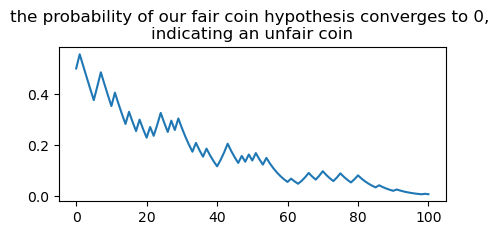

In [5]:
plt.figure(figsize=(5,2))
plt.plot(ph_array)
plt.title('the probability of our fair coin hypothesis converges to 0, \nindicating an unfair coin')
plt.show()

### Jan-28-2026

#### Many types of Probability Distributions
* probability distribution is the set of probabilities
  * know the $p \in [0, 1]$, probability
* associated with every possible outcome from an event.
  * know the $P(X=x)$, PMF or PDF(CDF)
* and the summary statistics, if $X$ is a `random variable`
  * Mean $E[X]$ and standard deviation $\sqrt {Var(X)}$ are distribution-independent concepts.
  * Expected value, mean: $\hspace{1cm} \displaystyle E[X] = \sum_{x\in X}x\cdot P(X=x)$
  * Variance of distribution: $\hspace{1cm} Var(X) = E\left[\left(X-E[X]\right)^2\right] = \displaystyle\sum_{x\in X} \left(x-E[X]\right)^2\cdot p(X=x)$
    * note the Variacne as a data-based definition: $\sigma ^2 = \sum \frac {(x - \mu)^2}{n}$
    * note for Sample if not full population: $s^2 = \frac {1}{n-1} \sum (x - \bar x)^2$
  * ???

NOTE, the deduction of Variance, $\hspace{1cm} Var(D) = E\left[\left(D-E[D]\right)^2\right] = \displaystyle\sum_{d\in D} \left(d-E[D]\right)^2\cdot p(D=d)$
* first of all, note that whether you call the value of head =1 or $f(x=1)$, it doesn't change its probability $p$. And the expected value $E[X] =f(x=1) \cdot p + f(x=0) \cdot (1-p)$
  * The probability of head $p$ doesn't change to $f(p)$, even if you use $f(x=1)$ as the head's value.
  * This pretty much explains, $Var[D] = \displaystyle\sum_{d\in D} \left(d-E[D]\right)^2\cdot p(D=d)$
* from the definition $Var[D]=E[(D-E[D])^2]$ to the computational formula $Var[D]=E[D^2]-(E[D])^2$
  * $E[D]$ is a fixed number, let's set it to $\mu$
  * $Var[D]=E[(D-\mu)^2]=E[D^2 - 2D\mu + \mu^2]$
  * Expand the expected value, $E[D^2 - 2D\mu + \mu^2] = E[D^2] - E[2D\mu] + E[\mu^2]$
  * set fixed number out, $E[D^2] - E[2D\mu] + E[\mu^2] = E[D^2] - 2\mu E[D] + \mu^2$
  * note, $E[D] =  \mu$, thus, $E[D^2] - 2\mu E[D] + \mu^2 = E[D^2] - \mu^2 = E[D^2] - (E[D])^2$




#### Figure this part out, it doesn't make sense.

* from the computationaly formula to the other definition $Var[D] = \displaystyle \sum_{d \in D}(d-E[D])^2 \cdot p(D=d)$
  * expand $E[D^2] = \displaystyle \sum_{d \in D} (d^2 \cdot p(D=d))$, note, we are squaring $d$'s value, its probability $p(D=d)$ stays the same.
  * note that the sum of all probabilities is 1. $\Rightarrow 1=\displaystyle \sum_{d \in D}p(D=d)$
  * thus, $1*\mu^2 = \mu^2 \displaystyle \sum_{d \in D}p(D=d) = \displaystyle \sum_{d \in D} \mu^2 \cdot p(D=d)$

Come back to edit later.

#### Discrete Probability Distributions
These apply when the outcomes are distinct, countable values (usually integers).

Bernoulli Distribution: The simplest form. A single trial with two outcomes: success or failure (e.g., one coin flip).

Binomial Distribution: Models the number of successes in a fixed number of independent Bernoulli trials (e.g., how many "heads" in 10 flips).

Poisson Distribution: Expresses the probability of a given number of events occurring in a fixed interval of time or space (e.g., how many emails you get in an hour).

Geometric Distribution: The number of trials needed to get the first success (e.g., how many times you flip a coin until it lands on heads).

Hypergeometric Distribution: Similar to Binomial, but used when sampling without replacement (e.g., drawing colored marbles from a jar without putting them back).



#### Continuous Probability Distributions
These apply when the variable can take any value within a range (including decimals).

Normal (Gaussian) Distribution: The famous "Bell Curve." Most values cluster around a central mean. It’s the gold standard for natural phenomena like height, IQ, or measurement errors.

Uniform Distribution: Every value in the range is equally likely (e.g., a random number generator picking a decimal between 0 and 1).

Exponential Distribution: Models the time between events in a Poisson process (e.g., the time you wait until the next bus arrives).

Student’s t-Distribution: Similar to the Normal distribution but with "fatter tails." Used frequently in statistics when the sample size is small.

Chi-Square Distribution: Used extensively in hypothesis testing and to see how well a model fits the actual data.

Beta Distribution: Often used to represent a distribution of probabilities; it’s very flexible and can take many shapes depending on its parameters.

#### Bernoulli Distribution, $X \sim \text{Bern}(p)$
* two outcomes, event = 1, and non-event = 0.
* probability of event =1 is $p$, and $(1-p)$ for non-event = 0.
* PMF, $$P(X = x) = p^x (1 - p)^{1 - x}, \quad x \in \{0, 1\}; \hspace{1cm} \text{  thus } \begin{cases} P(X=1)=p \\ P(X=0)=1-p \end{cases}$$
* expected value, $$E[X] = p\cdot1+(1-p)\cdot0 = \color{red}p$$
* variance, $$Var(X) = {p\cdot(1-\color{red}p\color{black})^2}+{(1-p)\cdot(0-\color{red}p\color{black})^2} 
= p(1-p)$$

#### Binomial Distribution, $S \sim \text{Bin}(n, p)$
* outcomes, sum of Bernoulli outcome (event = 1) in a total number of $n$ trials.
  * $S=\sum X$, for $X \sim Bern(p)$
* the choose opertator, (Binomial Coefficient), ${n \choose s} = \frac {n!}{(n-s)! \cdot s!}$
* PMF, $$P(S=s) = {n \choose s} p^s (1-p)^{n-s}$$
* expected value, $E[S]=n \cdot p$, and note the explaination
  * note, the expected value of a Binomial Distribution $S \sim \text{Bin}(n, p)$, is the **sum** of each Bernoulli outcome  $X_i$.
  * this means $\hspace{1cm} \displaystyle S = \sum _{i=1}^{n}X_i$, and thus $\hspace{1cm} E[S] = \displaystyle \sum _{i=1}^{n}E[X_i]$
  * we know that $E[X_i]=1 \cdot p + 0 \cdot (1-p) = p$
  * thus, $\hspace{1cm} E[S] = n \cdot E[X_i] = n \cdot (1 \cdot p + 0 \cdot (1-p)) = n \cdot p$
* variance, $Var(S) = np(1-p)$, and the explaination
  * use $Var[S] = E[S^2] - (E[S])^2) = E[S^2] - (np)^2$
  * ~~to deduct $E[S^2]$ is a bit tough. Leave it here for now.~~

### Jan-29-2026

#### (In my words) Binomial Test, fair coin Hypothesis (Null Model)
1. In a Binomial Test, we observe $S$ sucesses (events) in $n$ indepent Bernoulli trials ($S$ heads in $n$ toss), to get the sample proportion $\widehat p = S / n$. This proportion is commonly reported because it is easier to interpret and comparable across different sample sizes $n$.
2. The sample proportion $\widehat p$ is the maximium likelihood estimator of the true success (event) probablity $p$. In this Binomial test, the test statistics is based on the count $S$, which follows a Binomial distribution. $S \sim Bin(n, p_0=0.5 \mid H_0)$.
3. The sample proportion $\widehat p = S / n$, can also be viewed as the sample mean of i.i.d. Bernoulli random variables. By the CLT, we know that $\widehat p = S / n$ is approximately Normal. $\widehat p \sim N(p_0, \frac {p_0(1-p_0)}{n})$ when $n$ is large.

#### Pack them into the Distribution boxes:
4. Bernoulli box, coin-toss, head or tail, $X \sim Bern(p)$
5. Binomial box, $S$ counts of head in $n$ independent tosses. Under the Null Hypothesis $H_0: p_0=0.5$,  $\hspace{1cm}S \sim Bin(n, p_0)$, and the probability of observing $S$ sucesses: $P(S=s) = {n \choose s} p_0^s (1-p_0)^{n-s}$
6. Still Binomial box, $S$ follows the Binomial, not the sample proportion $\widehat p = S / n$. The value of $S$ is a discrete integer.
7. Gaussian box, by CLT and large $n$, all the possible values of sample proportion $\widehat p = S / n$, $\hspace{1cm} \widehat p \approx N(p_0, \frac{p_0(1-p_0)}{n})$
8. Still Gaussian box, this Gaussian box entitles us to use the emperical $3\sigma$ rule, or the $\pm 1.96: 0.95$ comparison.
9. The Hypothesis Testing, with this constructed Binomial Test plot centered aroud $p_0 =0.5$, __note wording__, we can calculate the __probability of observing a count $S$ at least as extreme as the observed value $S$__ as p-value. $\hspace{1cm} \text{p-value} = P(S \le s_{low} \mid H_)) + P(S \ge s_{high} \mid H_0)$.
10. Still p-value, in our Binomial Test, it's the sum of all $P$ when the observatioin is $\ge S$ or $\le (2np_0 - S)$. Also, the x-axis is commonly plotted with $\widehat p = S / n$.
11. Finally, in a common practice, if the p-value is < 0.05, we believe seeing this $\widehat p$ is rare under our Null hypothesis, and thus reject it.
12. Besides, for large $n$, this two-sided Binomial test is commonly approximated by a $z$-test, where a 5% level corresponds to $Z \notin [-1.96, 1.96]$.

#### (Better Phrased) Binomial Test, Fair‑Coin Hypothesis (Null Model)
1. In a Binomial Test, we observe $S$ successes in $n$ independent Bernoulli trials (e.g., $S$ heads in $n$ coin tosses). We report the sample proportion  
   $
   \hat p = \frac{S}{n},
   $
   because it is easier to interpret and comparable across different sample sizes.

2. The sample proportion $\hat p$ is the **maximum likelihood estimator** of the true success probability $p$.  
   In the Binomial test, the test statistic is the count $S$, which under the null hypothesis follows  
   $
   S \sim \text{Bin}(n, p_0 = 0.5 \mid H_0).
   $

3. The sample proportion $\hat p = S/n$ is also the sample mean of i.i.d. Bernoulli random variables.  
   By the Central Limit Theorem, when $n$ is large,  
   $
   \hat p \approx N\!\left(p_0,\; \frac{p_0(1-p_0)}{n}\right).
   $

#### Pack them into the `distribution boxes`
4. **Bernoulli box:** A single coin toss  
   $
   X \sim \text{Bern}(p).
   $

5. **Binomial box:** The total number of heads in $n$ independent tosses. Under $H_0: p_0 = 0.5$,  
   $
   S \sim \text{Bin}(n, p_0), \qquad  
   P(S=s) = {n \choose s} p_0^s (1-p_0)^{n-s}.
   $

6. Still in the Binomial box: the random variable that follows the Binomial distribution is **$S$**, not the proportion $\hat p$.  
   $S$ is discrete and integer‑valued.

7. **Gaussian box:** For large $n$, the distribution of the sample proportion is approximately normal:  
   $
   \hat p = \frac{S}{n} \approx N\!\left(p_0,\; \frac{p_0(1-p_0)}{n}\right).
   $

8. Still Gaussian box: this approximation allows the use of the empirical $3\sigma$ rule and the familiar  
   $
   \pm 1.96 \text{ corresponds to 95\%}.
   $

#### Hypothesis testing
9. In the Binomial Test, we compute the **p‑value** as the probability, under $H_0$, of observing a count $S$ **at least as extreme** as the observed value.  
   For a two‑sided test, this is  
   $
   \text{p-value} = P(S \le s_{\text{low}} \mid H_0) + P(S \ge s_{\text{high}} \mid H_0).
   $

10. Equivalently, the p‑value is the sum of all probabilities $P(S=k)$ such that  
    $
    P(S=k) \le P(S=S_{\text{obs}}).
    $
    
    This covers the $P$ on two sides, is the definition of the **exact two‑sided binomial test**.  
    In plots, the x‑axis is often shown as $\hat p = S/n$ for interpretability.

12. In common practice, if the p‑value is below 0.05, the observed $\hat p$ is considered unlikely under the null hypothesis, and we reject $H_0$.

13. For large $n$, the two‑sided Binomial test is well‑approximated by a **z‑test**, where a 5% significance level corresponds to  
    $
    |Z| > 1.96.
    $

#### What needed correction (quick notes)

- **Point 9:** Your original wording mixed “probability of $\hat p$” with “probability of $S$”. The test is defined in terms of $S$.  
- **Point 10:** The rule “≥ S or ≤ (2np₀ − S)” is correct only for symmetric $p_0 = 0.5$. The general exact test uses the “probability ≤ probability of observed” rule.  
- **Point 12:** The rejection region is $|Z| > 1.96$, not inside the interval.  


#### steps to calculate the $Z$ score
  * for a Binomial, $E[S] = np$, and $Var[S] = np(1-p)$
  * note that  $f(S) = \widehat p = \frac {S}{n}$, so $E[\widehat p] = E[S] / n = p$, and $Var(\widehat p) = \frac{1}{n^2}Var(S) = \frac{p(1-p)}{n}$
  * plug them into the $Z$ score formula: $\hspace{1cm} Z=\frac{X- \mu}{\sigma} = \frac {\widehat p - E[\widehat p]}{\sqrt {Var(\widehat p)}} = \frac {\widehat p - 0.5}{\sqrt {0.25/n}} =  2n \cdot (\widehat p -0.5)$


#### Full Conceptual Flowchart for the Binomial Test (Fair‑Coin Null Model)
* Step 1, Bernoulli Trial (Single Toss) — Bernoulli Model: A single coin toss is modeled as  $X \sim \text{Bern}(p)$
  * Outcomes $X$:
  * 1 = success (head)
  * 0 = failure (tail)
* Step 2, Repeated Trials → Binomial Count $S=\sum X$, Binomial Model: Perform $n$ independent Bernoulli trials, and count total successes:  $S = X_1 + X_2 + \cdots + X_n$
  * Under the null hypothesis of a fair coin:$  H_0: p_0 = 0.5 $
  * $  S \sim \text{Bin}(n, p_0)  $
  * Probability of observing __exactly $s$ successes__:  $  P(S=s) = {n \choose s} p_0^s (1-p_0)^{n-s}  $
* Step 3, Convert Count to Sample Proportion
  * Compute  $  \hat p = \frac{S}{n}  $
  * Why use $\hat p$?
  * Easier to interpret (probability scale)
  * Comparable across different sample sizes
  * It is the **maximum likelihood estimator** of $p$
* Step 4, Sampling Distribution of $\hat p$, CLT Approximation (Large n)
  * $\hat p$ is the sample mean of Bernoulli trials.
  * By the Central Limit Theorem:$  \hat p \approx N\!\left(p_0,\; \frac{p_0(1-p_0)}{n}\right)  $
  * This is the **Gaussian box**.
* Step 5, Two Parallel Views of the Test Data.
  * Box 5A — Discrete Binomial View
      * The true test statistic is the **count** $S$.
      * $S$ is discrete and integer‑valued.
      * Exact p‑values are computed using the Binomial PMF.
  * Box 5B — Continuous Normal View (Approximation)
      * For large $n$, $\hat p$ behaves approximately normally.
      * This enables: z‑scores   $   Z = \frac{\hat p - p_0}{\sqrt{p_0(1-p_0)/n}}   $
      * the empirical 3‑sigma rule
      * the ±1.96 cutoff for 95% two‑sided tests
* Step 6, Construct the Hypothesis Test
  * Exact Binomial Test
  * We compute the probability of observing a count **as extreme or more extreme** than the observed $S$.
  * $  \text{p-value}  = \sum_{k : P(S=k) \le P(S=S_{\text{obs}})} P(S=k)  $
  * this covers two sides where $P$ is lower than the probability of observed exact $S$ .
* Visual Representation
  * The x‑axis is often plotted as $\hat p = S/n$ for interpretability.
  * Shaded regions correspond to the p‑value.
* Step 7, Decision Rule
  * Statistical Conclusion: If   $  \text{p-value} < 0.05  $  the observed $\hat p$ is unlikely under $H_0$, so we **reject the null hypothesis**.
  * otherwise, __note wording__, we **fail to reject the null hypothesis**.
* Step 9, Large‑n Approximation
  * For large $n$, the Binomial test is approximated by a z‑test.
  * A 5% two‑sided test corresponds to  $  |Z| > 1.96  $.


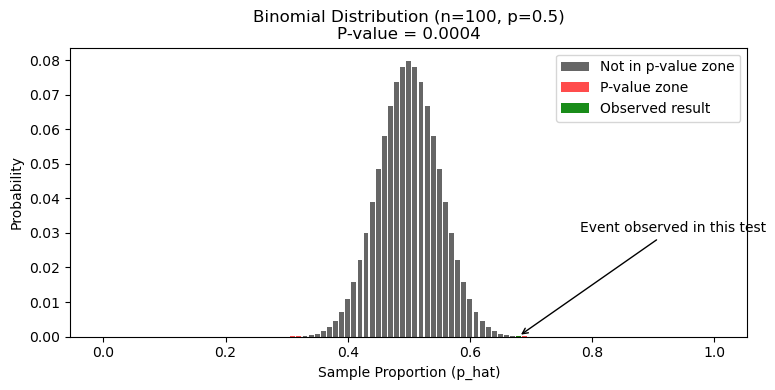


,,Test Details:
,,Observed successes: 68
,,Sample proportion: 0.680
,,Null hypothesis p: 0.5
,,P-value: 0.0004
,,Number of outcomes in p-value zone: 66


In [5]:
#import numpy as np
#import scipy.stats as stats
#import matplotlib.pyplot as plt

# let's flip an unfair(0.7 for event = 1) coin, 100 times
coinFlips = np.random.choice([0,1], size=100, p=[.3,.7])
# the Binomial outcome
S = np.sum(coinFlips)
n = len(coinFlips)

# the Null Hypothesis assumes a fair coin, so its Bernoulli probability
p = 0.5

# create the stats.binomtest instance
test_result = stats.binomtest(S, n, p, alternative='two-sided')
test_pvalue = test_result.pvalue

# plot the Binomial Distribution for S, but change x-axis to sample proportion p-hat
# lay out the x-axis with each outcome of a 100 coin toss, change it to s/n for each p_hat outcome
s = np.arange(0, n + 1)
p_hat = s / n
pobs = S / n

# use stats PMF to calculate the probability of event = s
pmf = stats.binom.pmf(s, n, p)

# Find all outcomes that are as extreme or more extreme than the observed result
# For two-sided test, we need outcomes with probability <= P(observed outcome)
p_obs = stats.binom.pmf(S, n, p)

# Create mask for p-value zone (outcomes with probability <= P(observed outcome))
p_value_zone = pmf <= p_obs

# plot using p_hat on the x-axis
plt.figure(figsize=(8, 4))

# Plot regular bars (not in p-value zone) in blue
regular_bars = ~p_value_zone
plt.bar(p_hat[regular_bars], pmf[regular_bars], width=(0.8/n), 
        color='black', alpha=0.6, label='Not in p-value zone')

# Plot p-value zone bars in red
plt.bar(p_hat[p_value_zone], pmf[p_value_zone], width=(0.8/n), 
        color='red', alpha=0.7, label='P-value zone')

# highlight the observed S with a different color
plt.bar(S/n, p_obs, width=0.8/n, color='green', alpha=0.9, label='Observed result')

# annotate
plt.annotate('Event observed in this test', 
             xytext=((S+10)/n, p_obs+0.03),
             xy=(S/n, p_obs),
             arrowprops={'arrowstyle': '->'},
             fontsize=10)

plt.title(f"Binomial Distribution (n={n}, p={p})\nP-value = {test_pvalue:.4f}")
plt.xlabel("Sample Proportion (p_hat)")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

# Print additional information
print(f"\nTest Details:")
print(f"Observed successes: {S}")
print(f"Sample proportion: {pobs:.3f}")
print(f"Null hypothesis p: {p}")
print(f"P-value: {test_pvalue:.4f}")
print(f"Number of outcomes in p-value zone: {np.sum(p_value_zone)}")

#### Geometric Distribution, $X \sim Geom(p)$
* The geometric distribution is a discrete probability distribution that models the sequence of independent "yes/no" trials until a "success" occurs. It is often described as the "waiting-time" distribution.
* outcome, total number of trials $X = (1,2,3,...)$, including the final success.
* the geometric series,
$$\sum_{i=0}^\infty a\cdot x^i=
\begin{cases}
\frac{a}{1-x}, & |x|<1 \\
\infty, & |x|>1 \\
\infty, & x=1 \\
\text{alternates }a\text{ and }0, & x=-1 \\
\end{cases}$$
* PMF, $$P(X=n)=(1-p)^{n-1} \cdot p$$
* The expected value for the Geometric Distribution is $\hspace{.5cm} \frac {1}{p}$
  * the deduction: 
$$\begin{align}
E[X] 
&= \sum_{n=1}^\infty n\cdot (1-p)^{n-1}p \\
&= p{\sum_{n=1}^\infty n\cdot (1-p)^{n-1}}
\end{align}$$
  * now consider this $\frac {d}{dp} \, (1-p)^n = n(1-p)^{n-1} \cdot (-1)$, apply the sum rule of derivative.
$$p{\sum_{n=1}^\infty n\cdot (1-p)^{n-1}} = p\cdot{\frac{d}{dp}\left(-\sum_{n=1}^\infty (1-p)^n\right)}$$
  * now consider this $\displaystyle -\sum_{n=1}^\infty (1-p)^n = -(\sum_{n=0}^\infty (1-p)^n - (1-p)^0)$
  * apply $\displaystyle \sum_{i=0}^\infty a\cdot x^i = \frac{a}{1-x},  \text{    when   } |x|<1$,  with $x = (1-p)$ and $a=1$
  * $\displaystyle -\sum_{n=1}^\infty (1-p)^n = -(\sum_{n=0}^\infty (1-p)^n - (1-p)^0) = -(\frac{1}{1-(1-p)} - 1) = -(\frac {1}{p} - 1)$
  * now
$$\begin{align}
p \sum_{n=1}^{\infty} n(1-p)^{n-1}
&= p \frac{d}{dp}\left(-\sum_{n=1}^{\infty}(1-p)^n\right) \\
&= p \frac{d}{dp}\left[-\left(\frac{1}{p}-1\right)\right] \\
&= p \cdot \frac{1}{p^2} \\
&= \frac{1}{p}
\end{align}$$

* the Variance, it measures how much the number of trials fluctuates around the mean, $$Var(X) = \frac {1-p}{p^2}$$


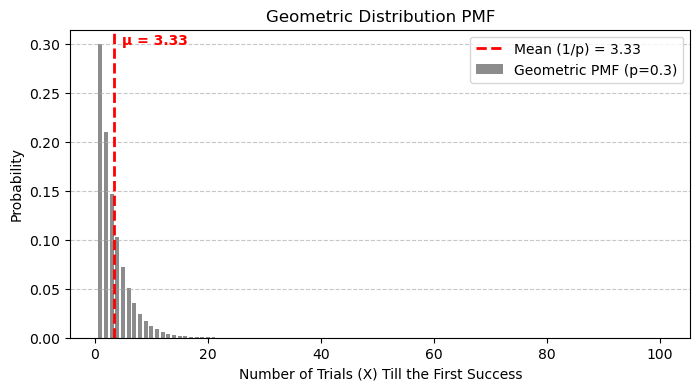

In [16]:
#import numpy as np
#import matplotlib.pyplot as plt

# Given the Bernoulli success probability of p
p = 0.3

# Create 100 random variables X(1, 2, ... 100)
# Note: For p=0.3, the probability drops near zero long before X=100
X = np.arange(1, 101)

# The PMF of geometric distribution: P(X=k) = (1-p)^(k-1) * p
P_geo = (1 - p)**(X - 1) * p

# Plotting
plt.figure(figsize=(8, 4))
# Adjusted width for better visibility
plt.bar(X, P_geo, width=0.7, color='grey', alpha=0.9, label=f'Geometric PMF (p={p})')


# plot the Expected value, as a line
E_X = 1/p
plt.axvline(E_X, color='red', linestyle='--', linewidth=2, label=f'Mean (1/p) = {E_X:.2f}')

# Optional: Add a text label above the line
plt.text(E_X + 1.5, max(P_geo), f'μ = {E_X:.2f}', color='red', fontweight='bold')

plt.title('Geometric Distribution PMF')
plt.xlabel('Number of Trials (X) Till the First Success')
plt.ylabel('Probability')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Memoryless property of the Geometric Distribution: $P(X > m+n \mid X > m) = P(X > n)$
* Intuition
  * After $m$ failures, the process **restarts**
  * Each trial is independent
  * The probability of success is still $p$
  * The system has `no memory` of how long you’ve already waited
  * So the remaining waiting time doesn’t care about the past.
* Set up, $X \sim Geom(p)$
  * $P(X = k) = (1-p)^{k-1} \cdot p, \quad k=1,2,3,\dots$

#### Steps to prove $P(X > m+n \mid X > m) = \frac{P(X > m+n)}{P(X > m)}$
1. Use the definition of __conditional probability__,
    2. $P(A \mid B) = \frac {P(A \cap B)}{P(B)}$
    3. Given $A \subseteq B$, $A \cap B = B \quad$, thus $\quad (X > m+n) \cap (X > m) = (X > m+n)$
    4. Understanding $P(X > m+n \mid X > m) = \frac{P((X > m+n) \cap (X > m))}{P(X > m)} = \frac{P(X > m+n)}{P(X > m)}$
5. Compute the tail probabilities, for a geometric random variable, $P(X > k) = (1-p)^k$
6. So:$P(X > m+n) = (1-p)^{m+n}$, and $P(X > m) = (1-p)^m$
7. Put them back to the conditional probability formula, $\frac{(1-p)^{m+n}}{(1-p)^m} = (1-p)^n$
8. Recognize the result, $(1-p)^n = P(X > n)$


### Jan-31-2026

#### Poisson Distribution, $X \sim Poisson (\lambda)$
* the Poisson distribution is often called the "Law of Rare Events"—it describes the number of successes in a massive number of trials where each individual success is very unlikely.
* Let $X$ be a random variable representing the number of events in a fixed interval.
  * $X \in (0, 1, 2, ..., \infty)$
* The probability mass function (PMF) of $X$ is: $\hspace{1cm}P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$
  * $\lambda$ is the average number of events in the interval (rate parameter)
  * $k$ is the actual number of events
  * $e$ is the base of the natural logarithm ($ e\approx 2.71828$)
* The expected value is $\lambda$
  * deriving from difinition: $E[X] = \displaystyle \sum _{k=0}^\infty k \cdot \frac{\lambda^k \, e^{- \lambda}}{k!}= \begin{cases} 0, & k = 0 \\ \lambda, & k \ne 0 \end{cases}$
  * for the case where $k \ne 0$, we need to figure out a way to put $\displaystyle \sum _{k=1}^\infty k \cdot \frac{\lambda^k \, e^{- \lambda}}{k!}$ into the box of __Taylor series expansion of $e^ \lambda$__
  *  $\displaystyle \sum _{k=1}^\infty k \cdot \frac{\lambda^k \, e^{- \lambda}}{k!} =  \sum _{k=1}^\infty \frac{k}{k!} \cdot \lambda^{k-1} \lambda \, e^{- \lambda} = \lambda e^{- \lambda} \sum _{k=1}^\infty \frac{\lambda ^{k-1}}{(k-1)!}$
  *  let $u = k-1$, we got $E[X] = \lambda e^{- \lambda} \cdot \color{red} \displaystyle \sum _{u=0}^\infty \frac{\lambda ^u}{u!} \color{black} = \lambda e^{- \lambda} \cdot \color{red} e^{\lambda} \color{black} = \lambda$
* For Poisson Distribution, the Variance and Expected value share the same value:  $Var(X) = \lambda$
  * deriving from definition: $Var(X) = E[X^2] - E[X]^2$
  * now, play with the old trick $E[X^2] = E[X^2 - X + X] = E[X(X-1)] + E[X]$
  * go along with the definition: $E[X(X-1)] = \sum_{k=0}^{\infty} k(k-1) \frac{e^{-\lambda} \lambda^k}{k!}$
  * case(0) and case(1) are 0, $E[X(X-1)] = e^{-\lambda} \sum_{k=2}^{\infty} \frac{\lambda^k}{(k-2)!}$
  * same Taylor series expansion, $E[X(X-1)] = \lambda^2 e^{-\lambda} (e^\lambda) = \lambda^2$
  * sum them up, $\text{Var}(X) = E[X(X-1)] + E[X] - E[X]^2 = \lambda^2 + \lambda - \lambda^2 = \lambda$

#### Understanding Poisson with an example
Suppose that **on average, each book has 2 typos**.
* **Each book** represents a fixed interval of space (the text of the book).
* **Typos** are the events being counted.
* The average number of typos per book is **2**, which is the **mean rate** ( $\lambda$ ).
* If we randomly choose a book, the probability of it containg (0, 1, 2, ..., $\infty$) typos can be modeled with Poisson distribution.

#### from Binomial $X \sim Bin(n, p)$ to Poisson $X \sim Poisson(\lambda)$, a modeling assumption justified by a `limit` argument
* Better summary:
  * The Poisson distribution arises as the limit of a Binomial distribution modeling rare events, when the number of trials is large, the success probability is small, and the expected number of events remains fixed.
* Step 1, start with a Binomial Distribution, $X \sim Bin(n, p)$, and its PMF $P(X=k)= \binom{n}{k} p^k(1-p)^{(n-k)}$
  * the event probability $p$ is a known value, and the the number of trials $n$ is fixed.
  * this Binomial has an expected value, or sample mean, $E[X]=np$
* Step 2, let's take this knowledge of Binomial into a rare event study
  * from empirical data, we can estimate the average number of events per interval, denoted by $\lambda$
  * we then use this $\lambda$ to esitmated the expected value from the Binomial mean $np$
  * but, as $n$ is from emperical data, it can be considered to have been tried $\rightarrow \infty$ times
  * and the probability of a rare event can be considered $p \rightarrow 0$
  * And the better way to say:
    * we model the situation by letting the number of trials $n \rightarrow \infty$
    * while the event probability $p \rightarrow 0$
    * such that the mean np=λ remains fixed
* Step 3, let's try to plug $n \rightarrow \infty$, and $p \rightarrow 0$ into Binomial's PMF
  * $\lambda = np \hspace{1cm} \Rightarrow p = \frac{\lambda}{n}$
  * $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k} = \color{red}\binom{n}{k}(\frac{\lambda}{n})^k \color{black}(1-\frac{\lambda}{n})^{n-k}$
  * lets take care of this part first, $\displaystyle \color{red}\binom{n}{k}(\frac{\lambda}{n})^k \color{black}= \frac{n!}{(n-k)! \, k!}=\frac{\lambda^k}{k!} \prod_{i=0}^{k-1} \frac {n-i}{n} = \frac{\lambda^k}{k!} \prod_{i=0}^{k-1}(1 - \frac {i}{n})\overset{n \to \infty}{\longrightarrow} \frac{\lambda^k}{k!}$
  * and this part is tough, $(1-\frac{\lambda}{n})^{n-k} \overset{n \to \infty}{\longrightarrow} e^{-\lambda}$
* Step 4, put them together, (of course in a limit) Poisson PMF $P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$


Lecture example of call center

The Poisson distribution is particularly useful for modeling rare events when the events are independent and the average rate is known. 

For example, a common real-world application of the Poisson distribution is modeling the number of incoming calls at a call center over a given period of time.

**Scenario**: Suppose a call center receives an average of 10 calls per hour. We want to find the probability that exactly 7 calls will be received in the next hour.

**Parameters**:
- Average rate $\lambda$: 10 calls per hour
- Number of events ($k$): 7 calls

**Calculation**:
$P(X = 7) = \frac{10^7 e^{-10}}{7!} \approx \frac{453.9992976}{5040} \approx 0.090$

Therefore, the probability that exactly 7 calls will be received in the next hour is approximately 0.090, or 9\%.

(0.0, 60.0)

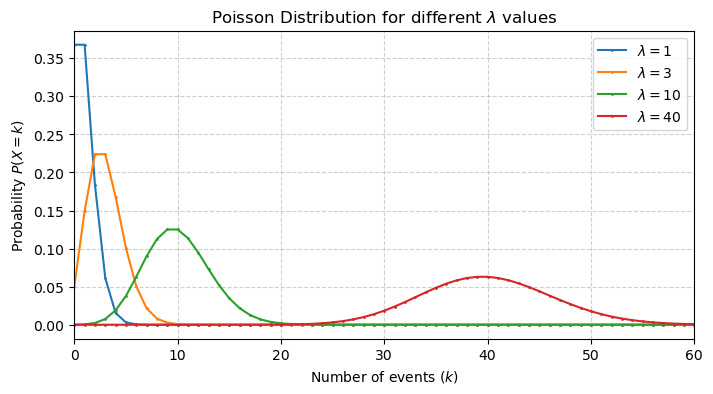

In [12]:
#import numpy as np
#import matplotlib.pyplot as plt
from scipy.stats import poisson

# Define the values of lambda and the range for the x-axis
lambdas = [1, 3, 10, 40]
x = np.arange(0, 61)  # Range from 0 to 50

# Create the plot
plt.figure(figsize=(8, 4))

for lam in lambdas:
    # Calculate the Probability Mass Function (PMF)
    pmf = poisson.pmf(x, lam)
    # Plotting with markers to show discrete points
    plt.plot(x, pmf, marker='o', markersize=1, linestyle='-', label=fr'$\lambda = {lam}$')

plt.title(r'Poisson Distribution for different $\lambda$ values')
plt.xlabel(r'Number of events ($k$)')
plt.ylabel(r'Probability $P(X=k)$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 60)

# Save the result
#plt.savefig('poisson_distributions.png')

### Feb-04-2026

#### Uniform Distribution
* Discrete Uniform Distribution, $X \sim DU(a, b)$, $\hspace{1cm} \text{PMF:} P(X=x)=\frac{1}{n}$
  *  a finite number (6 sides of a fair dice) of outcomes are equally likely to occur
  *  Expected Value, $E[X] = \frac{1}{n} \displaystyle \sum_{i=1}^n x_i $
  *  Variance, feels like the simple difinition, $\sigma ^2 = \frac{1}{n} \displaystyle \sum_{i=1}^n (x_i - E[X])^2$, or the __Computational Form__ $E[X^2] - (E[X])^2$
* Continuous Uniform Distribution, $X \sim U(a, b)$, $\hspace{1cm} \text{PDF:} P(X=x)=\frac{1}{b-a}$
  * `np.random.default_rng().random()` generate a random float from [0, 1)
  * Derving the PDF: $1=\int_a ^b P(X=x)dx=\int_a ^b pdx=p\cdot x |_a^b=p(b-a) \Rightarrow p=\frac{1}{b-a}$
  * Expected Value, $E[X] = \int _a^b x \cdot p dx \xrightarrow[\textstyle p=\frac{1}{b-a}]{} \frac{1}{b-a} \int_a^b xdx = \frac{1}{b-a} \frac{x^2}{2}\big|_a^b =  \color{red}\frac{b+a}{2}$
  * Variance, from the computation form, $Var(X) = E[X^2] - E[X]^2 = \int_a^b (x^2)\cdot pdx - E[X]^2 = \frac{1}{b-a} \cdot \frac{x^3}{3} \big|_a^b - E[X]^2 = \color{red} \frac{1}{12} (b-a)^2$


In [2]:
#example of random generator
#import numpy as np

# initiate the generator
rng = np.random.default_rng()

# floating numbers in the interval [0.0, 1.0)
test1 = rng.random()
test1_5 = rng.random(5)
test1_2x3 = rng.random((2, 3))

# integer within an interval [a, b)
test2 = rng.integers(5, 10)
test2_5 = rng.integers(5, 10, 5)
test2_2x3 = rng.integers(5, 10, (2, 3))

# Generate 5 numbers between 10 and 20
test3 = rng.uniform(low=10.0, high=20.0)
test3_5 = rng.uniform(low=10.0, high=20.0, size=5)
test3_2x3 = rng.uniform(low=10.0, high=20.0, size=(2, 3))

#test3_2x3

#### Simulations: Uniform distributions are the "building blocks" for other probability distributions.
The Uniform Distribution $U(0,1)$ is the mother of all distributions, you can generate random numbers for any distribution in the world.
* If you have a uniform random number generator `np.random.default_rng()`
* For any random variable $X$, the Cumulative Distribution Function (CDF) is denoted as $F(x)$.
  * For a Discrete Distribution: We use the sum of the Probability Mass Function (PMF).$$F(x) = P(X \le x) = \sum_{k \le x} P(X = k)$$
  * For a Continuous Distribution: We use the integral of the Probability Density Function (PDF).$$F(x) = P(X \le x) = \int_{-\infty}^{x} f(t) \, dt$$
* Note, in the lecture, there are some **made-up** notations, they don't exist in proper math.
  * for a discrete distribution, Cumulative Mass Function (CMF) $\hspace{1cm} CMF(X=x) = \sum_{k=a}^x P(X=k)$
  * for a continuous distribution, Cumulative Density Function (CDF): $CDF(X=x) = \int_{a}^x P(X=k)\,dk$



#### Inverse Transform Sampling
demo, using Uniform Distribution random generater to simulate Poisson Distribution
* prepare the random generater, `np.random.default_rng().random()`
  * say, we generated 10 random numbers, all from [0, 1), $y\sim DU[0,1)$
  * they are the values on the y-axis, the sum of all probabilities to certain exact Poisson outcome.
* prepare the Poisson PMF, $\hspace{1cm}P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$
* compute $k!$ might cause overflow, so we need the log-sum trick here
  * for the natural log of e, $ln(k!) = ln(k)+ln(k-1)+...+ln(1) = \displaystyle \sum_{i=1} ^k ln(i) = gamaln(k+1)$
  * so, $k! = exp(\displaystyle \sum_{i=1} ^k ln(i))$, note $k \ne 0$
  * `np.exp(gammaln(x + 1))` need `from scipy.special import gammaln(x+1)`, also `gammaln(x+1)` handles the case when $x=0$
* prepare the Poisson cumulative distribution function map,$\hspace{0.5cm}y_{(X=x)} =\sum_{k \le x} P(X = k)$
  * we know the the sum of all the Poisson probabilities is 1, this matches well witht the range of a $y \sim U(0,1)$
  * so if we starting adding all the probabilities from X=0, we'll have a map with gratings: $$\begin{aligned}y_{(X=0)}&=P(X=0)\\ y_{(X=1)}&=P(X=0)+P(X=1)\\ &\vdots \\ y_{(X=x)}&=\sum _{i=0}^{x}P(X=i)\end{aligned}$$
* Now, come back to that **10 random numbers, all from (0, 1)**
  * in the case where $0 <= \text{random number} < y_{(X=0)}$, we can say it randomly generated a Poisson outcome $X=0$.
  * so as when  $y_{(X=x_i)} <= \text{random number} < y_{(X=x_{i+1})}$, we can say it randomly generated a Poisson outcome $X=x_i$.
  * This is the logic of `np.searchsorted(CMF, U)`


We have generated some outcomes for a Uniform Distribution: 
, [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
,They can be mapped to simulate the outcomes for a Poisson Distribution: 
, [3 2 4 3 0]


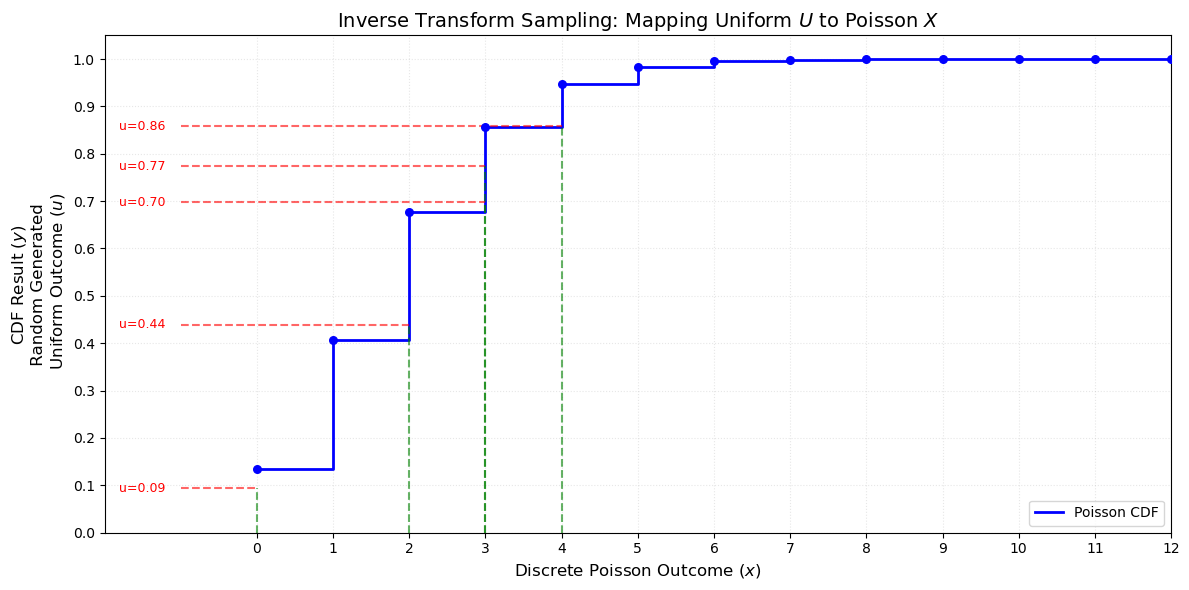

In [3]:
#import numpy as np
import matplotlib.pyplot as plt

#1, Setup Random Generator
rng = np.random.default_rng(seed=42) 

#2, Define Poisson PMF
# use Log-Sum Trick for Factorial: np.sum(np.log(np.arange(1, x+1))) = log(x!)
def poisson_pmf(x, lam=2):
    if x == 0: return np.exp(-lam)        
    return (lam**x * np.exp(-lam)) / np.exp(np.sum(np.log(np.arange(1, x + 1))))

#3, Prepare some Poisson outcomes, np.arange(0, 15)
poisson_outcome = np.arange(0, 15) # Focusing on 0-14 for visual clarity
# calculate the sum, cumulative distribution function, y_value
cdf = np.cumsum([poisson_pmf(i, lam=2) for i in poisson_outcome])

#4, Generate 5 random numbers [0, 1) and map them (The Inversion Method)
# these numbers will be on the y-axis, and follows a Discrete Uniform Distribution
u_values = rng.random(5)

#5, use np.searchsorted, to map the y(cdf) with the y(u_values)
poisson_samples = np.searchsorted(cdf, u_values)

print('We have generated some outcomes for a Uniform Distribution: \n', u_values)
print('They can be mapped to simulate the outcomes for a Poisson Distribution: \n', poisson_samples)

#6, Plotting for a better visualization
plt.figure(figsize=(12, 6))

# Plot the Step Function (The CDF)
plt.step(poisson_outcome, cdf, where='post', color='blue', linewidth=2, label='Poisson CDF')
plt.scatter(poisson_outcome, cdf, color='blue', s=30, zorder=3)

# Add mapping lines for each random number u
for i, (u, x_val) in enumerate(zip(u_values, poisson_samples)):
    # Horizontal line from y-axis to the CDF step
    plt.hlines(y=u, xmin=-1, xmax=x_val, color='red', linestyle='--', alpha=0.6)
    # Vertical line from the CDF step down to the x-axis result
    plt.vlines(x=x_val, ymin=0, ymax=u, color='green', linestyle='--', alpha=0.6)
    # Annotate the random value on the y-axis
    plt.text(-1.2, u, f'u={u:.2f}', color='red', fontsize=9, va='center', ha='right')

# Formatting and Labels
plt.title('Inverse Transform Sampling: Mapping Uniform $U$ to Poisson $X$', fontsize=14)
plt.xlabel('Discrete Poisson Outcome ($x$)', fontsize=12)
plt.ylabel('CDF Result ($y$) \n Random Generated \n Uniform Outcome ($u$)', fontsize=12)
plt.xticks(poisson_outcome)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlim(-2, 12)
plt.ylim(0, 1.05)
plt.grid(True, which='both', linestyle=':', alpha=0.3)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Demo: Using a Uniform Random Generator to Simulate a Normal Distribution $$P(X=x)={\frac {1}{\sqrt {2\pi \sigma ^{2}}}}e^{-{\frac {(x-\mu )^{2}}{2\sigma ^{2}}}}$$
>Inverse Transform Sampling is a general method for random number generation that works for both discrete and continuous distributions when the inverse Cumulative Distribution Function CDF is available.

Key Differences in the Logic: both Discrete and Continuous distribution use a Cumulative Distribution Function (CDF), but
* Discrete CDFs are step functions derived from a PMF, so we generate a random number, $u \sim U(0, 1)$, and locate the interval to find the nearby outcome $X=x_i$.
* Continuous CDFs, we directly compute $X = F^{-1}(u)$.
  * No Manual Summation, there's infinite outcomes for a continuous distribution. Although we often visualize real life data within −3σ to 3σ, the Normal distribution covers range from $-\infty$ to $\infty$. 
  * Extreme values correspond to uniform samples on the y-axis very close to 0 or 1 and occur with probability density $\rightarrow 0$.
  * In code, this means using `np.searchsorted` for discrete distributions and `norm.ppf` (inverse CDF) for continuous ones.
* Understanding `norm.ppf` (Percent Point Function)
  * For a continuous distribution, say, Normal Distribution here. The probability of an exact point $P(X=x)$is 0, we use the cumulative distribution functioin $F(x)=P(X \le x)=\int_{-\infty}^{x} f(t) \, dt$ to calculate the probability.
  * After we generate a random uniform number $u \in [0, 1)$
  * We can use PPF (Percent Point Function) `norm.ppf(u, loc=mu, scale=sigma)` to calculate the inverse: $x=F^{-1}(u)$

In [4]:
#import numpy as np
from scipy.stats import norm

#1, initiate the random generator
rng = np.random.default_rng()

#2, let's create a Standard Normal
mu, sigma = 0, 1
# Continuous distributions use the PDF (Probability Density Function)
# Note: continuous distribution has infinite points between 0 and 1.
def normal_pdf(x, mu=0, sigma=1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

#3,  Generate 10 random numbers [0, 1) to map on the y-axis
u = rng.random(10)

#4, Map Uniform -> Normal (The Inversion Method)
# norm.ppf then calcualte the inverse, from the np.array of u to find the np.array of x
normal_samples = norm.ppf(u, loc=mu, scale=sigma)

#u, normal_samples

### Feb-05-2026

#### Normal Distribution, $X \sim N(\mu, \sigma)$
* Continuous distribution, the range ($-\infty, \infty$), never touch the horizontal axis
* Practical purposes, we mostly visualize the emperical rule, ($-3\sigma, 3\sigma$)
* PDF, probability density function $P(X=x)={\dfrac {1}{\sqrt {2\pi \sigma ^{2}}}} \cdot e^{-{\dfrac {(x-\mu )^{2}}{2\sigma ^{2}}}}$
* Expected value, $E[X]=\mu$
* Variance, $Var(X) = \sigma^2$
* Not sure what's the point of deriving them for now.

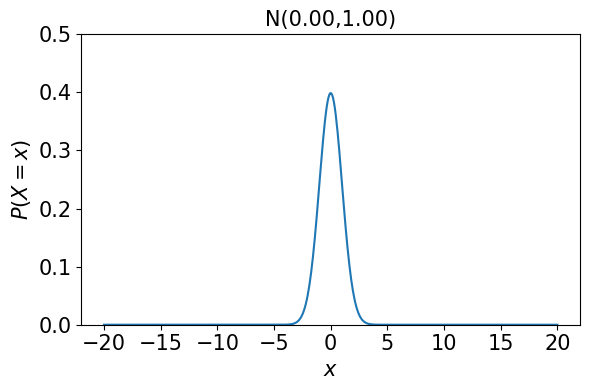

In [4]:
def normal(mu,sigma):
    x = np.linspace(-20,20,500)
    y = np.exp(-(x-mu)**2/(2*sigma**2)) / np.sqrt(2*np.pi*sigma**2)
    return x,y

def plotNormal(mu,sigma):
    x,y = normal(mu,sigma)
    plt.figure(figsize=(6,4))
    plt.plot(x, y)
    #plt.fill_between(x,y,)
#     plt.ylim((0,np.max(y)))
    plt.ylim((0,.5))
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel("$x$",fontsize=15)
    plt.ylabel("$P(X=x)$",fontsize=15)
    plt.title("N(%0.2f,%0.2f)" % (mu,sigma),fontsize=15)
    plt.tight_layout()
    plt.show()

plotNormal(0, 1)

#### Student's $t$ Distribution, $X\sim t(\nu)$ 
* Family of Distributions: A continuous probability distribution characterized by the degrees of freedom $\nu$.
* PDF Formula:$${}f(t)=\frac{\Gamma \left(\frac{\nu +1}{2}\right)}{\sqrt{\nu \pi }\,\Gamma \left(\frac{\nu }{2}\right)}\left(1+\frac{t^{2}}{\nu }\right)^{-\frac{\nu +1}{2}}$$
* Gamma Function ($\Gamma$):
  * Generalizes the factorial such that $\Gamma (n)=(n-1)!$, given $(n-1) \in N$
  * In code, stay as much as possible with `scipy.special.gammaln` to prevent overflow. Only to `return np.exp()` in the end.
* The student's t-distribution is used when the population standard deviation ($\sigma$) is unknown, and must be estimated with the sample standard deviation ($s$).
  * The missing $\sigma$, not the small sample size $n$, is the key reason.
  * And estimating $\sigma$ with $s$ indtroduces extra uncertainty. This is why student's t-distribution is wider (fat tail).
* Degrees of Freedom ($\nu$): Typically calculated as $\nu =n-1$ in basic t-tests, where $n$ is the sample size.
* The \(t\) variable: Represents the t-score, calculated as $t=\dfrac{\bar{x}-\mu }{s/\sqrt{n}}$, which measures how many standard errors the sample mean is from the hypothesized population mean.
  * Note that `sample` notation, sample size $n$, sample mean $\bar x$, sample standard deviation $s$, and standard error of the sample mean SEM.
  * Also, seeing SEM doesn't necessarily mean CLT. Student's t-distribution normally have a small sample size ($n\le 30$), not qualified for CLT.
  * Sample used in student's t-distribution is **assumed following Normal**.
  * And the $\mu |H_0$


#### (better phrased) Understanding Student's t-distribution, t_test vs z-test
* The Student’s t-distribution is used when **making inferences about a population mean** (we assume a $\mu |H_0$) with an unknown population standard deviation.
* When the population standard deviation ( $\sigma$ ) is known, use a z-test when
  * just one single observation, (sample size $n=1$, no way for $s$, no meaningful $\bar x$)
  * or when the sample size is sufficiently large so that the **sampling distribution of the mean** (CLT) is approximately normal. (actually, this case both t and z are the same, that's why there's no z-test tool in `scipy.stats`)
* However, when ( $\sigma$ ) is unknown and the sample size is small, the additional uncertainty from estimating ( $\sigma$ ) with the sample standard deviation ( $s$ ) leads to a t-distribution for the standardized sample mean.
* In small samples, the validity of the t-test relies on the assumption that **the underlying population is normally distributed**, rather than on the Central Limit Theorem. As the sample size increases, the t-distribution approaches the normal distribution. And the t-test and z-test are similiar.
* When sample size is small, σ is unknown, and the population is **not normal**, a t-test can give misleading results.

#### Understanding the Gamma Function $\Gamma(x)$
* The Gamma function grows extremely fast, it's commonly recommended to use the Log-Gamma Function. `Gamma(x) = exp(gammaln(x))`
```python
from scipy.special import gammaln
val = np.exp(gammaln(5))
```
* When calculating the coefficient for the Student's t-distribution:$$C=\frac{\Gamma \left(\frac{\nu +1}{2}\right)}{\sqrt{\nu \pi }\,\Gamma \left(\frac{\nu }{2}\right)}$$
* Instead of calculating the numerator and denominator separately (which might both be huge), you should calculate the log-coefficient first:$$\ln (C)=\text{gammaln}\left(\frac{\nu +1}{2}\right)-\left[\frac{1}{2}\ln (\nu \pi )+\text{gammaln}\left(\frac{\nu }{2}\right)\right]$$

#### (Limit) The t-distribution is a generalization of the Normal Distribution. 
* We can see this by examining $\nu\rightarrow\infty$

$$
\begin{align}
\lim_{\nu\rightarrow\infty}f(t) 
    &= \lim_{\nu\rightarrow\infty}\frac{\color{red}{\Gamma\left(\frac{\nu + 1}{2}\right)/\Gamma\left(\frac{\nu}{2}\right)}}{\sqrt{\nu \pi} } \left(\color{blue}{1 + \frac{t^2}{\nu}}\right)^{-\frac{\nu + 1}{2}}
= \lim_{\nu\rightarrow\infty}\frac{\color{red}{\sqrt{\nu}/\sqrt{2}}}{\sqrt{\nu}\cdot \sqrt{\pi} } \left(\color{blue}{1 + \frac{t^2}{\nu}}\right)^{-\frac{\nu + 1}{2}}
% \hspace{.5cm}
&\text{using }\color{red}{\Gamma(z) = \int_0^\infty t^{z-1}e^{-t}\,dt}
\\\\
&= \lim_{\nu\rightarrow\infty}\frac{1}{\sqrt{2 \pi} } \left(\color{blue}{e^{t^2/\nu}}\right)^{-\frac{\nu + 1}{2}}
= \lim_{\nu\rightarrow\infty}\frac{1}{\sqrt{2 \pi} } e^{-t^2(\nu+1)/(2\nu)}
% \hspace{.5cm}
&\text{using }\color{blue}{1+x \approx e^x}\text{ for }|x|\approx0
\\\\
&= \frac{1}{\sqrt{2 \pi} } e^{-t^2/2}
\end{align}
$$

which is the standard Normal Distribution with $\mu=0,\sigma=1$

#### Properties of the t-Distribution:
* The t-distribution is symmetric and bell-shaped, similar to the standard normal distribution, but has heavier tails.
* As the degrees of freedom increase, the t-distribution approaches the standard normal distribution.


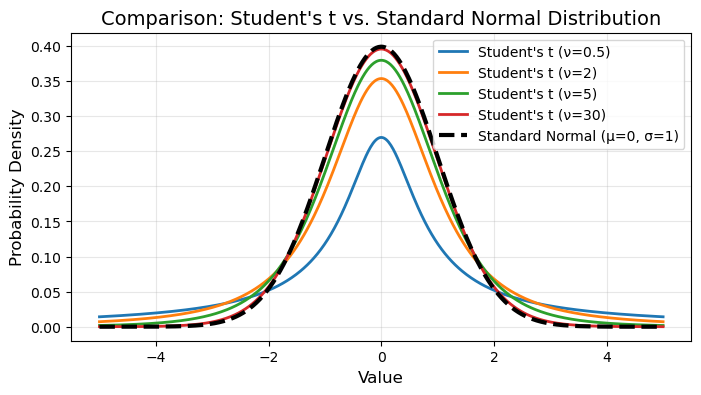

In [13]:
#import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# 1. Setup the x-axis (range of values)
x = np.linspace(-5, 5, 500)

# 2. Define the degrees of freedom to visualize
dfs = [0.5, 2, 5, 30]

plt.figure(figsize=(8, 4))

# 3. Plot Student's t-distributions for various nu
for df in dfs:
    plt.plot(x, t.pdf(x, df), label=f"Student's t (ν={df})", lw=2)

# 4. Plot the Standard Normal Distribution for comparison
plt.plot(x, norm.pdf(x), label="Standard Normal (μ=0, σ=1)", 
         color='black', linestyle='--', lw=3)

# Formatting the plot
plt.title("Comparison: Student's t vs. Standard Normal Distribution", fontsize=14)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### What's the expected value of the t-distribution?
Student's t-distribution is based on the standard normal. Seen from the plot above, we know
* $E[T] = \mu = 0$
* Here's the math
$$E[T] = \int_{-\infty}^\infty t\cdot P(T=t)\,dt
= \frac{\Gamma\left(\frac{\nu + 1}{2}\right)}{\sqrt{\nu \pi} \, \Gamma\left(\frac{\nu}{2}\right)}\int_{-\infty}^\infty t\cdot \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu + 1}{2}}\, dt$$
* Now, let $u=t^2$ then $du=2t\,dt$, giving us
$$\frac{\Gamma\left(\frac{\nu + 1}{2}\right)}{2\sqrt{\nu \pi} \, \Gamma\left(\frac{\nu}{2}\right)}\int_{\infty}^\infty\left(1 + \frac{u}{\nu}\right)^{-\frac{\nu + 1}{2}}\, du$$
* Note that the limits of the integral need to change as we change variables from $t$ to $u$.
* With the new limits of integration, it's clear that the answer is $E[T]=0$ because, if $F(u)$ is the antiderivative to the integral, then the solution accounting for integration limits will be $F(\infty)-F(\infty)$

#### The variance of the Student's t-distribution is directly determined by its degrees of freedom ($\nu$).
* The Formula for a standard Student's t-distribution, the variance is:$\hspace{1cm}Var(X)=\dfrac{\nu }{\nu -2}$
  * $\nu =1$ ($n=2$): Even the Mean is undefined. The outliers are so strong they can pull the "center" of the data anywhere.
  * $\nu =2$ ($n=3$): The Mean is 0 ($E[T]=0$ by definition), but the Variance is infinite. We know where the center is, but we can't bound the spread.
  * $\nu >2$ ($n>3$): We finally have enough "weight" in the center of the data to keep the variance finite.
  * When we have very little data (like a sample size of 3, where $\nu =2$), the probability of seeing extreme outliers is so high that the mathematical 'spread' of the distribution doesn't settle down to a single finite number. It represents maximum uncertainty.
* Built upon the standard normal, the $\frac{\nu}{\nu - 2} > 1$, as $\nu \rightarrow \infty$, the variance $\frac{\nu}{\nu - 2} \rightarrow 1$
* In general, the student's t-distribution has a fatter tails compared to a standard normal, as the probability density for edge cases are higher. This is due the lack of data, and increased uncertainty.


#### (in my words) T-score, Z-score, Hypothesis population mean
Z and t differ because of how spread ($\sigma$ vs $s$) is handled — not because of the mean $\mu$.
The t-score exists only for the sample mean, not for single observation.
* In a Z-score for an individual, you are usually comparing a data point to a known population (e.g., "How tall is this person compared to the national average?").
* In a T-test, you are usually asking: "Is the difference between my sample mean $\bar{x}$ and the hypothesized $\mu$ just due to random chance, or is it statistically significant?"
* In a T-test, we treat the sample mean ($\bar{x}$) as our single data point of interest and compare it to the hypothesized population mean ($\mu$). This is like the CLT bridge.
* Z-scores can be used for both individuals ($x$) and sample means ($\bar{x}$) as long as you know the population standard deviation ($\sigma$). 
* T-scores are almost exclusively used for sample means ($\bar{x}$) because if you only have one individual ($n=1$), you cannot mathematically calculate a sample standard deviation ($s$), meaning you can't build the 'CLT bridge' at all.

Z-score, with known population mean $\mu$ and standard deviation $\sigma$, as a question might stated out.
* single observation, $z=\dfrac{x - \mu}{\sigma}$
* $n$ groups of samples, with sample mean $\bar x$, $z=\dfrac{\bar x - \mu}{\sigma / \sqrt n}$

T-score, when you have only observed a limited number of samples, and don't have the population standard deviation $\sigma$, you approximated $\sigma$ with sample standard deviation $s$.
* The t-distribution is derived for the sample mean, there's no single observation. $\nu = n-1 =0$ will break student's t-distribution's PDF.
* Sample mean of size $n$, $t=\dfrac{\bar x - \mu}{s / \sqrt n}$
* both cases, the $\mu$ is hypothesized, $\mu |H_0$

#### Common `scipy.stats.norm` tools for z-test, t-tests, and binomial test
* In all tests, p-value < 0.05 means we can reject the $H_0$
* z-test, with known $\sigma$
```python
#straight calculation
from scipy import stats
#x can be a single observation, or a sample mean
#mu0 is always assumed/hypothesized

#z-statistic
z = (x - mu0) / (sigma / np.sqrt(n))

#p-value
#Two-tailed test: Use 
p_val = 2 * stats.norm.sf(abs(z))

#One-tailed (Upper): Use 
p_val = stats.norm.sf(z)

#One-tailed (Lower): Use 
p_val = stats.norm.cdf(z)
```
* t-test
```python
#1-sample, Test if sample mean equals μ₀|H.
t_stat, p_val = stats.ttest_1samp(data, popmean=mu0)

#Independent two-sample t-test
#Testing if Group A is specifically GREATER than Group B
t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False, alternative='greater')

#Paired t-test: Before vs after measurements of the same sample
#'less' if you want to test if 'before' < 'after'
t_stat, p_val = stats.ttest_rel(before, after, alternative='less')

#A paired t-test is mathematically identical to a 1-sample t-test on the differences
#a positive t-stat means after is higher
differences = after - before
t_stat, p_val = stats.ttest_1samp(differences, popmean=0, alternative='greater')

```
* binomial test
  * The p-value tells you: "If the true probability really is $p$, how likely is it that I'd see $k$ successes just by luck?"
```python
#binomtest returns an object
res = stats.binomtest(k, n, p=0.5, alternative='two-sided')
#P-value
p_val = res.pvalue

#P-value < 0.05: The result is surprising! 
#Your observed k is significantly different from what was expected. 
#The coin is likely biased (or your process is "broken").
```

Lecture Question Demo, Real-World Application: Comparing Means

Motivating Example: Suppose you are a quality control manager at a factory that produces light bulbs. You are interested in determining whether a new manufacturing process produces bulbs with a different average lifespan compared to the current process. You have a small sample of data:
* Current process: sample mean lifespan = 1000 hours, standard deviation = 30 hours, sample size = 10.
* New process: sample mean lifespan = 1020 hours, standard deviation = 25 hours, sample size = 10.

Let's put this question into a t-test box
* You want to test whether the new process significantly improves the product's lifespan. Given the small sample size and unknown population standard deviation, the t-distribution is appropriate.
* $\mu |H_0$: Current process: sample mean lifespan = 1000 hours
* $\bar x$: New process: sample mean lifespan = 1020 hours
* $s$: standard deviation = 25 hours
* $n$: sample size = 10
* the code below gives t-stat = 2.53

How to compare to the critical value, $t^*$
* With a sample size of $n = 10$ the degrees of freedom $\nu = n - 1 = 9$
* Using a t-table or calculator, find the critical value for a one-tailed test with $\nu = 9$ degrees of freedom at a significance level $\alpha = 0.05$. The critical t-value is approximately $1.833$
* Since $2.53 > 1.833$ we reject the null hypothesis. This suggests that the new process significantly increases the lifespan of the bulbs.
* This can also be confirmed from the p-val in the code below, $p=0.016 \lt \alpha=0.05$, we can reject the Null Hypothesis $H_0: \text{they are the same}$.


In [6]:
#Let's put this question above into 'Independent two-sample t-test' box
from scipy import stats
#1-sample, Test if sample mean equals μ₀|H.

mu0 = 1000
sample_mean = 1020
sample_std = 25
sample_size = 10

# this requires newer version of SciPy
'''
t_stat, p_val = stats.ttest_1samp_from_stats(mean = sample_mean,
                                             std = sample_std, 
                                             nobs = sample_size, 
                                             popmean = mu0)
'''

# or, create your own raw data from the statistics
'''
oldProcess_data = np.random.normal(1000, 30, 10)
newProcess_data = np.random.normal(1020, 25, 10)
scipy.stats.ttest_ind(newProcess_data,oldProcess_data,alternative="greater")
'''

# or, do it with manual calculation instead, if raw data is not available for 
#t_stat, p_val = stats.ttest_1samp(data, popmean=mu0)
t_stat = (sample_mean - mu0) / (sample_std / np.sqrt(sample_size))

df = sample_size - 1
#One-Tailed Test (Right-tailed) - Testing if Mean > μ₀
p_val = stats.t.sf(t_stat, df)

t_stat, p_val

(np.float64(2.5298221281347035), np.float64(0.016122390480228357))

### Feb-08-2026

#### Hypothesis Testing
* Hypothesis testing is a critical aspect of statistical analysis, allowing us to make decisions based on data.
* It involves formulating hypotheses, conducting tests, and interpreting the results.
* The process provides a framework for making inferences about populations based on sample data.


First, you define your hypotheses. As part of this, you need to pick which probability distribution most closely describes the process that generates the data:
* **Null Hypothesis ($H_0$)**: A statement that there is no effect or no difference. It serves as the default assumption.
* **Alternative Hypothesis ($H_1$)**: A statement that there is an effect or a difference. It is what you aim to support.

Second, you analyze your data and test if the resulting data (e.g., the sample mean) is suprising given the null hypothesis:
* A test statistic is a standardized value calculated from sample data. It is used to decide whether to reject the null hypothesis.
- Examples: 
  - $t$-statistic for t-tests.
  - $z$-statistic for z-tests.


Third, you define the threshold for "surprising." That is, how rare should the empirical outcome be given the null hypothesis for us to conclude that the null hypothesis is <u>wrong</u>:
* The probability of rejecting the null hypothesis when it is actually true (Type I error)
* Common choices: $\alpha = 0.05, \alpha = 0.01$
* The **p-value** is the probability of obtaining a test statistic at least as extreme as the one observed, given the null hypothesis.
* If the p-value$<\alpha,$ reject the null hypothesis.


#### Lecture Example-1 of carBatteryData (t-test)
* A company claims that their battery life is 100 hours on average. You collect a sample of 10 batteries. Batteries in your sample have an average lifespan of only 98 (`np.mean(carBatteryData)`) hours.
* Question: Is this significantly lower than the lifespan reported by the company?

#### Steps of putting this question into the 1-sample t-test box, for Hypothesis Testing
* step 1, set up the Null Hypothesis $H_0$: car batteries indeed have an average lifespan of 100 hours
* step 2, set up the alternative Hypothesis $H_1$: `np.mean(carBatteryData)` $\ne 100$
  * the lecture example chooses to be less than 100.
  * making it a 1-sided t-test.
* step 3, decide the common $\alpha = 0.5$
* step 4, using `scipy.stats.ttest_1samp(carBatteryData,100,alternative="less")`
  * shown in the code cell below
* step 5, test result `p_val` $\lt \alpha = 0.5$, so we reject the Null Hypothesis.

In [14]:
#import scipy.stats as stats

#1, initiate the random generator
rng = np.random.default_rng(seed=1234)

#2, let's generate 10 car batter life data(np array) for a normal distribution
mu = 98
std = 2
size = 10
carBatteryData = rng.normal(mu,std,size)

#carBatteryData, np.mean(carBatteryData), np.std(carBatteryData), len(carBatteryData)

#3, this is taken as a 1-sample t-test, lecture choose 1-side, less
t_stat, p_val= stats.ttest_1samp(carBatteryData,100,alternative='less')
p_val

np.float64(0.04211371673776807)

#### Lecture Example-2 of callCenterData (Poisson)
* A call center receives an average of 2 calls per minute. In one minute, the center receives 5 calls. Has the average call rate increased?


#### Steps of putting this question into the Poisson box, for Hypothesis Testing
* step 1, the Null Hypothesis ($H_0$) is that the average call rate is 2 calls per minute.
* step 2, the Alternative Hypothesis ($H_1$) is that the average call rate is not 2 calls per minute.
* step 3, set the threshold $\alpha=0.05$
* step 4, manual calculation of the p-value of this Poisson Distribution
  * In a Poisson model with null rate $\lambda = 2 | H_0$, the p-value is the probability of observing 5 or more calls per minute under the null hypothesis, $P(X \geq 5) = 1 - P(X < 5) = 1 - \sum_0^4P(X=k)$
  * $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$, and $\lambda = 2$
  * $P(X \geq 5) = 1-(P(X < 5) \approx 0.1353 + 0.2707 + 0.2707 + 0.1804 + 0.0902) = 1-0.9473 = 0.0527$
* The p-value of $0.0525 \not<0.05,$ so we fail to reject the Null Hypothesis.
  * p_val can also be calculated with the suvival fuction `stats.poisson.sf(x-1, mu=lambda0)`


In [15]:
#1, set up the lambda with the Null Hypothesis
lambda0 = 2

#2, set up the sample data for Hypothesis Testing
k = 5

#3, calculate the p_value with the Poisson Survival Function
p_value = stats.poisson.sf(k-1, mu=lambda0)

#4, compare with the common alpha=0.05
p_value > 0.05

np.True_

### Feb-11-2026

#### Module 8: Advanced Regression Analysis
This module covers essential concepts in regression analysis, from basics like covariance and correlation to advanced topics such as multicollinearity, interaction effects, Lasso regression, and logistic regression. It provides tools for interpreting, diagnosing, and improving regression models.

Learning Objectives: Perform regression analysis, focusing on ordinary least squares, logistic, and Poisson regressions, which serve as foundational examples of machine learning algorithms.
* M8 Lecture 1: Covariance and Correlation
* M8 Lecture 2: Correlation Vs. Causation
* M8 Lecture 3: Refresher on OLS Regression
* M8 Lecture 4: Interpreting Regression Coefficients
* M8 Lecture 5: Interaction–Is the OLS Regression Model Correct?
* M8 Lecture 6: Multicollinearity in OLS Regression
* M8 Lecture 7: Coefficient of Determination–Measuring Model Performance
* M8 Lecture 8: Lasso Regression
* M8 Lecture 9: Logistic Regression


#### Covariance and Correlation
Let $X$ and $Y$ are two variables.
* $\text{Covariance:} \hspace{1cm}cov(X, Y) = E\big[\, \color{red}(X-E[X]) \cdot \color{blue}(Y-E[Y])\color{black}\, \big] = E[XY] - E[X] \cdot E[Y]$
  * Covariance is unbounded
  * Covariance has the unit of $unit(X) \cdot unit(Y)$, and we know standard deviation $\sigma$ has the same unit of variable $X$. We can therefore normalize the Covariance to:
* $\text{Pearson Correlation Coefficient:} \hspace{1cm} \rho_{XY} = \dfrac{cov(X,Y)}{\sigma_X \cdot \sigma_Y} = \dfrac{cov(X,Y)}{\sqrt{Var(X) \cdot Var(Y)}}$
  * $\rho_{XY} \in [-1, 1]$
  * $\pm 1$ means perfect postive/negative covariance, and $0$ means no covariance.

some notes on math
* $E[cX] = \int c \cdot xf(x)dx = c\cdot \int xf(x)dx = cE[X]$
* $\mathrm{Var}(cX) = E[(cX -E[cX])^2]= E[c^2 \cdot (X -E[X])^2] = c^2 \mathrm{Var}(X)$
* Deriving Covariance:

$\begin{align} \hspace{0.7cm}E\big[(X-E[X]) \cdot (Y-E[Y]) \big] 
&= E[XY - XE[Y] - YE[X] + E[X]E[Y]] \\
&= E[XY]-E[XE[Y]] - E[YE[X]] + E[X]E[Y] && \text{note E[X] is a constant}\\
&= E[XY]-E[X]E[Y] - E[Y]E[X] + E[X]E[Y] \\
&= E[XY]-E[X]E[Y]
\end{align}$

* another form for the $\rho_{XY}$, sample statistics $r$
  * note, for sample (not population): $s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}$, $\hspace{0.5cm}cov(X,Y) = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{n-1}$
  * $r_{XY} = \frac{\displaystyle\sum_{i=1}^n \left(x_i-\langle x\rangle\right)\left(y_i-\langle y\rangle\right)}{\sqrt{ \displaystyle\sum_{i=1}^n \left(x_i-\langle x\rangle\right)^2\cdot \sum_{i=1}^n \left(y_i-\langle y\rangle\right)^2 }}  \quad \text{cancel out sample(or population) size}$
  

#### Understanding `r, pvalue = scipy.stats.pearsonr(x,y)`; Interpreting Correlation
* $\rho_{XY}$ is the Pearson's correlation coefficient, on the population.
  * With data from sample, say extreme case of just two data points. It would give a false correlation of $\pm1$.
  * Thus, we use $r_{XY}$ to represent sample correlation.
  * With small samples, $r$ has high sampling variability and may substantially deviate from $\rho$.
* In statistics, a correlation coefficient (like Pearson's $r$) tells you what the relationship looks like, based on the limited sample data.
* We also need the p-value, $\text{p-value} = P(\text{observing a statistic at least as extreme as r} ∣H_0)$
  * The p-value tests the Null Hypothesis $H_0:$ `The true correlation in the underlying population is actually 0`
  * This Hypothesis testing lives under this student's t-distribution: test statistic $t= \frac{r_{XY}}{s_{(r_{XY}})} = r_{XY}\sqrt{\frac{n-2}{1-r_{XY}^2}}$, and $t \sim t_{n-2}$
  * And the p-value is $P(|T_{n-2}| \ge |t_{obs}|)$


From lecture, example with Linear Relation: $ Y=m\cdot X+b$ for some constants $m,b$
* variance of $Y$, $\hspace{0.5cm} Var(Y) = Var(mX+b) = m^2 \cdot Var(X)$
* covariance of $X,Y$, $\hspace{0.5cm} cov(X,Y) = m \cdot Var(X)$, derived as the following

$\hspace{4.5cm} \begin{align}cov(X,Y) &= E[XY]-E[X]E[Y] \\
&= E[mX^2+bX]-E[X]E[mX+b] \\
&= m\cdot E[X^2]+b\cdot E[X]-E[X]\left(m\cdot E[X]+b\right) \\
&= m\cdot E[X^2]\color{red}{+b\cdot E[X]}-\color{black}m\cdot E[X]^2\color{red}{-b\cdot E[X]} \\
&= m\left(E[X^2]-E[X]^2\right) \\
&={m\cdot Var(X)}\end{align}$

* Thus, Pearson's correlation coefficient for linearly related $X, Y$ is $\rho_{XY} 
= \frac{\color{orange}{cov(X,Y)}}{\sigma_X\color{blue}{\sigma_Y}} 
= \frac{\color{orange}{cov(X,Y)}}{\sqrt{Var(X)}\color{blue}{\sqrt{Var(Y)}}} 
= \frac{\color{orange}{m\cdot Var(X)}}{\sqrt{Var(X)}\cdot\color{blue}{m\cdot\sqrt{Var(X)}}} = 1$

understanding `y = r * corr_x + np.sqrt(1 - r**2) * corr_noise`
* it implements $Y = rX + \sqrt{1-r^2}\cdot \varepsilon$
* with $cov(X,Y) = r$, and $r_{XY} = r$

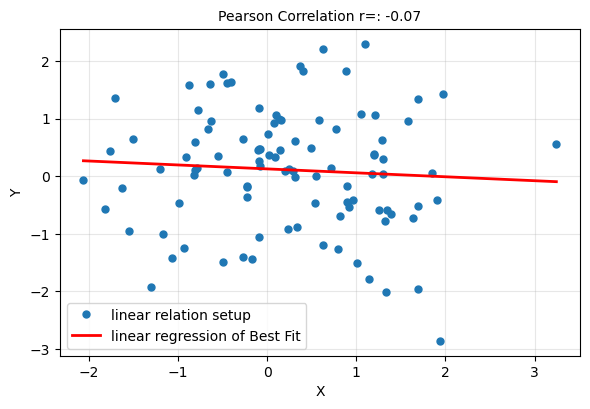

In [9]:
from scipy.stats import pearsonr, linregress
rng = np.random.default_rng()

#1, generate some random noise, and the X-axis
corr_noise = rng.normal(0, 1, 100)
corr_x = rng.normal(0, 1, 100)

#2, generates a random float between -1.0 and 1.0
r = rng.uniform(-1, 1)

#3, set up the linear relaiton
y = r * corr_x + np.sqrt(1 - r**2) * corr_noise

#4 use the linregress function to compute slope and intercept from the above linear relation
slope, intercept, r, pvalue, stderr = linregress(corr_x, y)


#5, prepare the x-axis based on min and max from setup linear relation
line_x = np.linspace(min(corr_x), max(corr_x), 100)

#6, prepare the y-axis from the linear regression result
line_y = slope * line_x + intercept


#7, plot the original linear relation setup and the linear regression
plt.figure(figsize=(6, 4))
plt.plot(corr_x, y, 'o', markersize=5, label="linear relation setup")
plt.plot(line_x, line_y, 'r', alpha=1, lw=2, label="linear regression of Best Fit")
plt.xlabel('X',fontsize=10)
plt.ylabel('Y',fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.tight_layout()
plt.title(f'Pearson Correlation r=: {r:.2f}',fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

#### Correlation ≠ Causation
* Causation implies that one event is the result of the occurrence of another event. This is a cause-and-effect relationship.
  * Co-variation between cause and outcome may not be perfect.
* In general, correlation between variables $X$ and $Y$ does not mean that $X$ causes $Y$.
* Many of these correlations are **spurious**, meaning that they occured by chance.
  * <https://tylervigen.com/spurious-correlations>
* That is, spurious correlations do not mean $X$ causes $Y$ and may occur even without a third variable (**confounder**) causing both.
  * Lecture example: As temperature increases, more people buy ice cream and more people want to go swimming, which creates more opportunities for drowning. This would lead to a postive correlation between icecream sales and drowing.


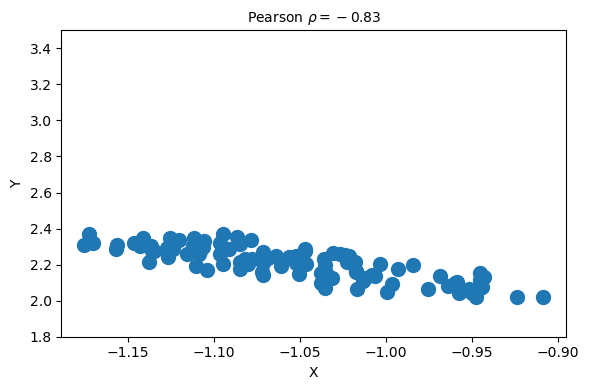

In [18]:
# code example of confounder Z to X and Y
from scipy.stats import pearsonr, linregress

# let set an example with 100 data points, with a random number Z to be used as confounder
n = 100
rng = np.random.default_rng()
Z = rng.random(n)

# parameter for tuning strength of random noise, stronger noise reduces cov(X,Y)
e = .1 

# set up X and Y from Z, with some random noise e
Y = .3*Z+2 + e * rng.random(n)
X = -.2*Z-1 + e * rng.random(n)

# plot to check the correlation of X and Y
plt.figure(figsize=(6, 4))
plt.plot(X,Y,'o',markersize=10)
plt.ylim((1.8,3.5))
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("X",fontsize=10)
plt.ylabel("Y",fontsize=10)
R,p = pearsonr(X,Y)
plt.title("Pearson $\\rho=%0.2f$" % R,fontsize=10)
plt.tight_layout()

#### Linear Regression Model and OLS Solution
* the Linear Regression Model
  * it assumes $\vec y =  \beta_0 + \beta_1 \cdot X_1 + \beta_2 \cdot X_2 + \dots + \varepsilon$
  * in Matrix form, $\vec y =  X \vec \beta + \varepsilon$
* OLS is a solution to esitimate $\hat \beta \approx (X^TX)^{-1}X^T \cdot \vec y$
  * OLS chooses $\hat \beta$ to minimize the Residual Sum of Squares (unexplained variation): $\displaystyle \sum_{i=1}^n(y_i - \hat y)^2$
* note that R-squared (coefficient of determination) $R^2 = \dfrac{\text{explained}}{\text{total}}$
  * (unexplained variation) $\sum(y_i - \hat{y}_i)^2$, Residual Sum of Squares
  * (explained variation) $\sum(\hat{y}_i - \bar{y})^2$ 
  * (total variation in Y) $\sum(y_i - \bar{y})^2$ 
* and note these, Linear regression without OLS; (same linear model, different estimators)
  * Ridge regression
  * Lasso
  * Elastic Net
* and note even more, other least-squares variants; (same linear model, different estimators)
  * Weighted Least Squares (WLS)
  * Generalized Least Squares (GLS)
  * Nonlinear Least Squares (NLS)

#### Measuring OLS estimated Coefficients $\hat \beta$
still with that Linear Regression Model: $\vec y =  \beta_0 + \beta_1 \cdot X_1 + \beta_2 \cdot X_2 + \dots + \varepsilon$
* The coefficents $\beta_i = \dfrac{E[\vec{x_i}\vec{y}]-E[\vec{x_i}]E[\vec{y}]}{E[\vec{x_i}^2]-E[\vec{x_i}]^2} = \dfrac{cov(\vec{x_i}, \vec{y})}{Var(\vec{x_i})}$, while holding other variables as constant
* remember cmpinf2100, we need to know which $\beta_i$'s confidence interval includes 0.
  * Coefficients that are nonzero have a nontrivial correlation with $y$
* We can go with this Hypothesis Testing
  * Null Hypothesis ($H_0$): The estimated coefficient $\hat{\beta}_i$ is not significantly different from zero (i.e., $|\hat{\beta}_i|\approx0$), implying no effect.
  * Alternative Hypothesis ($H_1$): The estimated coefficient $\hat{\beta_i}$ is significantly different from zero (i.e., $|\hat{\beta}_i|>0$), implying an effect.
  * the t-statistic: $t_i = \dfrac{\hat \beta_i - (\beta_i|H_0)}{SE(\hat \beta_i)}$, note $\beta_i|H_0 = 0$
* We'll talk about the **standard error of a coefficient estimate**, $SE(\hat \beta_i)$ separately
  * $\hat \varepsilon$ Residual: $\hspace{1cm} \hat{\varepsilon}$ part of the model, $\hat{\varepsilon} = \vec{y} - M\hat{\beta} = \vec{y}-\hat{y}$
  * $\hat \varepsilon$ Variance, also mentioned in the cmpinf2100 as, the mean squared error (MSE): $\dfrac{\sum (y_i - \hat y_i)^2}{n-k-1} = \dfrac{\sum (\hat \varepsilon_i) ^2}{n - k - 1} = \dfrac{\hat{\varepsilon}^T \cdot \hat{\varepsilon}}{n - k - 1}$
    * where $n$ is the number of observations (i.e., rows in $M$) and $k$ is the number of variables (i.e., columns in $M$), and note that $1$ due to intercept.
  * $\hat \beta$ Variance-Covariance Matrix: $Var(\hat \beta) = MES \cdot (M^T\cdot M)^{-1}$
    * This is a square matrix, the $\beta$.corr() equivalent
    * $Var(\hat{\beta}) = \begin{bmatrix} 
\text{Var}(\hat{\beta}_0) & \text{Cov}(\hat{\beta}_0, \hat{\beta}_1) & \text{Cov}(\hat{\beta}_0, \hat{\beta}_2) \\
\text{Cov}(\hat{\beta}_1, \hat{\beta}_0) & \text{Var}(\hat{\beta}_1) & \text{Cov}(\hat{\beta}_1, \hat{\beta}_2) \\
\text{Cov}(\hat{\beta}_2, \hat{\beta}_0) & \text{Cov}(\hat{\beta}_2, \hat{\beta}_1) & \text{Var}(\hat{\beta}_2)
\end{bmatrix}$
  *  $\hat \beta_i$ Standard Error, the standard error for each coefficient $\hat{\beta}_i$ is the square root of the diagonal elements of the variance-covariance matrix: $SE(\hat{\beta}_i) = \sqrt{\text{Var}(\hat{\beta}_i)}$
     * Just read $Var(\hat{\beta}_i)$ from the matrix $Var(\hat{\beta})$
* Sum up this Hypothesis Testing using this t-Statistic for $\hat \beta_i$ here: $t_i = \frac{\hat{\beta}_i}{SE(\hat{\beta}_i)}$
  * Compare the calculated $ t $-statistic to the critical value from the t-distribution with $ n - k - 1 $ degrees of freedom.
  * Alternatively, use the p-value: if $ \text{p-value} < \alpha $ (often $ \alpha = 0.05 $), reject $H_0 $

In [2]:
# code example of estimated coefficients (beta)'s Confidence Interval, and p-value
from scipy.stats import t

#1, set up the sample data
data = pd.read_csv("train.csv")
y = data["SalePrice"]
M = data[["LotArea","GarageArea","PoolArea","BedroomAbvGr"]].copy()

#2, add the intercept column
M.insert(0, 'intercept', 1)

#3, Solve for beta, with the Gram Method
beta_hat = np.linalg.solve(M.T @ M, M.T @ y)

#4,. Turn into a pandas Series
beta_hat_df = pd.Series(data=beta_hat, index=M.columns)

#5, calculate residuals (error e_hat = data's y - estimated y_hat)
y_hat = M@beta_hat
e_hat = y-y_hat

# 6. Correct Degrees of Freedom
n = M.shape[0]
p = M.shape[1] # This is 5 (intercept + 4 features)
df = n - p

# 7. MSE (Sum of Squared Errors / df)
sse = e_hat.T @ e_hat
MSE = sse / df

# 8. Variance-Covariance Matrix
var_beta = MSE * np.linalg.inv(M.T @ M)

# 9. Standard Errors
std_err = np.sqrt(np.diag(var_beta))

# 10. Table with t-distribution p-values
beta_hat_df = pd.DataFrame({'Coefficient': beta_hat,
                            'Std Error': std_err}, index=M.columns)

beta_hat_df['t-stat'] = beta_hat_df['Coefficient'] / beta_hat_df['Std Error']
beta_hat_df['p-value'] = 2 * t.sf(np.abs(beta_hat_df['t-stat']), df).round(2)

#11, Define the confidence level (95%)
confidence_level = 0.95
alpha = 1 - confidence_level

#12, Calculate t_star using the 0.975 quantile for a two-tailed 95% CI
# Using df from your previous calculation (n - p)
t_star = t.ppf(1 - alpha/2, df)

#13. Calculate Lower and Upper bounds

#14, Assuming beta_hat and std_err are your previously defined arrays/Series
beta_hat_df['Lower 95%'] = beta_hat_df['Coefficient'] - t_star * beta_hat_df['Std Error']
beta_hat_df['Upper 95%'] = beta_hat_df['Coefficient'] + t_star * beta_hat_df['Std Error']

beta_hat_df

,Coefficient,Std Error,t-stat,p-value,Lower 95%,Upper 95%
intercept,34694.343359,6595.774203,5.260087,0.00,21756.100744,47632.585973
LotArea,1.126826,0.161976,6.956729,0.00,0.809094,1.444559
GarageArea,218.628469,7.517082,29.084221,0.00,203.882993,233.373944
PoolArea,74.534011,39.501920,1.886845,0.06,-2.952788,152.020810
BedroomAbvGr,10732.363048,1953.352595,5.494330,0.00,6900.674907,14564.051188


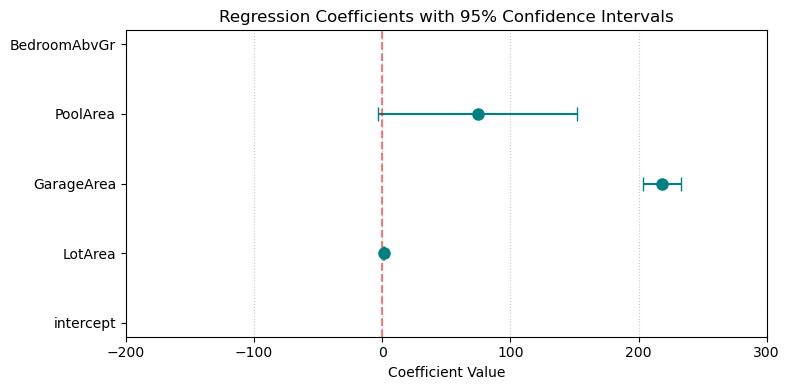

In [11]:
#plot the coefficients with 95%CI as error bar

# Create the plot
plt.figure(figsize=(8, 4))
plt.errorbar(beta_hat_df['Coefficient'], beta_hat_df.index, 
             xerr=[beta_hat_df['Coefficient']- beta_hat_df['Lower 95%'], beta_hat_df['Upper 95%']-beta_hat_df['Coefficient']],
             fmt='o', capsize=5, color='teal', markersize=8, label='95% CI')

# Add a vertical line at zero to check for significance
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Limit the x-axis
plt.xlim(-200, 300)

plt.title('Regression Coefficients with 95% Confidence Intervals')
plt.xlabel('Coefficient Value')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()

In [10]:
# scikit-learn is a Python library for doing machine learning
# It includes an implementation of OLS Regression
from sklearn.linear_model import LinearRegression
ols = LinearRegression(fit_intercept=False).fit(M,y)

#add the sklearn coefficent result to the above beta_hat_df
beta_hat_df['sk_coef'] = ols.coef_

beta_hat_df

,Coefficient,Std Error,t-stat,p-value,Lower 95%,Upper 95%,sk_coef
intercept,34694.343359,6595.774203,5.260087,0.00,21756.100744,47632.585973,34694.343359
LotArea,1.126826,0.161976,6.956729,0.00,0.809094,1.444559,1.126826
GarageArea,218.628469,7.517082,29.084221,0.00,203.882993,233.373944,218.628469
PoolArea,74.534011,39.501920,1.886845,0.06,-2.952788,152.020810,74.534011
BedroomAbvGr,10732.363048,1953.352595,5.494330,0.00,6900.674907,14564.051188,10732.363048


#### Interpreting OLS estimated Coefficients
* In the example above, we didn't standardize the data.
  * some of them are in square feet, some are just yes/no
  * this would leave to varied coefficients
* One option is to center and standardize each variable
  * translate each variable into a Z-score so that the resulting variable is unit-less.
  * `M_centered = (M-np.mean(M,axis=0)) / np.std(M,axis=0)`
  * Note that this approach implicitly assumes that each variable is roughly normally distributed, but this need not be the case.
* Now the coefficients are directly comparable because they have the same units: $\hat{\beta}_i$ has units "standard deviation change in SalesPrice for a standard deviation change in variable $i$."
  * One standard deviation change in GarageArea corresponds to the largest change in SalesPrice.
* Note that fitting a regression with centered and standardized variables **does not require an intercept** because the intercept will be estimated to be 0.
* Another thing to consider is the **Interaction among Variables**, aka, those endless formulas.

In [2]:
#code demo to center and standardize variable M and/or output y

data = pd.read_csv("train.csv")
y = data["SalePrice"]
M = data[["LotArea","GarageArea","PoolArea","BedroomAbvGr"]].copy()
# center each column of M by translating to a z-score
M_centered = (M-np.mean(M,axis=0)) / np.std(M,axis=0)

from sklearn.linear_model import LinearRegression
#we still need to fit an intercept because y is not standardize.
ols = LinearRegression(fit_intercept=True).fit(M_centered,y)

'''
# if we standardize y, then don't need to include intercept, it will be zero
y_centered = (y - y.mean()) / y.std()
ols = LinearRegression(fit_intercept=False).fit(M_centered, y_centered)
# The coefficients will now be between -1 and 1, showing relative strength.
'''

beta_hat_centered = pd.Series(data=ols.coef_, index=M.columns)
beta_hat_centered

LotArea         11243.301068
GarageArea      46727.814165
PoolArea         2993.550121
BedroomAbvGr     8752.227257
dtype: float64

### Feb-13-2026

#### Multicollinearity in OLS Regression
* multicollinearity occurs when one variable can be written as a linear equation using the other variables.
* $M$ with multicollinearity means its Gram Matrix $M^TM$ has multicollinearity
  * multicollinearity definition, there exists some non-zero vector $\vec v$ ($\vec v \neq 0$) such that:$M \vec v = 0$
  * Now, let's check $M^TM$ by that same vector $\vec v$: $\hspace{0.5cm}(M^TM) \vec v = M^T(M \vec v) = M^T(0) = 0$
* OLS regression solves this problem: $\hat \beta \approx (M^TM)^{-1} \cdot M^T \, \vec y$
  * $M$ with multicollinearity leads to no solution for $(M^TM)^{-1}$
* Then with the lecture exmple, how does OLS solves $\hat \beta$ if $M$ has multicollinearity
  * Standard OLS, would fail to solve $(M^TM)^{-1}$
  * Pseudoinverse, uses SVD to bypass zero eigenvalues, would find one of many solutions
  * Ridge Regression, adds $\lambda$ to the diagonal, forces a unique, stable solution
* For the lecture example, `Critical Thinking` is strongly correlated with `Deductive Reasoning` (i.e. Pearson $\rho=0.986$), but not perfectly correlated, this is enough to **bias** the regression coefficient estimates.

quick note, some useful `sympy` functions to solve a linear system
```python
M = sp.Matrix([[...]])
det(M)= M.det()
adj(M) = M.adjugate()

#check
M.det() != 0

Inverse_of_M = M.inv()
```

Lecture Example

Prepare Dataset, the `onetData.csv` is 29MB. We'll process and save the target dataset for easier later use.

```python
def readSkillsWageData():
    data = pd.read_csv("./nationalOews.csv")
    data = data[data["OCC_CODE"].apply(lambda s: s[-1] != '0')]
    data = data[~data["OCC_CODE"].isin(["11-1031"])]
    data = data[["OCC_CODE","OCC_TITLE","year","A_MEAN"]].set_index(["year","OCC_CODE","OCC_TITLE"])
    data = data.join(pd.read_csv("./onetData.csv").set_index(["year","OCC_CODE","ONET VARIABLE"]))
    wages = data[["A_MEAN"]]
    data = data.drop(columns="A_MEAN")\
            .unstack("ONET VARIABLE")["ONET VALUE"]\
            .drop(columns=np.nan)\
            .fillna(0)\
            .join(wages)\
            .rename(columns={"A_MEAN":"Annual Wage"})\
            .droplevel("ONET VARIABLE")
    data = data.groupby(["year","OCC_CODE","OCC_TITLE"]).first()\
        .rename_axis(index={"OCC_CODE":"Occupation","OCC_TITLE":"Title"})
    data = data[["Annual Wage",]+list(data.columns)[:-1]]
    data = data[~np.isnan(data["Annual Wage"])]
    return data

data_skill_wage = readSkillsWageData()
data_skill_wage.to_csv('data_skill_wage.csv')
data_skill_wage_selected = data_skill_wage[["Annual Wage", "Critical Thinking","Deductive Reasoning","Complex Problem Solving","Manual Dexterity"]].copy()
data_skill_wage_selected.to_csv('data_skill_wage_selected.csv')
```

In [15]:
#code demo to show multicollinearity on Critical Thinking of Deductive Reasoning and Complex Problem Solving

#data_skill_wage_selected = pd.read_csv('data_skill_wage_selected.csv')

data_skill_wage_selected[["Critical Thinking","Deductive Reasoning","Complex Problem Solving","Manual Dexterity"]].corr()

,Critical Thinking,Deductive Reasoning,Complex Problem Solving,Manual Dexterity
Critical Thinking,1.000000,0.986445,0.972470,0.141740
Deductive Reasoning,0.986445,1.000000,0.970825,0.153318
Complex Problem Solving,0.972470,0.970825,1.000000,0.127402
Manual Dexterity,0.141740,0.153318,0.127402,1.000000


#### Variance Inflation Factor (VIF) to detect Multicollinearity
* $VIF(\vec{v}_i) = \dfrac{1}{1-\rho_i^2}$
  * Given an OLS regression model containing variables $V = \{\vec{v}_1,\vec{v}_2,\vec{v}_3,\dots,\vec{v}_n\}$
  * Let's take $\vec v_i$ as the output of all other $\vec v_{j \ne i}$: $\hspace{0.5cm} \vec v_i \approx \beta_0 + \sum_{j\neq i} \beta_j\cdot\vec{v}_j$
  * $\rho_i^2$ is the coefficient of determination $R^2$ of this above OLS regression.
* If $\text{VIF} = 1$, there is no correlation. If $\text{VIF} \to \infty$, you have perfect multicollinearity.
* Generally, $\text{VIF}(\vec{v}_i)>5$ indicates problematic multicollinearity.

In [19]:
#code demo to solve VIF

#import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def reduce_vif(df, thresh=5.0):
    """
    Iteratively drops columns with the highest VIF until all are below thresh.
    """
    while True:
        # Add constant for the VIF calculation
        X = add_constant(df)
        
        # Calculate VIFs
        vifs = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        
        # Skip the constant column (usually the first one)
        vif_series = pd.Series(vifs[1:], index=df.columns)
        
        # Get the highest VIF
        max_vif = vif_series.max()
        
        if max_vif > thresh:
            worst_col = vif_series.idxmax()
            print(f"Dropping '{worst_col}' with VIF: {max_vif:.2f}")
            df = df.drop(columns=[worst_col])
        else:
            break
            
    return df

# Example Usage:
# VIF_result = reduce_vif(data_skill_wage_selected[["Critical Thinking","Deductive Reasoning","Complex Problem Solving","Manual Dexterity"]])
# VIF_result

In [23]:
#lecture code demo to calculate VIF
from sklearn.linear_model import LinearRegression
import scipy

def VIF(v,data):
    r = LinearRegression(fit_intercept=True).fit(data,v)
    vhat = r.predict(data)
    rho,_ = scipy.stats.pearsonr(v,vhat)
    return 1/(1-rho**2)

for f in data_skill_wage_selected.columns:
    #check each vector, with the rest
    vif = VIF(data_skill_wage_selected[f],data_skill_wage_selected.drop(columns=f))
    print("VIF(%s) = %0.3f" % (f,vif))

VIF(Annual Wage) = 1.442
,VIF(Critical Thinking) = 44.270
,VIF(Deductive Reasoning) = 41.327
,VIF(Complex Problem Solving) = 22.039
,VIF(Manual Dexterity) = 1.198


#### Measuring Model Performance
* How do we measure an OLS regression's predictive performance?
  * the estimated outcome variable $\hat y$: $\hspace{0.5cm} \hat{y} = M\cdot\hat{\beta}$
  * check the Pearson Correlation between $\hat{y}$ and the actual outcome variable $\vec{y}$: $\hspace{0.5cm}\rho_{\hat{y}\vec{y}} = \dfrac{cov(\hat{y},\vec{y})}{\sigma_{\hat{y}} \, \sigma_{\vec{y}}}$, note $\rho_{\hat{y}\vec{y}}\in[-1,1]$
* Square it to **Coefficient of Determination** $\hspace{0.5cm}R^2=\left(\rho_{\hat{y}\vec{y}}\right)^2 = \frac{\text{Explained Variance}}{\text{Total Variance}}$
  * For a simple model with one predictor $x$ and an intercept (The residuals $\vec{e} = (y - \hat{y})$ are guaranteed to sum to zero), $R^2 = \rho_{xy}^2$.
  * For multiple predictors, $R^2$ represents the combined explained variance of all features in $M$. This goes back to $R^2=\left(\rho_{\hat{y}\vec{y}}\right)^2$
* Adjusted $R^2$, $\hspace{0.5cm} \text{adj }R^2 = 1-\left(1-R^2\right)\frac{n-1}{n-p-1}$
  * For extra variable that is collinear with existing variables, it does not actually increase the information available to the model, but it will still increase $R^2$
  * This motivates **Adjusted $R^2$** that penalizes models with extra variables.
  * $n$ is the number of rows of data and $p$ is the number of variables in the model.
  * Note that adj $R^2$ can actually be negative if $n< p+1$.


Move beyond $R^2$
* Then we can move on with Cross-Validation to detect high $R^2$ but with over-fitting.
* And further on that, we can use Regularization (Ridge, Lasso and Elastic Net) to edit the OLS math to automatically simplify the model (reducing Variables).


lecture code example for R^2 and adj-R^2
```python
from sklearn.linear_model import LinearRegression

# Fit model
model = LinearRegression().fit(X, y)

# Calculate R2 and adjusted R2
r2 = model.score(X, y)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

r2_data[i,:] = [r2,adj_r2]
```

#### Understanding Gradient Descent (iterative optimization approach) and OLS (closed-form solution)
* Let's start with the Linear Regression model: $\hspace{0.5cm}y \approx X\beta$
* OLS solves this linear system and gives an exact solution: $\hspace{0.5cm}\hat \beta = (X^TX)^{-1}X^Ty$
  * But there are issues:
  * The Gram Matrix $X^TX$ might not be invertable, or takes a massive amount of processing power.
* Gradient Descent is an 'iterative' optimization algorithm.
  * Initialize: Start with random values for your slope ($m$) and intercept ($b$).
  * Predict: Calculate the predicted values for your dataset. $\hat y = Xm + b$
  * Calculate the Loss Function with the Mean Squared Error (MSE) formula: $J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (mx_i + b))^2$
  * Compute Gradients: $\nabla J(\theta)$, where $\theta = \begin{bmatrix} \theta_0 \\ \theta_1 \end{bmatrix} = \begin{bmatrix} b \\ m \end{bmatrix}$
    * as the following
    * For $m$: $\frac{\partial J}{\partial m} = \frac{2}{n} \sum -x_i(y_i - \hat{y}_i)$
    * For $b$: $\frac{\partial J}{\partial b} = \frac{2}{n} \sum -(y_i - \hat{y}_i)$
  * If the gradient is positive, the error increases as the parameter increases. You need to decrease the parameter $m, b$. vice versa
  * Update Weights: $\theta_{new} = \theta_{old} - \alpha \cdot \text{Gradient}$, and $\alpha$ is the Learning Rate.
  * Repeat: Keep doing this until the error stops shrinking (convergence).
* Stochastic GD: avoids computing the full gradient over all $n$ observations (rows). Instead, it approximates the gradient using one randomly selected observation (or a small mini-batch) per iteration. This reduces the per-iteration computational cost from $𝑂(np)$ to $O(p)$.

### Feb-15-2026

#### LASSO 'Regression' (Regularization)
* LASSO is a regularized extension of linear regression.
  * different to the OLS closed-form solution. $\hat{\beta}=(M^TM)^{-1}M^T\vec{y}$. There is no closed-form solution for LASSO.
  * It must be solved numerically (e.g., coordinate descent, proximal gradient methods).
* It's actually an added on penalty term  (the $L_1$ norm) to the modified Loss Function $J(\beta) = \displaystyle \frac{1}{2n} \sum_{i=1}^n (y_i - x_i^T\beta)^2 + \alpha \sum_{j=1}^p |\beta _j|$
  * differet to the Mean Squred Error function, $\frac{1}{2n}$ is used to simplify derivatives.
  * where $\alpha$ is the tuning parameter that controls the strength of the penalty.
  * LASSO $L1$ → can produce exact zeros for $\beta_j$
*  Lecture code demo
```python
from sklearn.linear_model import LinearRegression,Lasso
y = data["Annual Wage"]
x = data.drop(columns="Annual Wage")
ols = LinearRegression(fit_intercept=True).fit(x,y)
yhat_ols = ols.predict(x)
lasso = Lasso(
    alpha=1,
    fit_intercept=True,
    max_iter=100_000, # the calculation needs to run extra iterations for our data
).fit(x,y)
yhat_lasso = lasso.predict(x) 

r2_ols = scipy.stats.pearsonr(y,yhat_ols)[0]**2
r2_lasso = scipy.stats.pearsonr(y,yhat_lasso)[0]**2

# manul calculation of adjR2 = 1-(1-r2)*(n-1)/(n-p-1)

beta_ols = ols.coef_
beta_lasso = lasso.coef_
```

#### Logistic Regression (Clasification)
* with the linear model $\hat y = \beta_0+\sum_{i=1}^n \beta_i\cdot x_i$
* we transform the $\hat y$ with a Logistic Function (Sigmoid fuction) to get a probability $P=\dfrac{1}{1+e^{-\hat y}}$, $P \in [0, 1]$
  * It models the log-odds $\hat y = log(\frac{P}{1-P})$as a linear function of predictors
  * The parameters are estimated via maximum likelihood
  * The response is probabilistic, not a direct class label
  * common expression: $\hat y = \dfrac{1}{1 + e^{- \eta}}$, where $\displaystyle \eta = \beta_0 + \sum_{j=1}^p \beta_jx_j$
* next, we setup a threshold, if $P \ge \text{threshold}$, classified as Event $1$, otherwise non-Event $0$
* Loss Function $J(\beta) = \displaystyle -\frac{1}{n} \sum_{i-1}^n[y_i log P_i + (1-y_i)log(1-P_i)]$
  * Unlike linear regression (MSE), logistic regression minimizes: Negative Log-Likelihood
  * There is no closed-form solution. (use Gradient descent, or other approaches)
* Lecture code demo
```python
from sklearn.linear_model import LogisticRegression
n = 1000
x = np.hstack((.4*np.random.rand(n),.4*np.random.rand(n)+.6))
y = np.hstack((np.zeros(n),np.ones(n)))


L = LogisticRegression(fit_intercept=True).fit(x[:,np.newaxis],y)
xx = np.linspace(0,1,20)
yy = L.predict_proba(xx[:,np.newaxis])[:,1]
plt.figure(figsize=(8,6))
plt.plot(x[:10],y[:10],'o',color='b',markersize=10,alpha=1,label="Data")
plt.plot(x[-10:],y[-10:],'o',color='b',markersize=10,alpha=1,label="_Data")
plt.plot(xx,yy,lw=3,color='r',label="Fitted\nLogistic\nCurve")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("$x$",fontsize=15)
plt.ylabel("$y$",fontsize=15)
plt.legend(fontsize=15);
```
* Metrics (pseduo-$R^2$) to assess the predictive performance of a logistic regression model
  *  McFadden's $R^2$ compares the model's predictive performance to the performance of a null model using only an intercept term (i.e., the null model always predicts to overall log odds).
  *  $R^2_{\text{McFadden}} = 1-\dfrac{\ln(\mathcal{L}(\hat{y}|\vec{y}))}{\ln(\mathcal{L}(\hat{y}_{null}|\vec{y}))}$
  *  $R^2_{\text{McFadden}}=0$ implies the model fits no better than the null model, while higher values indicate better performance.
  *  Lecture code demo
```python
# create the null model prediction
p_survive = outcome["Survived"].mean()
# estimate model intercept term using overall log odds of survival
beta_0 = np.log(p_survive/(1-p_survive))
# plug in the linear model to the logistic function to predict yhat
null_yhat = 1/(1+np.exp(-beta_0))

# define the calculation of log-likelihood
logLikelihood = lambda yhat,y: np.sum( y*np.log(yhat) + (1-y)*np.log(1-yhat) ) 

null_log_likelihood = logLikelihood(null_yhat,outcome["Survived"])
full_log_likelihood = logLikelihood(outcome["prediction"],outcome["Survived"])


mcfadden_rsquare = 1.0 - (full_log_likelihood / null_log_likelihood)
print("McFadden's R^2: %0.3f" % mcfadden_rsquare)
```

This should end the notes for data science Math prelimetaries. There's still plenty I wish to cover if only time permitted. 

Also, I'm utterly not sure when to continue Brain Caffo's statistic bootcamp, considering it's behind the Coursera Plut paywall now.

In summary, SymPy is appreciated discovery. And I would re-confirm the need to hold on code rabbit hole digging.

So, move on to Math for Machiine Learning, get exposure of what's happening, and focuse on the understanding. And this understanding part feels more and more like traning my own neurons' weights, and save them as notes for a future easy `.load_weights('/my_notes')`

>Below's a pretty version form all mighty AI

This concludes the notes on the mathematical prerequisites for data science. There’s still so much more I would have liked to cover, if time were on my side.

On a separate note, I honestly don’t know when I’ll continue Brain Caffo’s statistics bootcamp, now that it’s locked behind Coursera’s Plus paywall.

That said, discovering SymPy has been a real highlight. And I’ll reaffirm the importance of resisting the urge to fall too deep into coding rabbit holes.

So now, it’s on to Math for Machine Learning—get a sense of what’s going on, and focus on building understanding. Increasingly, that process of understanding feels like training my own neural weights, saving them as notes for a future, effortless `.load_weights('/my_notes')`.

# Stuff left in the end

#### Explian the Monty Hall with Bayes' Theorem

Yes, the Monty Hall problem is one of the most famous applications of **Bayes' Theorem**. Using Bayesian statistics, we can mathematically prove why switching is the superior strategy.

1, The Bayesian Setup

To solve this, we define our events and update our "belief" based on the new information (the host opening a door). Let's assume you picked **Door 1** and the host opened **Door 3** to reveal a goat.

* **Prior Probability :** The initial chance that the car is behind any specific door.
*  = 
*  = 
*  = 


* **Evidence ():** The host opens Door 3.
* **Likelihood :** The probability that the host would open Door 3 *given* where the car actually is.
* **If the car is behind Door 1:** The host could open Door 2 OR Door 3. So, the chance he opens Door 3 is .
* **If the car is behind Door 2:** The host *must* open Door 3 (he can't open your door or the car door). So, the chance is .
* **If the car is behind Door 3:** The host will never open the door with the car. So, the chance is .



---

2, The Calculation

We use Bayes' Theorem to find the **Posterior Probability** (the updated chance after seeing the evidence):

1. Staying with Door 1

The probability the car is behind Door 1, given the host opened Door 3:


2. Switching to Door 2

The probability the car is behind Door 2, given the host opened Door 3:


3, Conclusion

By applying Bayes' Theorem, we see that the information provided by the host (opening Door 3) does not change the probability for your original choice (), but it "pushes" all the remaining probability () onto the other closed door.

This happens because the host's action is **not random**—he is constrained by what he knows and what you chose.

Would you like me to explain how the odds change if the host *doesn't* know where the car is and opens a door by accident?


#### Understanding a Unit Square in Matrix form
a unit square (square in a 2D plane, not a cube) in the Cartesian plane is defined by four points: 
$S = \begin{bmatrix}0 & 1 & 1 & 0 \\0 & 0 & 1 & 1\end{bmatrix}$

The four columns of this matrix represents:
* Column 1: The origin $ \begin{bmatrix}0 \\ 0\end{bmatrix}$
* Column 2: The point $ \begin{bmatrix}1 \\ 0\end{bmatrix}$, representing the standard basis vector $\vec{i}$.
* Column 3: The opposite corner $ \begin{bmatrix}1 \\ 1\end{bmatrix}$.
* Column 4: The point $ \begin{bmatrix}0 \\ 1\end{bmatrix}$, representing the standard basis vector $\vec{j}$.

We can apply a matrix $M=\begin{bmatrix} a & b \\ c & d \\ \end{bmatrix}$ to S. 
* When M acts on S, the square might become a parallelogram.

$
    M\cdot S = 
        \begin{bmatrix} a & b \\ c & d \\ \end{bmatrix} 
        \cdot 
        \begin{bmatrix}
            0 & 0 & 1 & 1 \\
            0 & 1 & 1 & 0 \\
        \end{bmatrix}
        =
        \begin{bmatrix}
            0 & b & a+b & a \\
            0 & d & c+d & c \\
        \end{bmatrix}
$

There are several choices of $a,\, b,\, c,\, d$ that produce a parallelogram with area zero. Basically, the two adjcent sides overlaps.

With some work, you can show that the area of one of these parallelograms is $ad-bc$.

#### Understanding `*` and `@` multiplication in np.array

In [53]:
p = np.array([[2,  3,],
              [2.2,3,]])

M = np.array([[2,3,],
              [3,5]])

c = np.sum(M*p,axis=1)

c1=M*p
print(c1)

c2 = M@p
print(c2)

[[ 4.   9. ]
,, [ 6.6 15. ]]
,,[[10.6 15. ]
,, [17.  24. ]]


#### Using the Binomial Theorem to deduct the Power Rule
To derive the power rule—which states that $\frac{d}{dx} (x^{n}) = n \cdot x^{n-1}$, where $n$ is a positive integer.

1, Set up the  long-form limit definition
* The derivative $f^{\prime }(x)$ of a function $f(x)=x^{n}$ is defined as the limit of the difference quotient as the change in $x$ (denoted as $h$) approaches zero:
$$f^{\prime }(x)=\lim _{h\rightarrow 0}\frac{f(x+h)-f(x)}{h}=\lim _{h\rightarrow 0}\frac{(x+h)^{n}-x^{n}}{h}$$


2, Apply the Binomial Theorem to expand the term $(x+h)^{n}$. 
* The theorem states that
$$(x+h)^{n}=\sum _{k=0}^{n}{n \choose k}x^{n-k}h^{k}$$
* Expanded, the first few terms are:
$$\begin{aligned}
(x+h)^{n} &= \sum_{i=0}^n {n \choose i}x^{n-i}h^i \\
          &= {n \choose 0}x^{n}h^{0}+{n \choose 1}x^{n-1}h^{1}+{n \choose 2}x^{n-2}h^{2}+\cdots +{n \choose n-1}x^{1}h^{n-1}+{n \choose n}x^{0}h^{n}\\
          &= x^{n}+nx^{n-1}h+\frac{n(n-1)}{2}x^{n-2}h^{2}+\dots +h^{n}
\end{aligned}$$
* Note: The first term coefficient is ${n \choose 0}=1$ and the second is ${n \choose 1}=n$, and the third is ${n \choose 2} = \frac{n!}{(n-2)! \cdot 2!} = \frac{n(n-1)}{2}$.


3, Simplify the Difference Quotient. 
* Substitute this expansion back into the limit equation:
$$f^{\prime }(x)=\lim _{h\rightarrow 0}\frac{x^{n}+nx^{n-1}h+ \frac{n(n-1)}{2}x^{n-2}h^{2}+\dots +h^{n} -x^{n}}{h}$$
* The $x^{n}$ terms cancel each other out. This leaves only terms that contain at least one factor of $h$
$$f^{\prime }(x)=\lim _{h\rightarrow 0}\frac{nx^{n-1}h+\frac{n(n-1)}{2}x^{n-2}h^{2}+\dots +h^{n}}{h}$$


4, Divide by $h$ and Take the Limit 
* Divide every term in the numerator by $h$:
$$f^{\prime }(x)=\lim _{h\rightarrow 0}\left(nx^{n-1}+\frac{n(n-1)}{2}x^{n-2}h+\dots +h^{n-1}\right)$$
* Take the Limit, as $h$ approaches 0, every term containing $h$ becomes zero.
* Only the first term, which does not have an $h$, remains:$$f^{\prime }(x)=nx^{n-1}$$.

5, put them together: 
$$\begin{align}
\frac{df(t)}{dt}
&=\lim_{h\rightarrow0}\frac{f(t+h)-f(t)}{h}
=\lim_{h\rightarrow0}\frac{\color{blue}{(t+h)^n}-t^n}{h}
=\lim_{h\rightarrow0}\frac{\color{blue}{\overbrace{(t+h)(t+h)\cdots(t+h)}^{n\text{ times}}}-t^n}{h} 
\\ \\ 
&=\lim_{h\rightarrow0}\frac{\left(\color{blue}{\displaystyle\sum_{i=0}^n {n \choose i} t^{n-i}h^{i}}\right)-t^n}{h}\hspace{2cm}\text{using the Binomial Theorem} 
\\ \\
&=\lim_{h\rightarrow0}\frac{\color{red}{t^n}+\color{orange}{h}\displaystyle\sum_{\color{red}{i=1}}^n {n \choose i}\cdot t^{n-i}\color{orange}{h^{i-1}}-t^n}{h}
=\lim_{h\rightarrow0}\displaystyle\sum_{i=1}^n {n \choose i}\cdot t^{n-i}\color{orange}{h^{i-1}}
= \lim_{h\rightarrow0}{n \choose 1}\cdot t^{n-1}\color{orange}{h^{1-1}}
\\ \\
&= n\cdot t^{n-1}
\end{align}$$

Know the two Binomial cases
* Binomial Theorem
* Binomial Distribution

#### the Binomial Theorem
which states:

$$\begin{align}
\displaystyle (x+y)^{n}
&= \sum_{i=0}^n \color{red}{{n \choose i}}x^{n-i}y^i \\
&={n \choose 0}x^{n}y^{0}+{n \choose 1}x^{n-1}y^{1}+{n \choose 2}x^{n-2}y^{2}+\cdots +{n \choose n-1}x^{1}y^{n-1}+{n \choose n}x^{0}y^{n}
\end{align}$$

where 
$$\begin{align}\displaystyle\color{red}{{n \choose i}}
&=\frac{n!}{(n-i)!\cdot i!}\\
&=\frac{n\cdot(n-1)\cdot(n-2)\cdots2\cdot1}{\left((n-i)\cdot(n-i-1)\cdots2\cdot1\right)\left(i\cdot(i-1)\cdot(i-2)\cdots2\cdot1\right)}
\end{align}$$
is called "$n$ choose $i$." 

> "$n$ choose $i$" represents the number of way to choose a set of $i$ unique things from a total collection of $n$ unique things.



For example, how many 5 card hands are possible from a standard 52 playing card deck?

$
\hspace{.5cm}
\displaystyle
{n \choose i} 
= {52 \choose 5} 
= \frac{52!}{(52-5)!\cdot 5!}
=\frac{52\cdot51\cdot50\cdots2\cdot1}{\left(47\cdot46\cdots2\cdot1\right)\left(5\cdot4\cdot3\cdot2\cdot1\right)}
=2,598,960
$

For our purposes, <font color="blue">$\displaystyle{n \choose i}$ is always a constant integer</font>, <font color="magenta">$\displaystyle{n \choose 0}=1$</font>, and <font color="green">$\displaystyle{n \choose 1}=n$</font>.

In [2]:
import math
math.comb(52,5)

2598960

#### The Binomial Distribution (Probability)
> In statistics, a binomial situation occurs when an experiment has exactly two outcomes: success or failure (like a coin flip). 
For a random variable $X$ following a binomial distribution, the probability is: $$P(X=k)={n \choose k}\cdot p^{k}\cdot (1-p)^{n-k}$$


Key Components:
* $n$ (Number of Trials): The fixed total number of independent experiments.
* $k$ (Number of Successes): The specific number of successes you want to calculate the probability for ($k=0,1,2,\dots ,n$).
* $p$ (Probability of Success): The constant probability of "success" on any single individual trial.
* $1-p$ (Probability of Failure): is the probability of "failure" on a single trial.
* ${n \choose k}$ (Binomial Coefficient): Pronounced "n choose k," this represents the number of different ways to arrange $k$ successes in $n$ trials. It is calculated as:${n \choose k}=\frac{n!}{k!(n-k)!}$


A rational function is a function defined as the ratio of two polynomials.
| Type | Example | Reason |
|---|---|---|
| Rational | $f(x)=\frac{x^{2}+5}{3x-2}$ | Both numerator and denominator are polynomials. |
| Rational | $f(x)=\frac{1}{x}$ | A constant ($1$) is a polynomial of degree zero, and $x$ is a polynomial. |
| Not Rational | $f(x)=\frac{\sqrt{x}+4}{x^{2}}$ | $\sqrt{x}=x^{1/2}$ is not a polynomial because the exponent is not an integer. |
| Not Rational | $f(x)=\frac{2^{x}}{x+1}$ | $2^{x}$ is an exponential function, not a polynomial. |

In particular, let's solve the derivative for any polynomial of the common form 
$\hspace{.5cm} \displaystyle f(t)=\sum_{n=0}^n a_n\cdot t^n \hspace{.5cm}$

#### Deduction of Geometric Distribution's Variacne
  * the deduction, start with the definition: $Var(X) = E[X^2] - E[X]^2 = E[X^2] - (1/p)^2$
  * note that $E[X^2] = E[X^2 - X] + E[X] = E[X^2 -X] + 1/p$
  * now go back to the definiton of $E[X^2-X] = \displaystyle \sum_{n=1}^{\infty} n(n-1) \times (1-p)^{n-1}p$
  * note that $\displaystyle \sum_{n=1}^{\infty} n(n-1) \times (1-p)^{n-1}p = \sum_{n=2}^{\infty} n(n-1) \times (1-p)^{n-1}p + \color{red} 1 \times (1-1) \times (1-p)^{1-1}p \hspace{1cm} \text{the red part is 0, with n=1}$
  * so, we got $E[X^2-X] = \displaystyle \sum_{n=2}^{\infty} n(n-1) \times (1-p)^{n-1}p$
  * now, play on this part $(1-p)^{n-1}p = (1-p)^{n-2} \cdot (1-p) \cdot p$
  * plut it back, and so, we got $E[X^2-X] = (1-p)p \cdot \displaystyle \sum_{n=2}^{\infty} n(n-1) \times (1-p)^{n-2}$
  * now, we play with $x = 1-p$ and $a = (1-p)p$, to transform $E[X^2-X] = a \cdot \displaystyle \sum_{n=2}^{\infty} n(n-1) \times x^{n-2}$
  * and $\displaystyle \sum_{n=2}^{\infty} n(n-1) \times x^{n-2} = \displaystyle \sum_{n=0}^{\infty} n(n-1) \times x^{n-2} - case(0) - case(1)$
  * $case(0)=0$, $case(1)=0$
  * so, $\displaystyle \sum_{n=2}^{\infty} n(n-1) \times x^{n-2} = \displaystyle \sum_{n=0}^{\infty} n(n-1) \times x^{n-2}$
  * now, play the second derivative trick on $\sum x^n$: $\hspace{1cm} \displaystyle \frac{d^2}{dx^2} \sum_{n=0}^\infty x^n = \sum_{n=0}^\infty n(n-1)x^{n-2} = \sum_{n=2}^{\infty} n(n-1) \times x^{n-2}$
  * apply $\displaystyle \sum_{i=0}^\infty a\cdot x^i = \frac{a}{1-x},  \text{    when   } |x|<1, \Rightarrow \hspace{1cm} \frac{d^2}{dx^2} \sum_{n=0}^\infty x^n = \frac{d^2(\frac{1}{1-x})}{dx^2} = \color{red} \frac{2}{(1-x)^3}$
  * Setting $x = (1-p)$, we apply the chain rule.
  * Since $\frac{d}{dp}(1-p) = -1$, the second derivative with respect to $p$ involves two sign flips, which cancel out:$$\sum_{n=2}^\infty n(n-1)(1-p)^{n-2} = \frac{2}{p^3}$$
  * Plugging this back into our $E[X(X-1)]$ equation:$$E[X(X-1)] = p(1-p) \cdot \frac{2}{p^3} = \frac{2(1-p)}{p^2}$$
  * Final AssemblyNow we plug everything into the variance formula:$$Var(X) = \frac{2(1-p)}{p^2} + \frac{1}{p} - \left(\frac{1}{p}\right)^2$$$$Var(X) = \frac{2 - 2p}{p^2} + \frac{p}{p^2} - \frac{1}{p^2}$$$$Var(X) = \frac{2 - 2p + p - 1}{p^2} = \frac{1-p}{p^2}$$



# Left in the end, some codes to check out

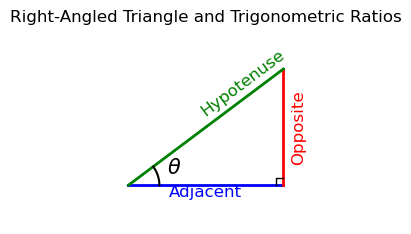

In [49]:
#import matplotlib.pyplot as plt
#import numpy as np

# Define triangle vertices
A = np.array([0, 0])      # Origin
B = np.array([4, 0])      # Base point
C = np.array([4, 3])      # Top point

plt.figure(figsize=(3, 3))
# Plot the triangle sides
plt.plot([A[0], B[0]], [A[1], B[1]], 'b-', linewidth=2)  # Adjacent
plt.plot([B[0], C[0]], [B[1], C[1]], 'r-', linewidth=2)  # Opposite
plt.plot([A[0], C[0]], [A[1], C[1]], 'g-', linewidth=2)  # Hypotenuse

# Draw right angle symbol
plt.plot([3.8, 3.8, 4.0], [0, 0.2, 0.2], 'k-', linewidth=1)

# Label the angle theta
theta_arc = np.linspace(0, np.arctan(3/4), 100)
plt.plot(0.8 * np.cos(theta_arc), 0.8 * np.sin(theta_arc), 'k-')
plt.text(1.0, 0.3, r'$\theta$', fontsize=15)

# Add labels for sides
plt.text(2, -0.3, 'Adjacent', ha='center', color='blue', fontsize=12)
plt.text(4.2, 1.5, 'Opposite', va='center', rotation=90, color='red', fontsize=12)
plt.text(1.8, 1.8, 'Hypotenuse', rotation=36.8, color='green', fontsize=12)

# Set limits and aspect
plt.xlim(-1, 5)
plt.ylim(-1, 4)
plt.gca().set_aspect('equal', adjustable='box')
plt.axis('off')

# Title
plt.title('Right-Angled Triangle and Trigonometric Ratios')
plt.show()
# Save the plot
#plt.savefig('triangle_ratios.png')

In [4]:
from pprint import pprint

data = {
    "users": [
        {"id": 1, "name": "Alice", "roles": ["admin", "editor"], "active": True},
        {"id": 2, "name": "Bob", "roles": ["viewer"], "active": False}
    ],
    "metadata": {"version": "2.0.1", "status": "stable"}
}

# Standard print: often hard to read
print(data)

# pprint: formatted with indentation and line breaks
pprint(data)


{'users': [{'id': 1, 'name': 'Alice', 'roles': ['admin', 'editor'], 'active': True}, {'id': 2, 'name': 'Bob', 'roles': ['viewer'], 'active': False}], 'metadata': {'version': '2.0.1', 'status': 'stable'}}
,,{'metadata': {'status': 'stable', 'version': '2.0.1'},
,, 'users': [{'active': True,
,,            'id': 1,
,,            'name': 'Alice',
,,            'roles': ['admin', 'editor']},
,,           {'active': False, 'id': 2, 'name': 'Bob', 'roles': ['viewer']}]}
